In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hospital_opd.csv")

In [3]:
df.head()

,record_no,patient_id,appointment_id,appointment_start_datetime,prescription_doctor_id,prescription_doctor_name,prescription_order_id,prescription_start_datetime,prescription_end_datetime,lab_id,...,pharmacy_end_datetime,flow_code,flow_name,prescription_processing_minutes,lab_processing_minutes,imaging_processing_minutes,pharmacy_processing_minutes,appointment_to_prescription_minutes,appointment_hour,appointment_month
0,1,10,445911,2026-03-30 05:36:00,225,Admin,106357,2026-03-30 05:38:00,2026-03-30 06:48:00,NaN,...,NaN,1,Appointment â†’ Prescription,70,NaN,NaN,NaN,72,5,2026-03
1,2,57,335085,2025-10-14 05:23:00,193,Dr. Abrar Ahmed Bhatti,43515,2025-10-14 05:39:00,2025-10-14 05:53:00,NaN,...,NaN,1,Appointment â†’ Prescription,14,NaN,NaN,NaN,30,5,2025-10
2,3,57,335085,2025-10-14 05:23:00,193,Dr. Abrar Ahmed Bhatti,43541,2025-10-14 06:11:00,2025-10-14 06:24:00,NaN,...,NaN,1,Appointment â†’ Prescription,13,NaN,NaN,NaN,61,5,2025-10
3,4,60,322358,2025-09-25 13:36:00,195,Dr. Anique Ahmed,34654,2025-09-25 13:50:00,2025-09-25 13:51:00,NaN,...,NaN,1,Appointment â†’ Prescription,1,NaN,NaN,NaN,15,13,2025-09
4,5,72,337714,2025-10-17 06:40:00,202,Dr. Mehreen Batool Bokhari,45263,2025-10-17 06:49:00,2025-10-17 06:49:00,NaN,...,NaN,1,Appointment â†’ Prescription,0,NaN,NaN,NaN,9,6,2025-10


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 61895
Number of columns: 31


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61895 entries, 0 to 61894
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   record_no                            61895 non-null  int64  
 1   patient_id                           61895 non-null  int64  
 2   appointment_id                       61895 non-null  int64  
 3   appointment_start_datetime           61895 non-null  object 
 4   prescription_doctor_id               61895 non-null  int64  
 5   prescription_doctor_name             61895 non-null  object 
 6   prescription_order_id                61895 non-null  int64  
 7   prescription_start_datetime          61895 non-null  object 
 8   prescription_end_datetime            61895 non-null  object 
 9   lab_id                               17920 non-null  float64
 10  lab_name                             17920 non-null  object 
 11  lab_start_datetime          

In [6]:
df.columns.tolist()

['record_no',
 'patient_id',
 'appointment_id',
 'appointment_start_datetime',
 'prescription_doctor_id',
 'prescription_doctor_name',
 'prescription_order_id',
 'prescription_start_datetime',
 'prescription_end_datetime',
 'lab_id',
 'lab_name',
 'lab_start_datetime',
 'lab_end_datetime',
 'imaging_request_id',
 'imaging_result_id',
 'imaging_name',
 'imaging_start_datetime',
 'imaging_end_datetime',
 'pharmacy_sale_line_id',
 'medicine_name',
 'pharmacy_start_datetime',
 'pharmacy_end_datetime',
 'flow_code',
 'flow_name',
 'prescription_processing_minutes',
 'lab_processing_minutes',
 'imaging_processing_minutes',
 'pharmacy_processing_minutes',
 'appointment_to_prescription_minutes',
 'appointment_hour',
 'appointment_month']

In [7]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

pharmacy_sale_line_id          61593
medicine_name                  61593
pharmacy_start_datetime        61593
pharmacy_end_datetime          61593
pharmacy_processing_minutes    61593
imaging_processing_minutes     56434
imaging_end_datetime           56408
imaging_request_id             56398
imaging_result_id              56398
imaging_name                   56398
imaging_start_datetime         56398
lab_processing_minutes         49354
lab_end_datetime               48629
lab_id                         43975
lab_name                       43975
lab_start_datetime             43975
dtype: int64

In [8]:
(df.isnull().sum() / len(df) * 100).round(2)

record_no                               0.00
patient_id                              0.00
appointment_id                          0.00
appointment_start_datetime              0.00
prescription_doctor_id                  0.00
prescription_doctor_name                0.00
prescription_order_id                   0.00
prescription_start_datetime             0.00
prescription_end_datetime               0.00
lab_id                                 71.05
lab_name                               71.05
lab_start_datetime                     71.05
lab_end_datetime                       78.57
imaging_request_id                     91.12
imaging_result_id                      91.12
imaging_name                           91.12
imaging_start_datetime                 91.12
imaging_end_datetime                   91.13
pharmacy_sale_line_id                  99.51
medicine_name                          99.51
pharmacy_start_datetime                99.51
pharmacy_end_datetime                  99.51
flow_code 

In [9]:
print("Total records:", len(df))
print("Duplicate records:", df.duplicated().sum())

Total records: 61895
Duplicate records: 0


In [10]:
df[df.duplicated(keep=False)].head(20)

,record_no,patient_id,appointment_id,appointment_start_datetime,prescription_doctor_id,prescription_doctor_name,prescription_order_id,prescription_start_datetime,prescription_end_datetime,lab_id,...,pharmacy_end_datetime,flow_code,flow_name,prescription_processing_minutes,lab_processing_minutes,imaging_processing_minutes,pharmacy_processing_minutes,appointment_to_prescription_minutes,appointment_hour,appointment_month


In [11]:
date_columns = [
    'appointment_start_datetime',
    'prescription_start_datetime',
    'prescription_end_datetime',
    'lab_start_datetime',
    'lab_end_datetime',
    'imaging_start_datetime',
    'imaging_end_datetime',
    'pharmacy_start_datetime',
    'pharmacy_end_datetime'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_columns].dtypes

appointment_start_datetime     datetime64[ns]
prescription_start_datetime    datetime64[ns]
prescription_end_datetime      datetime64[ns]
lab_start_datetime             datetime64[ns]
lab_end_datetime               datetime64[ns]
imaging_start_datetime         datetime64[ns]
imaging_end_datetime           datetime64[ns]
pharmacy_start_datetime        datetime64[ns]
pharmacy_end_datetime          datetime64[ns]
dtype: object

In [12]:
df[date_columns].isnull().sum()

appointment_start_datetime         0
prescription_start_datetime        0
prescription_end_datetime          0
lab_start_datetime             43975
lab_end_datetime               48629
imaging_start_datetime         56398
imaging_end_datetime           56408
pharmacy_start_datetime        61593
pharmacy_end_datetime          61593
dtype: int64

In [13]:
time_columns = [
    'prescription_processing_minutes',
    'lab_processing_minutes',
    'imaging_processing_minutes',
    'pharmacy_processing_minutes',
    'appointment_to_prescription_minutes'
]

for col in time_columns:
    print(f"\n{col}")
    print("Negative:", (df[col] < 0).sum())
    print("Zero:", (df[col] == 0).sum())
    print("Missing:", df[col].isna().sum())


prescription_processing_minutes
Negative: 0
Zero: 41172
Missing: 0

lab_processing_minutes
Negative: 0
Zero: 1
Missing: 49354

imaging_processing_minutes
Negative: 0
Zero: 559
Missing: 56434

pharmacy_processing_minutes
Negative: 0
Zero: 143
Missing: 61593

appointment_to_prescription_minutes
Negative: 0
Zero: 0
Missing: 0


In [14]:
df[time_columns].describe().round(2)

,prescription_processing_minutes,lab_processing_minutes,imaging_processing_minutes,pharmacy_processing_minutes,appointment_to_prescription_minutes
count,61895.00,12541.00,5461.00,302.00,61895.00
mean,3.11,167.27,11.12,5.36,52.46
std,24.40,179.15,87.56,57.39,88.87
min,0.00,0.00,0.00,0.00,1.00
25%,0.00,74.00,1.00,0.00,14.00
50%,0.00,119.00,3.00,1.00,31.00
75%,2.00,190.00,5.00,1.00,61.00
max,1420.00,1439.00,1421.00,707.00,1438.00


In [15]:
df[['appointment_hour']].describe().round(2)

,appointment_hour
count,61895.00
mean,9.62
std,3.90
min,0.00
25%,6.00
50%,10.00
75%,13.00
max,23.00


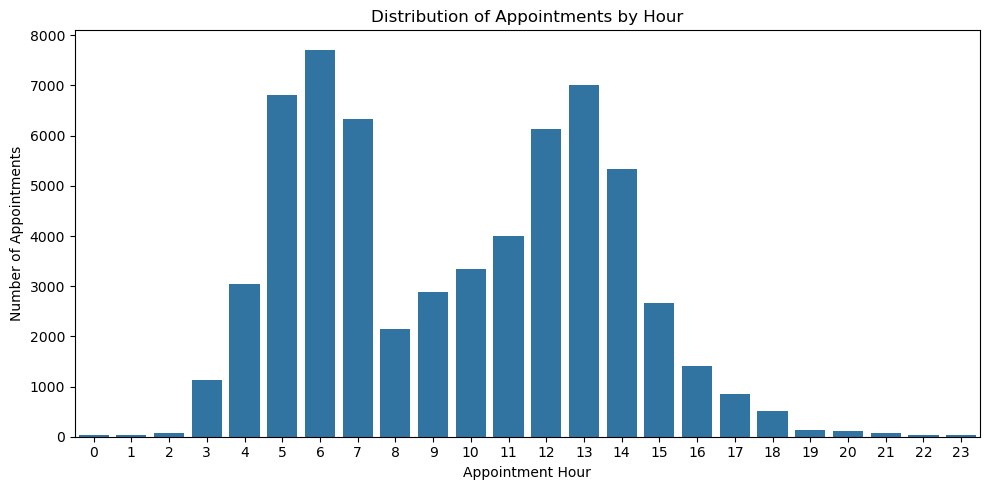

In [16]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='appointment_hour'
)

plt.title('Distribution of Appointments by Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Number of Appointments')
plt.tight_layout()
plt.show()

In [17]:
monthly_appointments = (
    df.groupby('appointment_month')
      .size()
      .reset_index(name='appointments')
)

monthly_appointments

,appointment_month,appointments
0,2024-04,2
1,2024-05,2
2,2024-06,2
3,2024-07,2
4,2024-08,1
5,2024-12,2
6,2025-02,3
7,2025-03,31
8,2025-04,125
9,2025-05,524


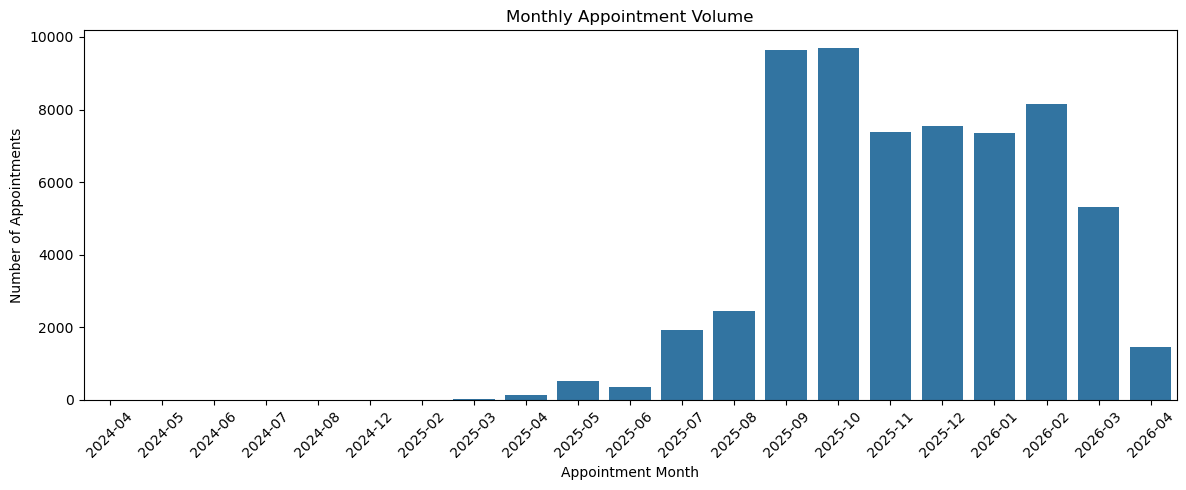

In [18]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_appointments,
    x='appointment_month',
    y='appointments'
)

plt.title('Monthly Appointment Volume')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
department_workload = pd.DataFrame({
    'Department': ['Prescription', 'Lab', 'Imaging', 'Pharmacy'],
    'Records': [
        (df['prescription_processing_minutes'] > 0).sum(),
        (df['lab_processing_minutes'] > 0).sum(),
        (df['imaging_processing_minutes'] > 0).sum(),
        (df['pharmacy_processing_minutes'] > 0).sum()
    ]
})

department_workload

,Department,Records
0,Prescription,20723
1,Lab,12540
2,Imaging,4902
3,Pharmacy,159


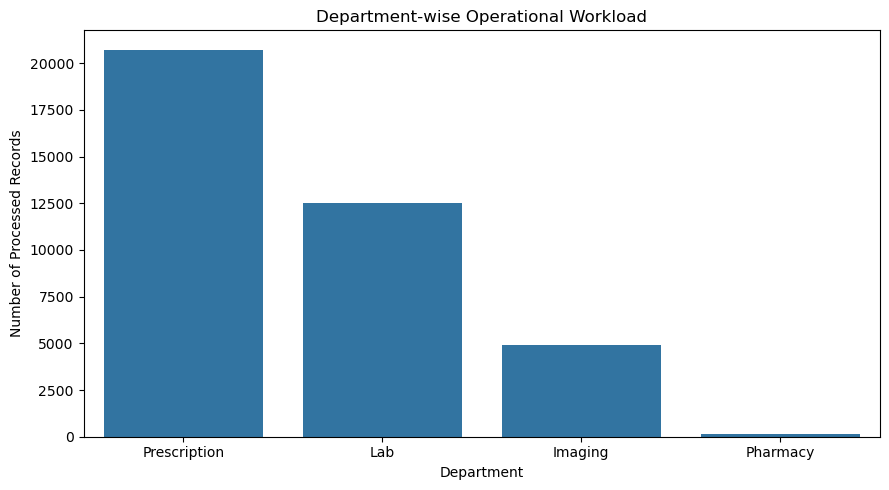

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=department_workload,
    x='Department',
    y='Records'
)

plt.title('Department-wise Operational Workload')
plt.xlabel('Department')
plt.ylabel('Number of Processed Records')
plt.tight_layout()
plt.show()

In [21]:
avg_processing = pd.DataFrame({
    'Department': ['Prescription', 'Lab', 'Imaging', 'Pharmacy'],
    'Average Processing Time (min)': [
        df.loc[df['prescription_processing_minutes'] > 0,
               'prescription_processing_minutes'].mean(),
        df.loc[df['lab_processing_minutes'] > 0,
               'lab_processing_minutes'].mean(),
        df.loc[df['imaging_processing_minutes'] > 0,
               'imaging_processing_minutes'].mean(),
        df.loc[df['pharmacy_processing_minutes'] > 0,
               'pharmacy_processing_minutes'].mean()
    ]
})

avg_processing['Average Processing Time (min)'] = \
    avg_processing['Average Processing Time (min)'].round(2)

avg_processing

,Department,Average Processing Time (min)
0,Prescription,9.28
1,Lab,167.28
2,Imaging,12.39
3,Pharmacy,10.19


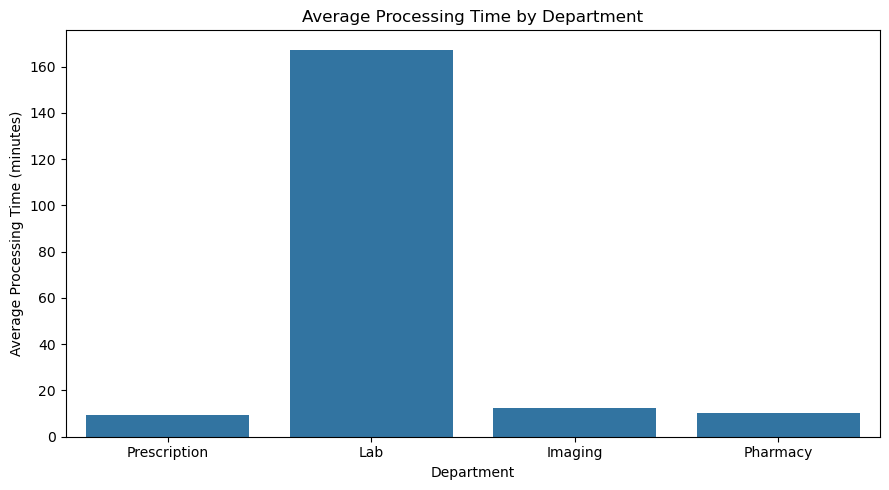

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=avg_processing,
    x='Department',
    y='Average Processing Time (min)'
)

plt.title('Average Processing Time by Department')
plt.xlabel('Department')
plt.ylabel('Average Processing Time (minutes)')
plt.tight_layout()
plt.show()

In [23]:
monthly_appointments = (
    df.groupby('appointment_month')
      .size()
      .reset_index(name='appointments')
)

monthly_appointments

,appointment_month,appointments
0,2024-04,2
1,2024-05,2
2,2024-06,2
3,2024-07,2
4,2024-08,1
5,2024-12,2
6,2025-02,3
7,2025-03,31
8,2025-04,125
9,2025-05,524


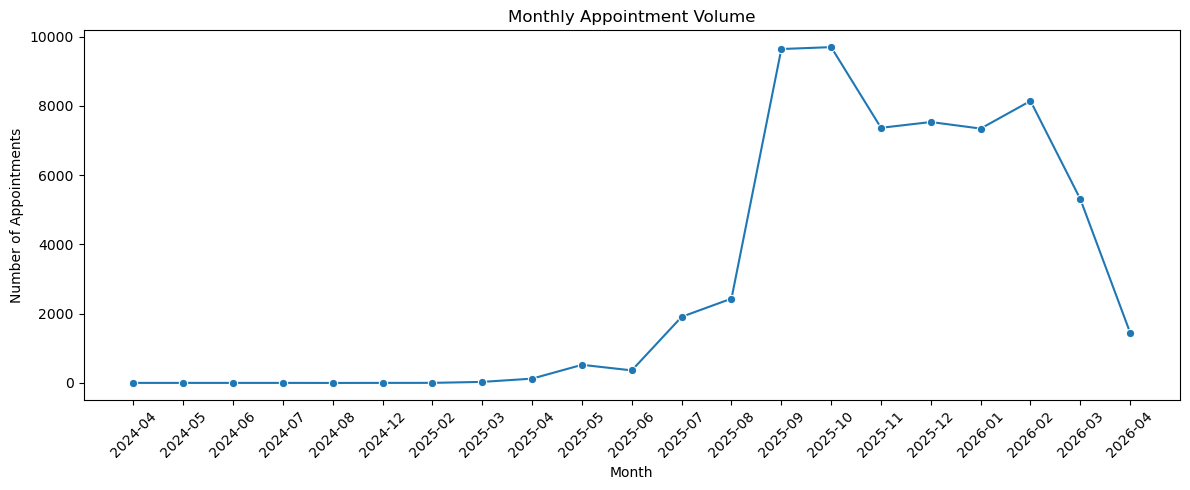

In [24]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_appointments,
    x='appointment_month',
    y='appointments',
    marker='o'
)

plt.title('Monthly Appointment Volume')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
department_summary = pd.DataFrame({
    'Department': ['Prescription', 'Lab', 'Imaging', 'Pharmacy'],
    'Records': [
        (df['prescription_processing_minutes'] > 0).sum(),
        (df['lab_processing_minutes'] > 0).sum(),
        (df['imaging_processing_minutes'] > 0).sum(),
        (df['pharmacy_processing_minutes'] > 0).sum()
    ],
    'Avg_Processing_Minutes': [
        df.loc[df['prescription_processing_minutes'] > 0, 'prescription_processing_minutes'].mean(),
        df.loc[df['lab_processing_minutes'] > 0, 'lab_processing_minutes'].mean(),
        df.loc[df['imaging_processing_minutes'] > 0, 'imaging_processing_minutes'].mean(),
        df.loc[df['pharmacy_processing_minutes'] > 0, 'pharmacy_processing_minutes'].mean()
    ]
})

department_summary['Avg_Processing_Minutes'] = \
    department_summary['Avg_Processing_Minutes'].round(2)

department_summary

,Department,Records,Avg_Processing_Minutes
0,Prescription,20723,9.28
1,Lab,12540,167.28
2,Imaging,4902,12.39
3,Pharmacy,159,10.19


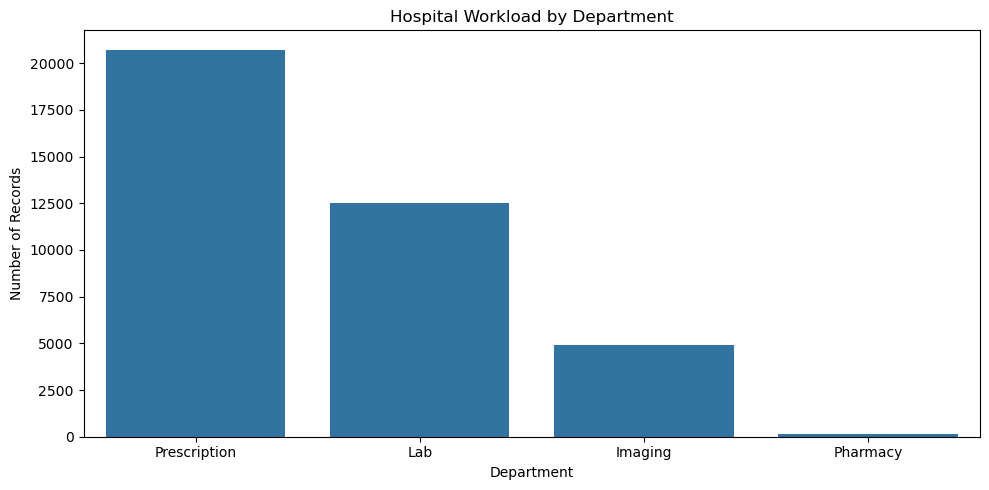

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=department_summary,
    x='Department',
    y='Records'
)

plt.title('Hospital Workload by Department')
plt.xlabel('Department')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

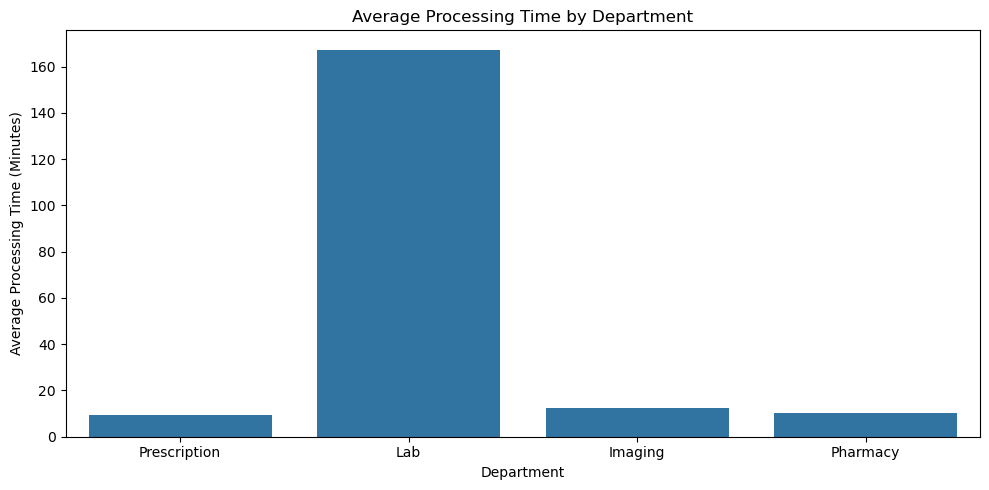

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=department_summary,
    x='Department',
    y='Avg_Processing_Minutes'
)

plt.title('Average Processing Time by Department')
plt.xlabel('Department')
plt.ylabel('Average Processing Time (Minutes)')
plt.tight_layout()
plt.show()

In [28]:
lab_data = df[
    df['lab_processing_minutes'].notna() &
    (df['lab_processing_minutes'] > 0)
]['lab_processing_minutes']

lab_data.describe().round(2)

count    12540.00
mean       167.28
std        179.15
min          1.00
25%         74.00
50%        119.00
75%        190.00
max       1439.00
Name: lab_processing_minutes, dtype: float64

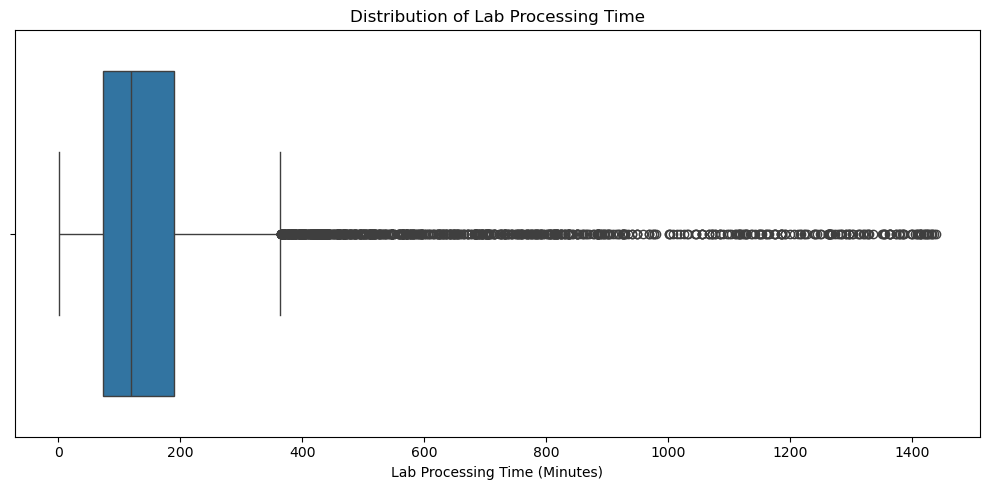

In [29]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=lab_data)

plt.title('Distribution of Lab Processing Time')
plt.xlabel('Lab Processing Time (Minutes)')
plt.tight_layout()
plt.show()

In [30]:
Q1 = lab_data.quantile(0.25)
Q3 = lab_data.quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lab_outliers = lab_data[
    (lab_data < lower_limit) |
    (lab_data > upper_limit)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Limit:", round(lower_limit, 2))
print("Upper Limit:", round(upper_limit, 2))
print("Number of Lab Outliers:", len(lab_outliers))
print("Outlier Percentage:", round(len(lab_outliers) / len(lab_data) * 100, 2), "%")

Q1: 74.0
Q3: 190.0
IQR: 116.0
Lower Limit: -100.0
Upper Limit: 364.0
Number of Lab Outliers: 871
Outlier Percentage: 6.95 %


In [31]:
top_lab_delays = df[
    df['lab_processing_minutes'].notna()
].sort_values(
    'lab_processing_minutes',
    ascending=False
)[[
    'record_no',
    'patient_id',
    'appointment_id',
    'appointment_start_datetime',
    'lab_processing_minutes'
]].head(10)

top_lab_delays

,record_no,patient_id,appointment_id,appointment_start_datetime,lab_processing_minutes
53346,53825,287450,403053,2026-01-21 10:26:00,1439.0
1258,1267,8238,442806,2026-03-25 07:10:00,1435.0
41238,41593,259248,337199,2025-10-16 11:43:00,1433.0
53437,53917,287684,400527,2026-01-17 10:03:00,1432.0
39514,39863,256081,330448,2025-10-07 06:43:00,1430.0
3111,3137,19620,418797,2026-02-13 06:59:00,1428.0
41017,41370,258796,336021,2025-10-15 07:18:00,1425.0
39517,39866,256082,330450,2025-10-07 06:44:00,1424.0
28395,28642,229325,275541,2025-07-22 10:01:00,1423.0
53906,54394,288681,402884,2026-01-21 06:47:00,1422.0


In [32]:
lab_hourly = (
    df[df['lab_processing_minutes'] > 0]
    .groupby('appointment_hour')
    .agg(
        lab_records=('lab_processing_minutes', 'count'),
        avg_lab_minutes=('lab_processing_minutes', 'mean')
    )
    .reset_index()
)

lab_hourly['avg_lab_minutes'] = lab_hourly['avg_lab_minutes'].round(2)

lab_hourly

,appointment_hour,lab_records,avg_lab_minutes
0,0,3,47.67
1,1,6,151.83
2,2,9,128.33
3,3,239,128.04
4,4,670,140.74
5,5,1544,164.58
6,6,1590,162.29
7,7,1158,177.16
8,8,431,190.07
9,9,809,178.31


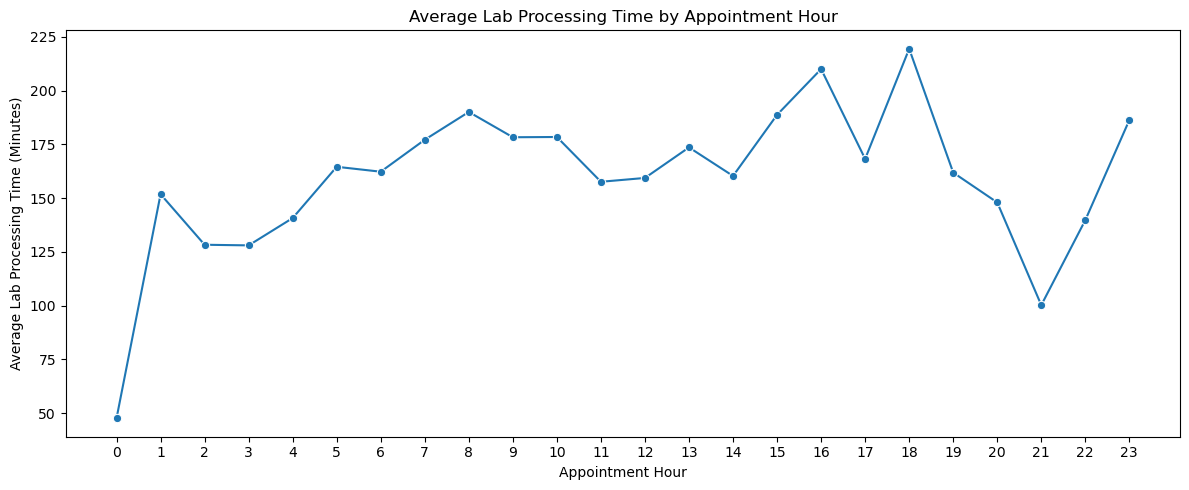

In [33]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=lab_hourly,
    x='appointment_hour',
    y='avg_lab_minutes',
    marker='o'
)

plt.title('Average Lab Processing Time by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Average Lab Processing Time (Minutes)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [34]:
lab_hourly

,appointment_hour,lab_records,avg_lab_minutes
0,0,3,47.67
1,1,6,151.83
2,2,9,128.33
3,3,239,128.04
4,4,670,140.74
5,5,1544,164.58
6,6,1590,162.29
7,7,1158,177.16
8,8,431,190.07
9,9,809,178.31


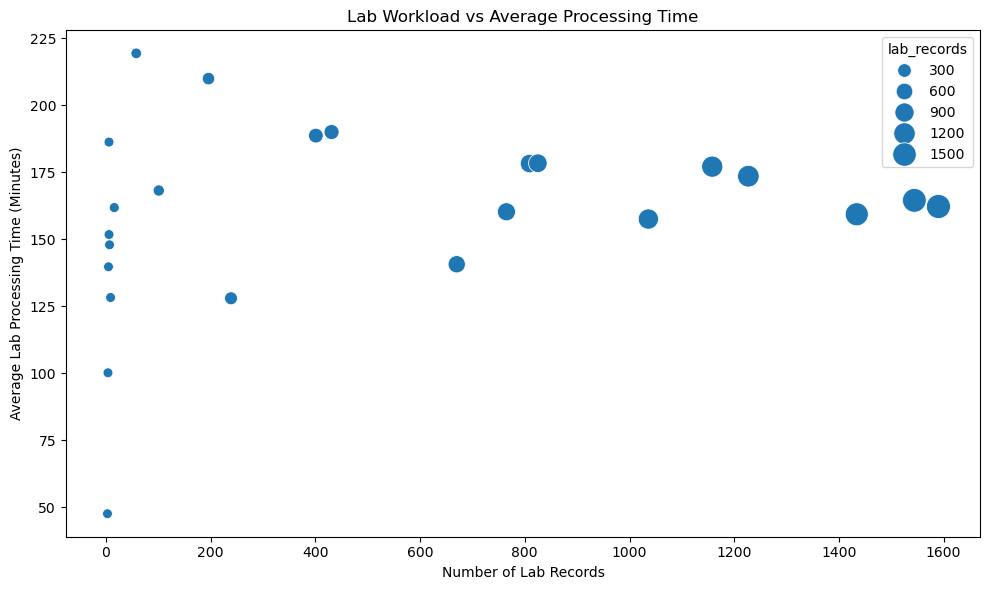

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lab_hourly,
    x='lab_records',
    y='avg_lab_minutes',
    size='lab_records',
    sizes=(50, 300)
)

plt.title('Lab Workload vs Average Processing Time')
plt.xlabel('Number of Lab Records')
plt.ylabel('Average Lab Processing Time (Minutes)')
plt.tight_layout()
plt.show()

In [36]:
df['appointment_to_prescription_minutes'].describe().round(2)

count    61895.00
mean        52.46
std         88.87
min          1.00
25%         14.00
50%         31.00
75%         61.00
max       1438.00
Name: appointment_to_prescription_minutes, dtype: float64

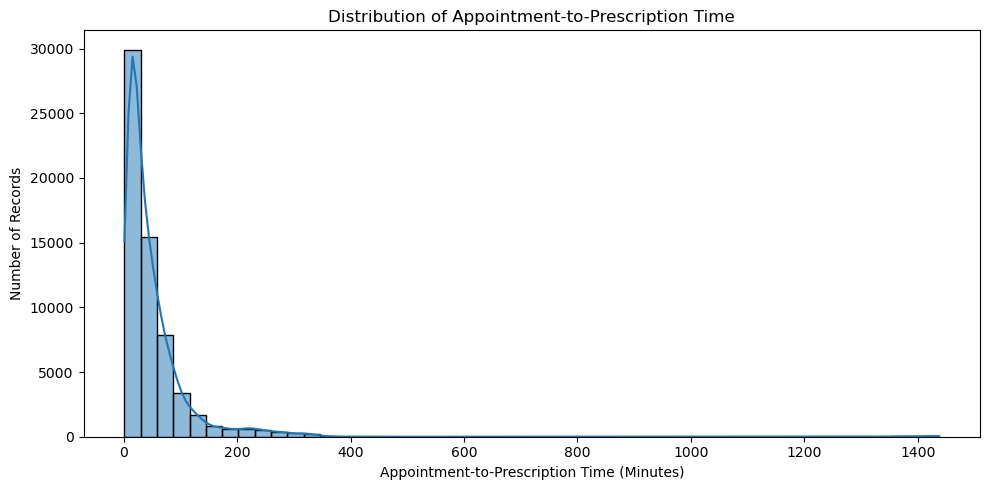

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['appointment_to_prescription_minutes'],
    bins=50,
    kde=True
)

plt.title('Distribution of Appointment-to-Prescription Time')
plt.xlabel('Appointment-to-Prescription Time (Minutes)')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [38]:
df['appointment_to_prescription_minutes'].describe().round(2)

count    61895.00
mean        52.46
std         88.87
min          1.00
25%         14.00
50%         31.00
75%         61.00
max       1438.00
Name: appointment_to_prescription_minutes, dtype: float64

In [39]:
df['appointment_to_prescription_minutes'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

0.50     31.0
0.75     61.0
0.90    106.0
0.95    165.0
0.99    298.0
Name: appointment_to_prescription_minutes, dtype: float64

In [40]:
top_prescription_delays = df[
    df['appointment_to_prescription_minutes'].notna()
].sort_values(
    'appointment_to_prescription_minutes',
    ascending=False
)[[
    'record_no',
    'patient_id',
    'appointment_id',
    'appointment_start_datetime',
    'prescription_doctor_name',
    'appointment_to_prescription_minutes'
]].head(10)

top_prescription_delays

,record_no,patient_id,appointment_id,appointment_start_datetime,prescription_doctor_name,appointment_to_prescription_minutes
25181,25394,211668,239461,2025-05-22 05:42:00,Dr. Zaib Un Nisa,1438
10301,10372,76895,309495,2025-09-09 12:53:00,Dr. Brig (R) Abrar Hussain Zaidi,1438
25183,25396,211668,239461,2025-05-22 05:42:00,Dr. Zaib Un Nisa,1438
25182,25395,211668,239461,2025-05-22 05:42:00,Dr. Zaib Un Nisa,1438
31102,31378,240800,374092,2025-12-08 11:32:00,Dr. Taqdees Abrar,1438
53661,54146,288199,401683,2026-01-19 12:15:00,Dr. Taqdees Abrar,1437
9656,9723,71881,423275,2026-02-18 14:01:00,Dr. Sarah Saleem,1436
57769,58291,296949,423276,2026-02-18 14:02:00,Dr. Sarah Saleem,1435
22538,22717,192055,379631,2025-12-15 14:38:00,Dr. Adnan Asad,1435
23206,23395,197963,210923,2025-04-10 03:53:00,Dr. Alveena Zehra,1434


In [41]:
extreme_delays = df[
    df['appointment_to_prescription_minutes'] >= 1000
].copy()

print("Records with delay >= 1000 minutes:", len(extreme_delays))

extreme_delays[[
    'record_no',
    'patient_id',
    'appointment_id',
    'appointment_start_datetime',
    'prescription_start_datetime',
    'prescription_end_datetime',
    'prescription_doctor_name',
    'appointment_to_prescription_minutes'
]].sort_values(
    'appointment_to_prescription_minutes',
    ascending=False
).head(20)

Records with delay >= 1000 minutes: 182


,record_no,patient_id,appointment_id,appointment_start_datetime,prescription_start_datetime,prescription_end_datetime,prescription_doctor_name,appointment_to_prescription_minutes
31102,31378,240800,374092,2025-12-08 11:32:00,2025-12-09 11:30:00,2025-12-09 11:30:00,Dr. Taqdees Abrar,1438
25181,25394,211668,239461,2025-05-22 05:42:00,2025-05-22 07:39:00,2025-05-23 05:40:00,Dr. Zaib Un Nisa,1438
25182,25395,211668,239461,2025-05-22 05:42:00,2025-05-22 07:39:00,2025-05-23 05:40:00,Dr. Zaib Un Nisa,1438
25183,25396,211668,239461,2025-05-22 05:42:00,2025-05-22 07:39:00,2025-05-23 05:40:00,Dr. Zaib Un Nisa,1438
10301,10372,76895,309495,2025-09-09 12:53:00,2025-09-09 14:05:00,2025-09-10 12:51:00,Dr. Brig (R) Abrar Hussain Zaidi,1438
53661,54146,288199,401683,2026-01-19 12:15:00,2026-01-20 12:12:00,2026-01-20 12:12:00,Dr. Taqdees Abrar,1437
9656,9723,71881,423275,2026-02-18 14:01:00,2026-02-19 13:57:00,2026-02-19 13:57:00,Dr. Sarah Saleem,1436
57769,58291,296949,423276,2026-02-18 14:02:00,2026-02-19 13:56:00,2026-02-19 13:57:00,Dr. Sarah Saleem,1435
22538,22717,192055,379631,2025-12-15 14:38:00,2025-12-16 14:33:00,2025-12-16 14:33:00,Dr. Adnan Asad,1435
23207,23396,197963,210923,2025-04-10 03:53:00,2025-04-10 04:07:00,2025-04-11 03:47:00,Dr. Alveena Zehra,1434


In [42]:
appointment_counts = df['appointment_id'].value_counts()

print("Unique appointments:", df['appointment_id'].nunique())
print("Appointments appearing more than once:",
      (appointment_counts > 1).sum())

appointment_counts[appointment_counts > 1].head(20)

Unique appointments: 49557
Appointments appearing more than once: 4725


appointment_id
427909    28
424659    28
333459    26
381284    24
423497    23
326726    23
411348    23
424643    23
391301    22
375908    22
404643    22
318275    21
385602    20
393950    20
408331    20
410939    19
370401    19
377445    19
341223    17
419645    17
Name: count, dtype: int64

In [43]:
appointment_counts = df['appointment_id'].value_counts()

print("Unique appointments:", df['appointment_id'].nunique())
print("Appointments appearing more than once:",
      (appointment_counts > 1).sum())

appointment_counts[appointment_counts > 1].head(20)

Unique appointments: 49557
Appointments appearing more than once: 4725


appointment_id
427909    28
424659    28
333459    26
381284    24
423497    23
326726    23
411348    23
424643    23
391301    22
375908    22
404643    22
318275    21
385602    20
393950    20
408331    20
410939    19
370401    19
377445    19
341223    17
419645    17
Name: count, dtype: int64

In [44]:
appointment_details = df.groupby('appointment_id').agg(
    record_count=('record_no', 'count'),
    prescription_orders=('prescription_order_id', 'nunique'),
    patients=('patient_id', 'nunique')
).sort_values('record_count', ascending=False)

appointment_details.head(20)

,record_count,prescription_orders,patients
appointment_id,,,
424659,28,2,1
427909,28,2,1
333459,26,1,1
381284,24,1,1
424643,23,1,1
423497,23,1,1
411348,23,1,1
326726,23,1,1
404643,22,1,1


In [45]:
df[df['appointment_id'] == 333459][[
    'record_no',
    'patient_id',
    'appointment_id',
    'prescription_order_id',
    'prescription_start_datetime',
    'prescription_end_datetime',
    'prescription_processing_minutes',
    'lab_id',
    'imaging_request_id',
    'pharmacy_sale_line_id'
]]

,record_no,patient_id,appointment_id,prescription_order_id,prescription_start_datetime,prescription_end_datetime,prescription_processing_minutes,lab_id,imaging_request_id,pharmacy_sale_line_id
10784,10856,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,43626.0,55183.0,NaN
10785,10857,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,43627.0,NaN,NaN
10786,10858,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,67152.0,NaN,NaN
10787,10859,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,67153.0,NaN,NaN
10788,10860,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,67285.0,NaN,NaN
10789,10861,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,85518.0,NaN,NaN
10790,10862,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,85519.0,NaN,NaN
10791,10863,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,85520.0,NaN,NaN
10792,10864,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,85521.0,NaN,NaN
10793,10865,79994,333459,42528,2025-10-11 12:46:00,2025-10-11 12:46:00,0,86565.0,NaN,NaN


In [46]:
# Check duplicates excluding the record number
cols_without_record = [col for col in df.columns if col != 'record_no']

duplicate_without_record = df.duplicated(
    subset=cols_without_record,
    keep=False
)

print("Rows duplicated excluding record_no:",
      duplicate_without_record.sum())

print("Unique duplicated groups:",
      df.loc[duplicate_without_record, cols_without_record]
        .drop_duplicates()
        .shape[0])

Rows duplicated excluding record_no: 8
Unique duplicated groups: 4


In [47]:
df_clean = df.drop_duplicates(
    subset=[col for col in df.columns if col != 'record_no'],
    keep='first'
).copy()

print("Original records:", len(df))
print("Cleaned records:", len(df_clean))
print("Removed true duplicates:", len(df) - len(df_clean))

Original records: 61895
Cleaned records: 61891
Removed true duplicates: 4


In [48]:
print("Remaining duplicate rows:",
      df_clean.duplicated(
          subset=[col for col in df_clean.columns if col != 'record_no']
      ).sum())

Remaining duplicate rows: 0


In [49]:
completion_summary = pd.DataFrame({
    'Department': ['Prescription', 'Lab', 'Imaging', 'Pharmacy'],
    'Completed_Records': [
        df_clean['prescription_processing_minutes'].notna().sum(),
        df_clean['lab_processing_minutes'].notna().sum(),
        df_clean['imaging_processing_minutes'].notna().sum(),
        df_clean['pharmacy_processing_minutes'].notna().sum()
    ]
})

completion_summary['Completion_Percentage'] = (
    completion_summary['Completed_Records']
    / len(df_clean) * 100
).round(2)

completion_summary

,Department,Completed_Records,Completion_Percentage
0,Prescription,61891,100.00
1,Lab,12537,20.26
2,Imaging,5461,8.82
3,Pharmacy,302,0.49


In [50]:
flow_counts = df_clean['flow_name'].value_counts()

print("Number of unique patient flows:", df_clean['flow_name'].nunique())
flow_counts

Number of unique patient flows: 7


flow_name
Appointment â†’ Prescription                           39763
Appointment â†’ Prescription â†’ Lab                   16330
Appointment â†’ Prescription â†’ Imaging                3930
Appointment â†’ Prescription â†’ Lab + Imaging          1566
Appointment â†’ Prescription â†’ Pharmacy                281
Appointment â†’ Prescription â†’ Lab + Pharmacy           20
Appointment â†’ Prescription â†’ Imaging + Pharmacy        1
Name: count, dtype: int64

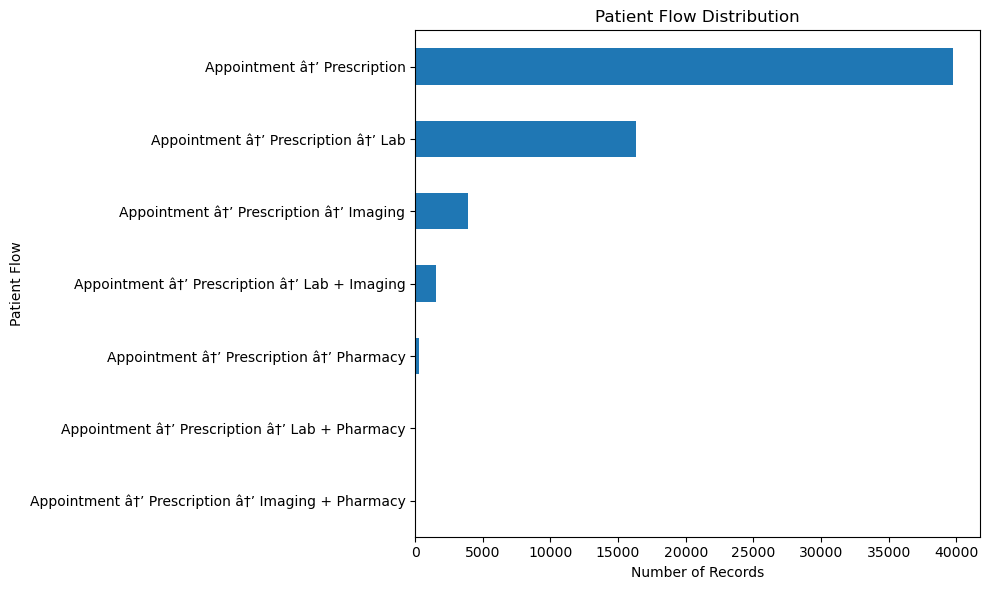

In [51]:
plt.figure(figsize=(10, 6))

flow_counts.sort_values().plot(kind='barh')

plt.title('Patient Flow Distribution')
plt.xlabel('Number of Records')
plt.ylabel('Patient Flow')

plt.tight_layout()
plt.show()

In [52]:
flow_processing = df_clean.groupby('flow_name').agg(
    Average_Processing_Time=('appointment_to_prescription_minutes', 'mean'),
    Patient_Records=('record_no', 'count')
).reset_index()

flow_processing['Average_Processing_Time'] = (
    flow_processing['Average_Processing_Time'].round(2)
)

flow_processing.sort_values(
    'Average_Processing_Time',
    ascending=False
)

,flow_name,Average_Processing_Time,Patient_Records
4,Appointment â†’ Prescription â†’ Lab + Imaging,73.42,1566
1,Appointment â†’ Prescription â†’ Imaging,68.55,3930
2,Appointment â†’ Prescription â†’ Imaging + Pha...,62.00,1
3,Appointment â†’ Prescription â†’ Lab,58.99,16330
0,Appointment â†’ Prescription,47.58,39763
6,Appointment â†’ Prescription â†’ Pharmacy,24.58,281
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,19.50,20


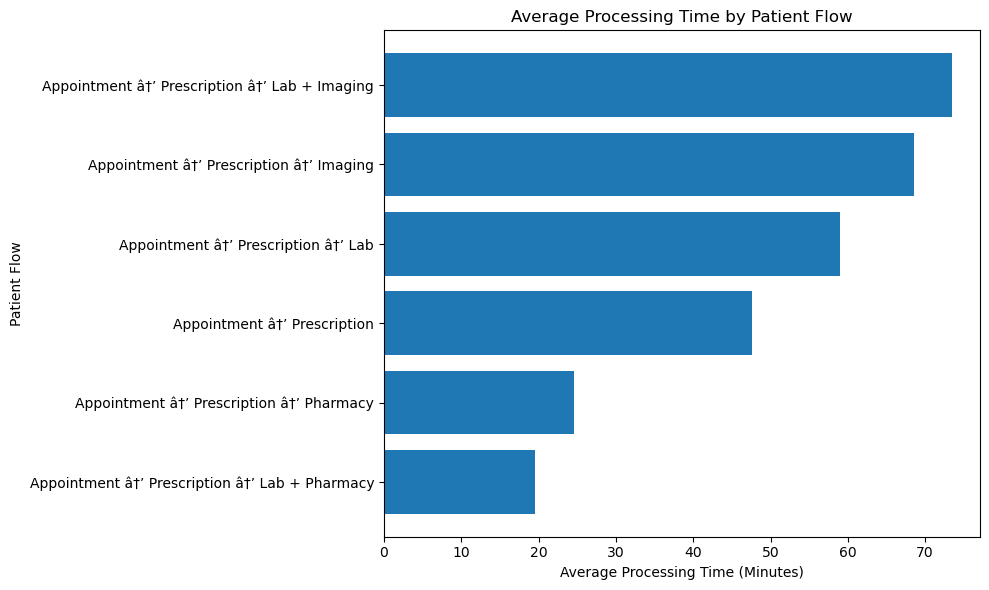

In [53]:
plt.figure(figsize=(10, 6))

flow_chart = flow_processing[
    flow_processing['Patient_Records'] >= 20
].sort_values('Average_Processing_Time')

plt.barh(
    flow_chart['flow_name'],
    flow_chart['Average_Processing_Time']
)

plt.title('Average Processing Time by Patient Flow')
plt.xlabel('Average Processing Time (Minutes)')
plt.ylabel('Patient Flow')

plt.tight_layout()
plt.show()

In [54]:
monthly_counts = (
    df_clean.groupby('appointment_month')
    .size()
    .reset_index(name='Appointment_Count')
)

monthly_counts

,appointment_month,Appointment_Count
0,2024-04,2
1,2024-05,2
2,2024-06,2
3,2024-07,2
4,2024-08,1
5,2024-12,2
6,2025-02,3
7,2025-03,31
8,2025-04,125
9,2025-05,524


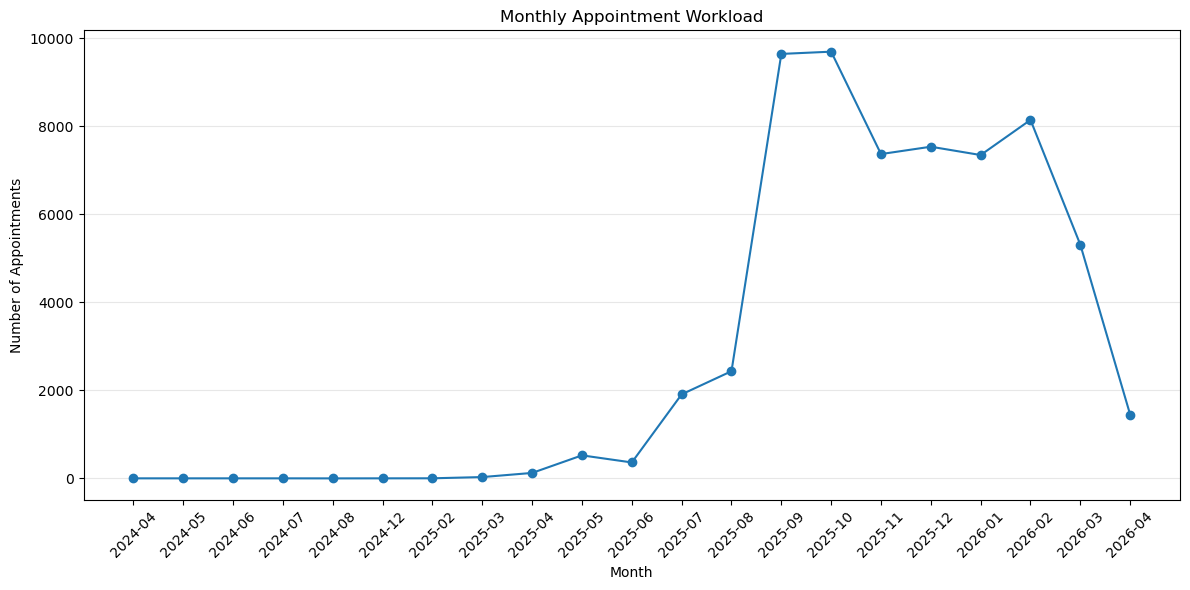

In [55]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_counts['appointment_month'].astype(str),
    monthly_counts['Appointment_Count'],
    marker='o'
)

plt.title('Monthly Appointment Workload')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
monthly_processing = (
    df_clean.groupby('appointment_month')
    .agg(
        Appointment_Count=('record_no', 'count'),
        Average_Processing_Time=('appointment_to_prescription_minutes', 'mean')
    )
    .reset_index()
)

monthly_processing['Average_Processing_Time'] = (
    monthly_processing['Average_Processing_Time'].round(2)
)

monthly_processing


,appointment_month,Appointment_Count,Average_Processing_Time
0,2024-04,2,561.50
1,2024-05,2,80.00
2,2024-06,2,59.00
3,2024-07,2,36.50
4,2024-08,1,24.00
5,2024-12,2,651.00
6,2025-02,3,16.67
7,2025-03,31,86.13
8,2025-04,125,68.46
9,2025-05,524,80.61


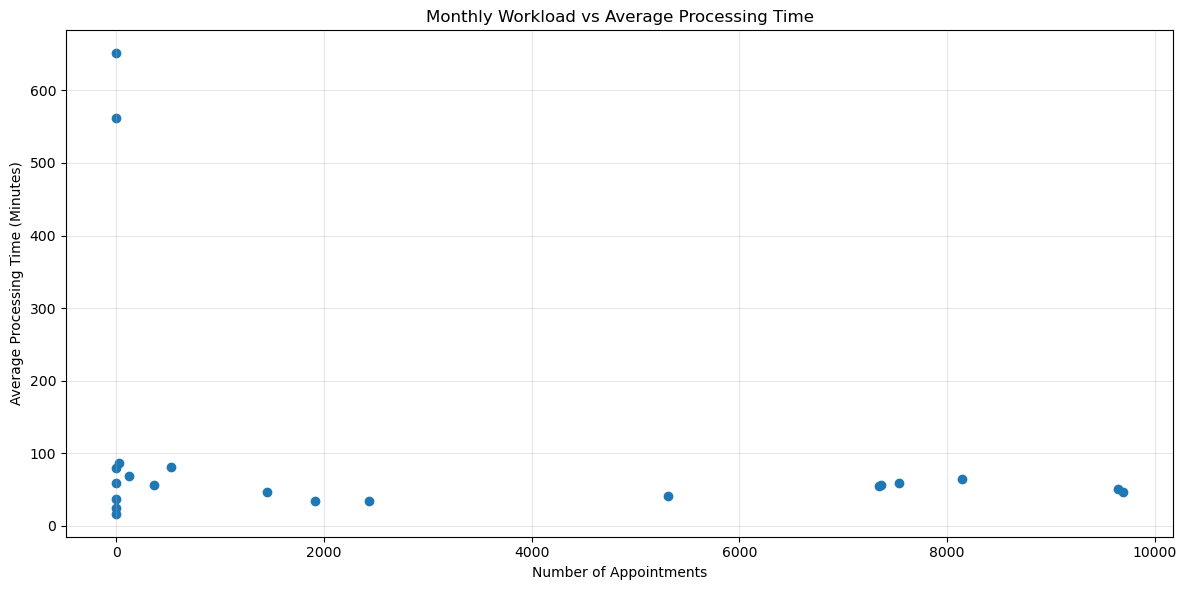

In [57]:
plt.figure(figsize=(12, 6))

plt.scatter(
    monthly_processing['Appointment_Count'],
    monthly_processing['Average_Processing_Time']
)

plt.title('Monthly Workload vs Average Processing Time')
plt.xlabel('Number of Appointments')
plt.ylabel('Average Processing Time (Minutes)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Use only months with at least 500 appointments
high_volume_months = monthly_processing[
    monthly_processing['Appointment_Count'] >= 500
].copy()

correlation = high_volume_months[
    ['Appointment_Count', 'Average_Processing_Time']
].corr().iloc[0, 1]

print("Correlation between workload and processing time:",
      round(correlation, 2))

Correlation between workload and processing time: 0.07


In [59]:
department_processing = pd.DataFrame({
    'Department': ['Prescription', 'Lab', 'Imaging', 'Pharmacy'],
    'Average_Time': [
        df_clean['prescription_processing_minutes'].mean(),
        df_clean['lab_processing_minutes'].mean(),
        df_clean['imaging_processing_minutes'].mean(),
        df_clean['pharmacy_processing_minutes'].mean()
    ],
    'Completed_Records': [
        df_clean['prescription_processing_minutes'].notna().sum(),
        df_clean['lab_processing_minutes'].notna().sum(),
        df_clean['imaging_processing_minutes'].notna().sum(),
        df_clean['pharmacy_processing_minutes'].notna().sum()
    ]
})

department_processing['Average_Time'] = (
    department_processing['Average_Time'].round(2)
)

department_processing

,Department,Average_Time,Completed_Records
0,Prescription,3.11,61891
1,Lab,167.29,12537
2,Imaging,11.12,5461
3,Pharmacy,5.36,302


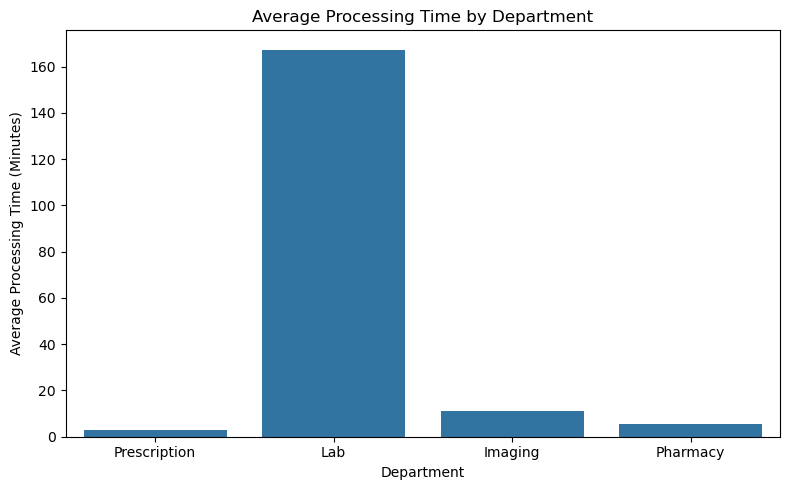

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=department_processing,
    x='Department',
    y='Average_Time'
)

plt.title('Average Processing Time by Department')
plt.xlabel('Department')
plt.ylabel('Average Processing Time (Minutes)')

plt.tight_layout()
plt.show()

In [61]:
# Average Lab Processing Time by Appointment Hour

lab_hourly = (
    df_clean[df_clean['lab_processing_minutes'].notna()]
    .groupby('appointment_hour')['lab_processing_minutes']
    .agg(['mean', 'count'])
    .reset_index()
)

lab_hourly['mean'] = lab_hourly['mean'].round(2)

lab_hourly

,appointment_hour,mean,count
0,0,47.67,3
1,1,151.83,6
2,2,128.33,9
3,3,128.04,239
4,4,140.74,670
5,5,164.58,1544
6,6,162.29,1590
7,7,177.16,1158
8,8,190.07,431
9,9,178.09,810


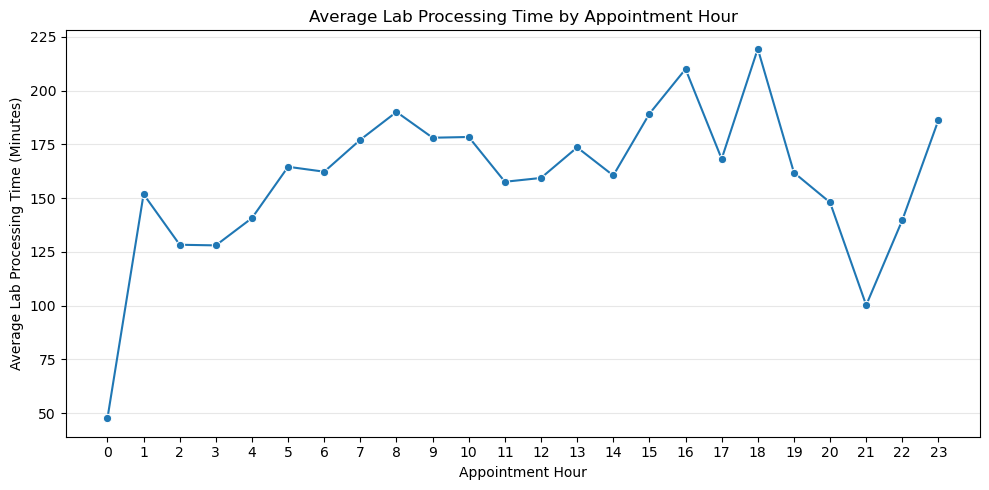

In [62]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=lab_hourly,
    x='appointment_hour',
    y='mean',
    marker='o'
)

plt.title('Average Lab Processing Time by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Average Lab Processing Time (Minutes)')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
lab_hourly.sort_values(
    'mean',
    ascending=False
)

,appointment_hour,mean,count
18,18,219.43,58
16,16,210.01,196
8,8,190.07,431
15,15,189.23,399
23,23,186.33,6
10,10,178.43,825
9,9,178.09,810
7,7,177.16,1158
13,13,173.59,1227
17,17,168.25,101


In [64]:
# Filter hours with at least 100 Lab records
reliable_lab_hours = lab_hourly[
    lab_hourly['count'] >= 100
].copy()

reliable_lab_hours = reliable_lab_hours.sort_values(
    'mean',
    ascending=False
)

reliable_lab_hours

,appointment_hour,mean,count
16,16,210.01,196
8,8,190.07,431
15,15,189.23,399
10,10,178.43,825
9,9,178.09,810
7,7,177.16,1158
13,13,173.59,1227
17,17,168.25,101
5,5,164.58,1544
6,6,162.29,1590


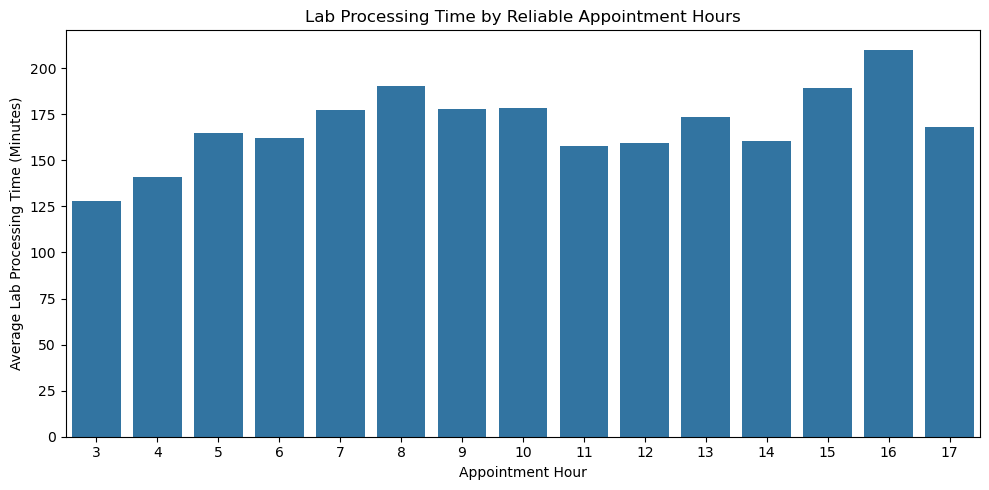

In [65]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=reliable_lab_hours,
    x='appointment_hour',
    y='mean'
)

plt.title('Lab Processing Time by Reliable Appointment Hours')
plt.xlabel('Appointment Hour')
plt.ylabel('Average Lab Processing Time (Minutes)')

plt.tight_layout()
plt.show()

In [66]:
lab_workload = (
    df_clean[df_clean['lab_processing_minutes'].notna()]
    .groupby('appointment_hour')
    .agg(
        Lab_Records=('lab_processing_minutes', 'count'),
        Avg_Lab_Time=('lab_processing_minutes', 'mean')
    )
    .reset_index()
)

lab_workload['Avg_Lab_Time'] = lab_workload['Avg_Lab_Time'].round(2)

lab_workload


,appointment_hour,Lab_Records,Avg_Lab_Time
0,0,3,47.67
1,1,6,151.83
2,2,9,128.33
3,3,239,128.04
4,4,670,140.74
5,5,1544,164.58
6,6,1590,162.29
7,7,1158,177.16
8,8,431,190.07
9,9,810,178.09


In [67]:
lab_correlation = lab_workload[
    ['Lab_Records', 'Avg_Lab_Time']
].corr().iloc[0, 1]

print("Correlation between Lab workload and processing time:",
      round(lab_correlation, 2))


Correlation between Lab workload and processing time: 0.22


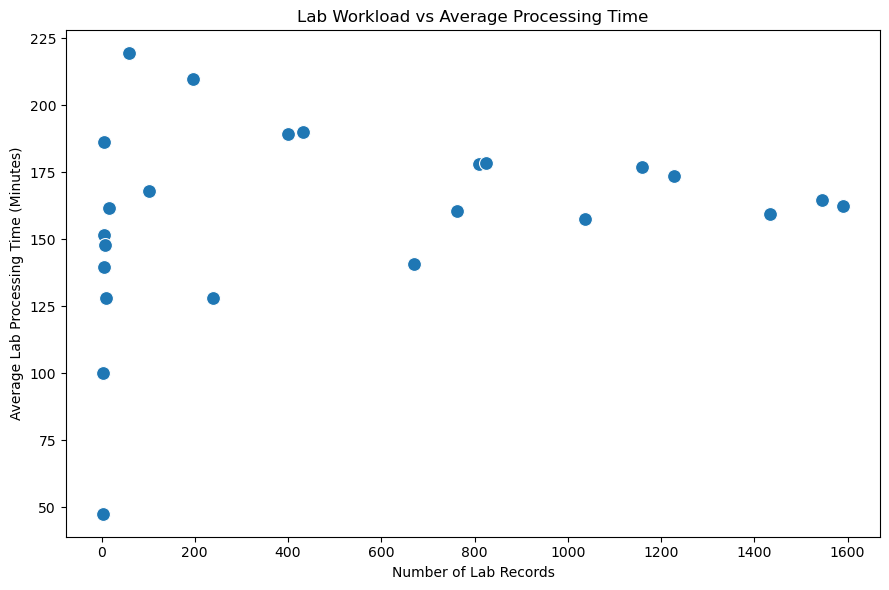

In [68]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=lab_workload,
    x='Lab_Records',
    y='Avg_Lab_Time',
    s=100
)

plt.title('Lab Workload vs Average Processing Time')
plt.xlabel('Number of Lab Records')
plt.ylabel('Average Lab Processing Time (Minutes)')

plt.tight_layout()
plt.show()

In [69]:
# Create day of week
df_clean['appointment_day'] = (
    df_clean['appointment_start_datetime'].dt.day_name()
)

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_workload = (
    df_clean.groupby('appointment_day')
    .size()
    .reindex(day_order)
    .reset_index(name='Appointment_Count')
)

daily_workload

,appointment_day,Appointment_Count
0,Monday,12439
1,Tuesday,10778
2,Wednesday,9417
3,Thursday,9341
4,Friday,9188
5,Saturday,8261
6,Sunday,2467


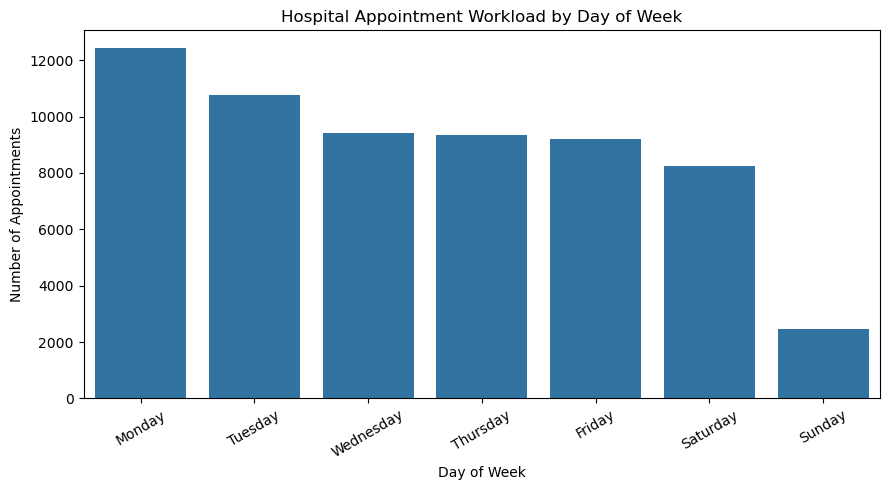

In [70]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=daily_workload,
    x='appointment_day',
    y='Appointment_Count'
)

plt.title('Hospital Appointment Workload by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [71]:
daily_processing = (
    df_clean.groupby('appointment_day')
    .agg(
        Average_Processing_Time=(
            'appointment_to_prescription_minutes',
            'mean'
        ),
        Appointment_Count=('record_no', 'count')
    )
    .reindex(day_order)
    .reset_index()
)

daily_processing['Average_Processing_Time'] = (
    daily_processing['Average_Processing_Time'].round(2)
)

daily_processing

,appointment_day,Average_Processing_Time,Appointment_Count
0,Monday,57.02,12439
1,Tuesday,56.58,10778
2,Wednesday,49.28,9417
3,Thursday,49.94,9341
4,Friday,49.44,9188
5,Saturday,59.74,8261
6,Sunday,20.06,2467


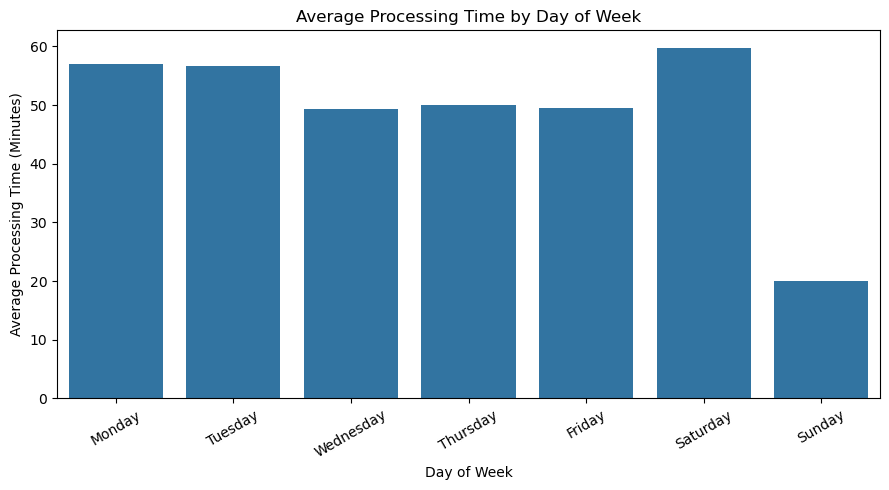

In [72]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=daily_processing,
    x='appointment_day',
    y='Average_Processing_Time'
)

plt.title('Average Processing Time by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Processing Time (Minutes)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [73]:
daily_correlation = daily_processing[
    ['Appointment_Count', 'Average_Processing_Time']
].corr().iloc[0, 1]

print(
    "Correlation between daily workload and processing time:",
    round(daily_correlation, 2)
)

Correlation between daily workload and processing time: 0.89


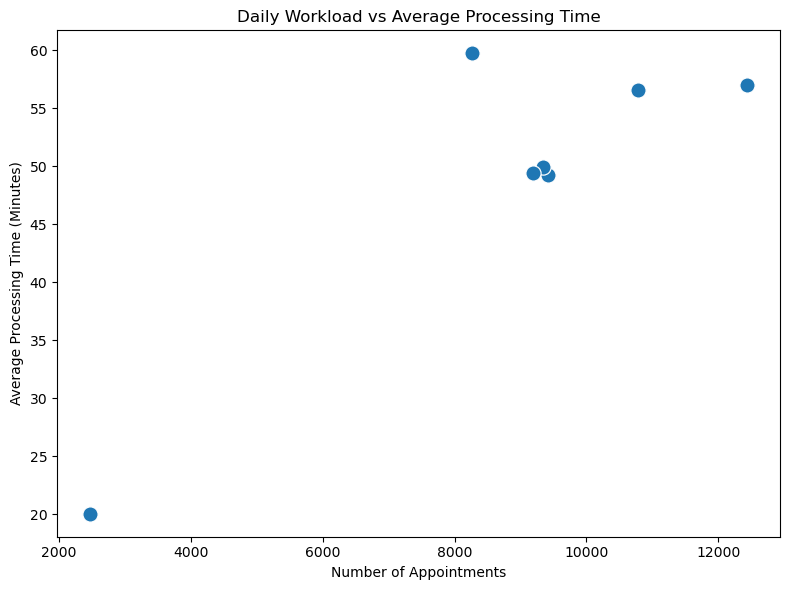

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=daily_processing,
    x='Appointment_Count',
    y='Average_Processing_Time',
    s=120
)

plt.title('Daily Workload vs Average Processing Time')
plt.xlabel('Number of Appointments')
plt.ylabel('Average Processing Time (Minutes)')

plt.tight_layout()
plt.show()

In [75]:
monthly_processing = (
    df_clean
    .groupby('appointment_month')
    .agg(
        Appointment_Count=('record_no', 'count'),
        Average_Processing_Time=(
            'appointment_to_prescription_minutes',
            'mean'
        )
    )
    .reset_index()
)

monthly_processing['Average_Processing_Time'] = (
    monthly_processing['Average_Processing_Time'].round(2)
)

monthly_processing

,appointment_month,Appointment_Count,Average_Processing_Time
0,2024-04,2,561.50
1,2024-05,2,80.00
2,2024-06,2,59.00
3,2024-07,2,36.50
4,2024-08,1,24.00
5,2024-12,2,651.00
6,2025-02,3,16.67
7,2025-03,31,86.13
8,2025-04,125,68.46
9,2025-05,524,80.61


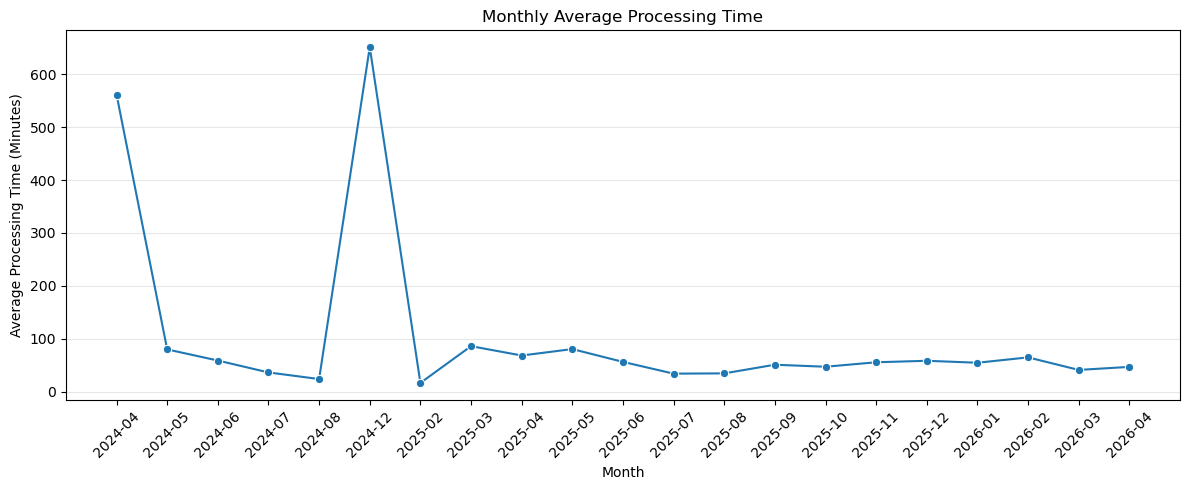

In [76]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_processing,
    x='appointment_month',
    y='Average_Processing_Time',
    marker='o'
)

plt.title('Monthly Average Processing Time')
plt.xlabel('Month')
plt.ylabel('Average Processing Time (Minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
reliable_months = monthly_processing[
    monthly_processing['Appointment_Count'] >= 100
].copy()

reliable_months = reliable_months.sort_values('appointment_month')

reliable_months

,appointment_month,Appointment_Count,Average_Processing_Time
8,2025-04,125,68.46
9,2025-05,524,80.61
10,2025-06,363,56.42
11,2025-07,1910,34.23
12,2025-08,2436,34.70
13,2025-09,9643,51.06
14,2025-10,9694,47.25
15,2025-11,7368,55.69
16,2025-12,7535,58.51
17,2026-01,7346,54.81


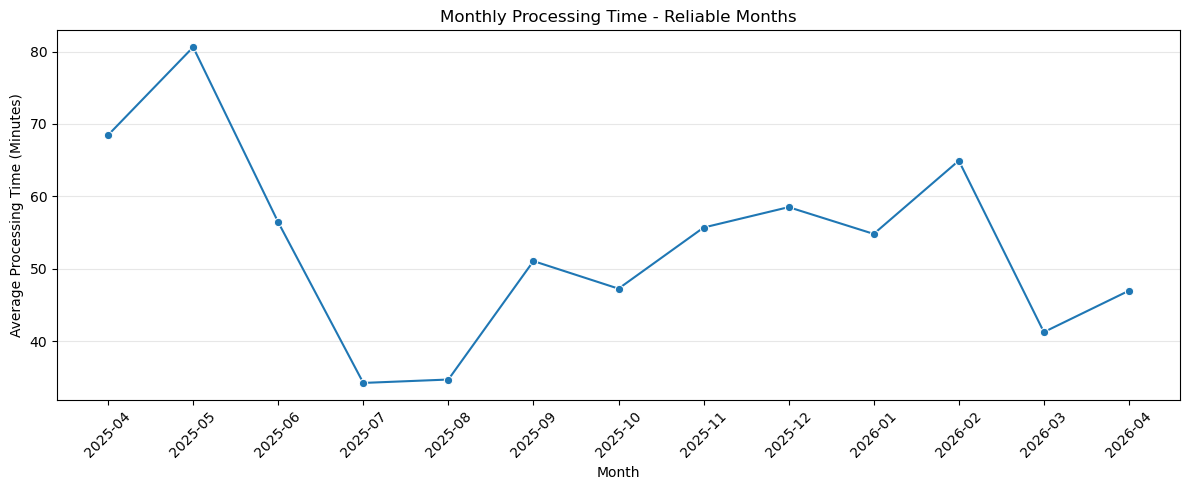

In [78]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=reliable_months,
    x='appointment_month',
    y='Average_Processing_Time',
    marker='o'
)

plt.title('Monthly Processing Time - Reliable Months')
plt.xlabel('Month')
plt.ylabel('Average Processing Time (Minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
monthly_correlation = monthly_processing[
    monthly_processing['Appointment_Count'] >= 100
][[
    'Appointment_Count',
    'Average_Processing_Time'
]].corr().iloc[0, 1]

print(
    "Correlation between monthly workload and processing time:",
    round(monthly_correlation, 2)
)

Correlation between monthly workload and processing time: -0.11


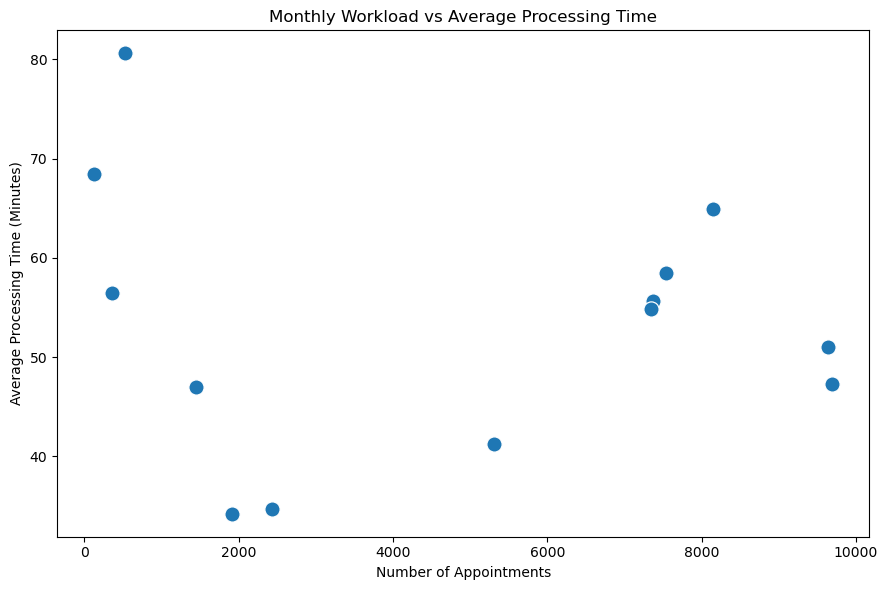

In [80]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=reliable_months,
    x='Appointment_Count',
    y='Average_Processing_Time',
    s=120
)

plt.title('Monthly Workload vs Average Processing Time')
plt.xlabel('Number of Appointments')
plt.ylabel('Average Processing Time (Minutes)')

plt.tight_layout()
plt.show()

In [81]:
doctor_analysis = (
    df_clean[df_clean['prescription_doctor_name'].notna()]
    .groupby('prescription_doctor_name')
    .agg(
        Appointment_Count=('record_no', 'count'),
        Average_Processing_Time=(
            'appointment_to_prescription_minutes',
            'mean'
        )
    )
    .reset_index()
)

doctor_analysis['Average_Processing_Time'] = (
    doctor_analysis['Average_Processing_Time'].round(2)
)

# Keep doctors with enough records
reliable_doctors = doctor_analysis[
    doctor_analysis['Appointment_Count'] >= 50
].copy()

reliable_doctors.sort_values(
    'Average_Processing_Time',
    ascending=False
).head(15)

,prescription_doctor_name,Appointment_Count,Average_Processing_Time
13,Dr. Adnan Asad,176,213.51
24,Dr. Asia Ashraf,2013,213.04
64,Dr. Salma Jabeen,1339,175.47
16,Dr. Alveena Zehra,112,147.84
67,Dr. Sarah Saleem,789,109.97
72,Dr. Sobia Khalid,54,99.11
7,Dr. Abdul Nasir,271,89.47
26,Dr. Brig (R) Abrar Hussain Zaidi,72,88.47
31,Dr. Fauzan Abdullah,264,85.62
20,Dr. Ammara Pirzada,566,83.19


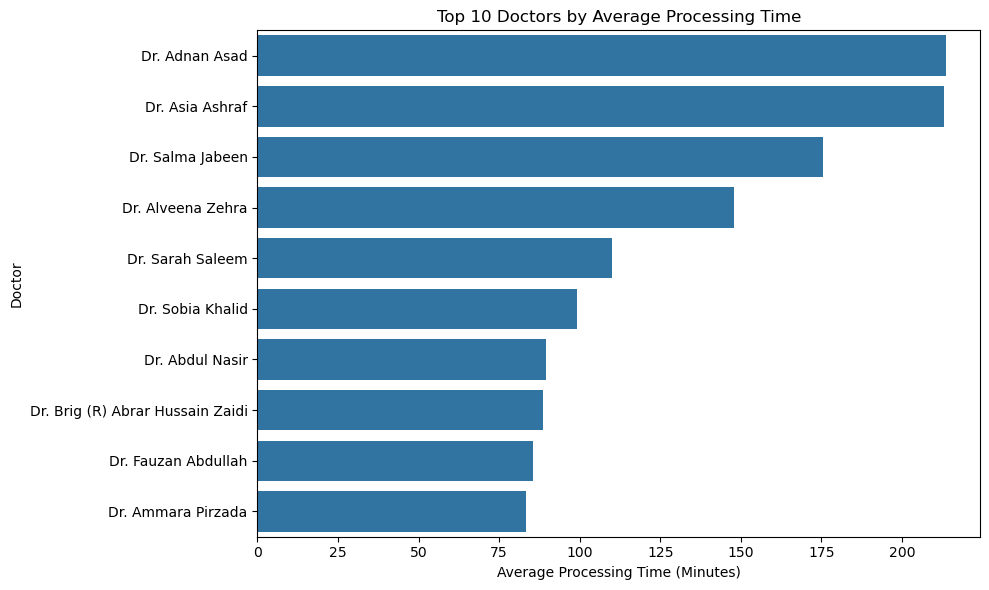

In [82]:
top_doctors = reliable_doctors.sort_values(
    'Average_Processing_Time',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_doctors,
    x='Average_Processing_Time',
    y='prescription_doctor_name'
)

plt.title('Top 10 Doctors by Average Processing Time')
plt.xlabel('Average Processing Time (Minutes)')
plt.ylabel('Doctor')

plt.tight_layout()
plt.show()

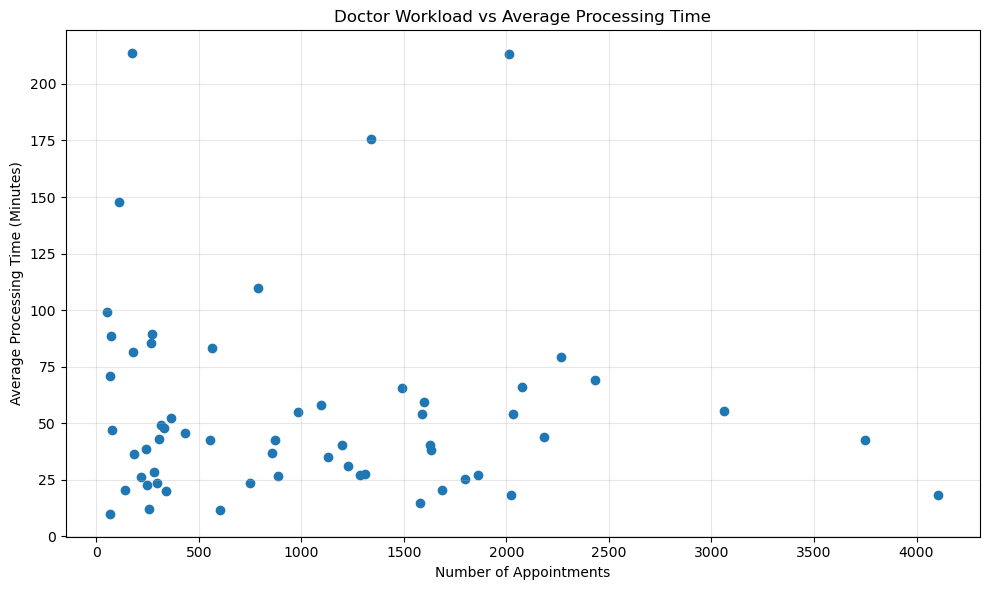

In [83]:
plt.figure(figsize=(10,6))

plt.scatter(
    reliable_doctors['Appointment_Count'],
    reliable_doctors['Average_Processing_Time']
)

plt.xlabel('Number of Appointments')
plt.ylabel('Average Processing Time (Minutes)')
plt.title('Doctor Workload vs Average Processing Time')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
doctor_correlation = reliable_doctors[
    ['Appointment_Count', 'Average_Processing_Time']
].corr().iloc[0,1]

print(
    "Correlation between doctor workload and processing time:",
    round(doctor_correlation, 2)
)


Correlation between doctor workload and processing time: -0.06


In [85]:
flow_analysis = df_clean.groupby('flow_name').agg(
    Patient_Records=('record_no', 'count'),
    Average_Processing_Time=('appointment_to_prescription_minutes', 'mean')
).reset_index()

flow_analysis['Average_Processing_Time'] = (
    flow_analysis['Average_Processing_Time'].round(2)
)

flow_analysis = flow_analysis.sort_values(
    'Patient_Records',
    ascending=False
)

flow_analysis

,flow_name,Patient_Records,Average_Processing_Time
0,Appointment â†’ Prescription,39763,47.58
3,Appointment â†’ Prescription â†’ Lab,16330,58.99
1,Appointment â†’ Prescription â†’ Imaging,3930,68.55
4,Appointment â†’ Prescription â†’ Lab + Imaging,1566,73.42
6,Appointment â†’ Prescription â†’ Pharmacy,281,24.58
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,20,19.50
2,Appointment â†’ Prescription â†’ Imaging + Pha...,1,62.00


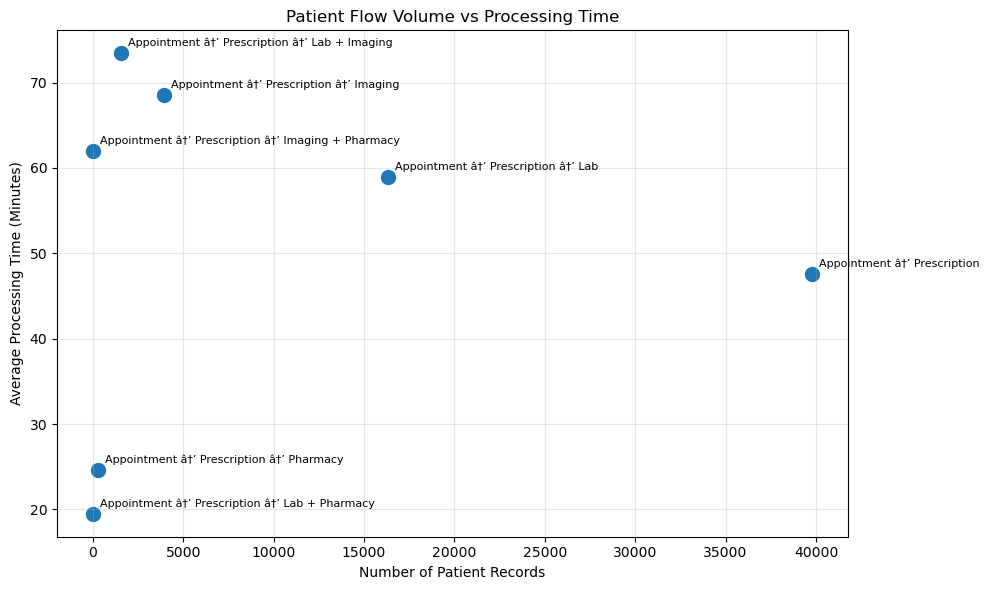

In [86]:
plt.figure(figsize=(10,6))

plt.scatter(
    flow_analysis['Patient_Records'],
    flow_analysis['Average_Processing_Time'],
    s=100
)

for _, row in flow_analysis.iterrows():
    plt.annotate(
        row['flow_name'],
        (row['Patient_Records'], row['Average_Processing_Time']),
        xytext=(5,5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Number of Patient Records')
plt.ylabel('Average Processing Time (Minutes)')
plt.title('Patient Flow Volume vs Processing Time')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
flow_analysis = df_clean.groupby('flow_name').agg(
    Patient_Records=('record_no', 'count'),
    Average_Processing_Time=('appointment_to_prescription_minutes', 'mean')
).reset_index()

flow_analysis['Average_Processing_Time'] = (
    flow_analysis['Average_Processing_Time'].round(2)
)

flow_analysis = flow_analysis.sort_values(
    'Patient_Records',
    ascending=False
)

flow_analysis

,flow_name,Patient_Records,Average_Processing_Time
0,Appointment â†’ Prescription,39763,47.58
3,Appointment â†’ Prescription â†’ Lab,16330,58.99
1,Appointment â†’ Prescription â†’ Imaging,3930,68.55
4,Appointment â†’ Prescription â†’ Lab + Imaging,1566,73.42
6,Appointment â†’ Prescription â†’ Pharmacy,281,24.58
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,20,19.50
2,Appointment â†’ Prescription â†’ Imaging + Pha...,1,62.00


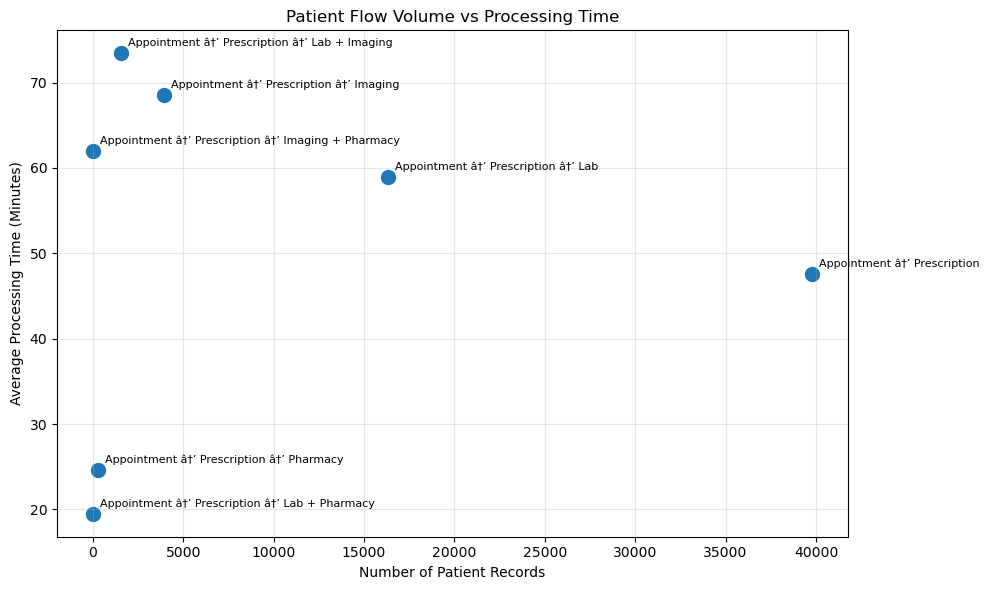

In [88]:
plt.figure(figsize=(10,6))

plt.scatter(
    flow_analysis['Patient_Records'],
    flow_analysis['Average_Processing_Time'],
    s=100
)

for _, row in flow_analysis.iterrows():
    plt.annotate(
        row['flow_name'],
        (row['Patient_Records'], row['Average_Processing_Time']),
        xytext=(5,5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Number of Patient Records')
plt.ylabel('Average Processing Time (Minutes)')
plt.title('Patient Flow Volume vs Processing Time')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
lab_stats = df_clean['lab_processing_minutes'].describe().round(2)

lab_stats

count    12537.00
mean       167.29
std        179.17
min          0.00
25%         74.00
50%        119.00
75%        190.00
max       1439.00
Name: lab_processing_minutes, dtype: float64

In [90]:
lab_percentiles = df_clean['lab_processing_minutes'].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

lab_percentiles

0.25      74.00
0.50     119.00
0.75     190.00
0.90     299.00
0.95     456.20
0.99    1107.48
Name: lab_processing_minutes, dtype: float64

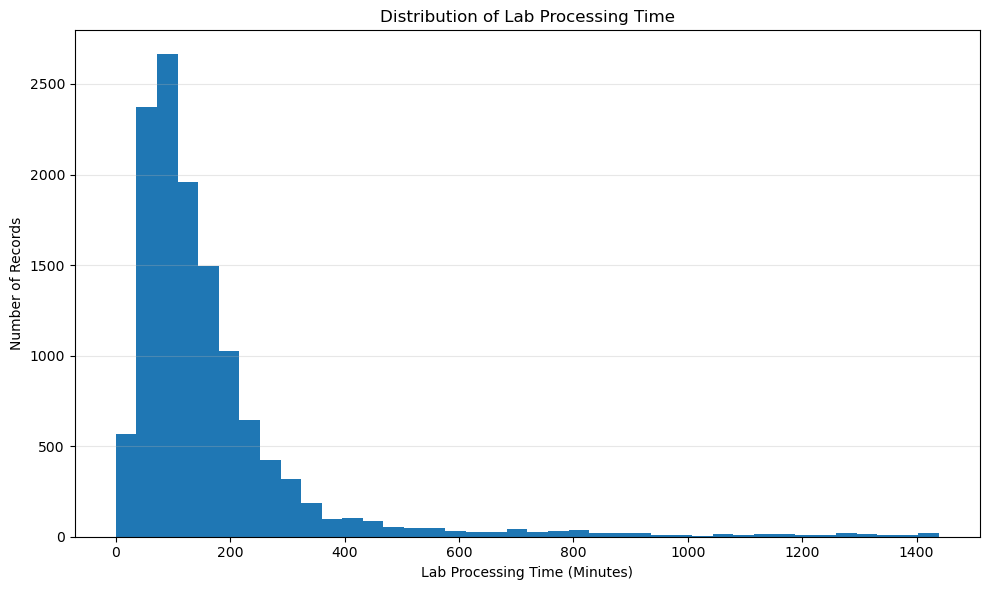

In [91]:
plt.figure(figsize=(10,6))

plt.hist(
    df_clean['lab_processing_minutes'].dropna(),
    bins=40
)

plt.xlabel('Lab Processing Time (Minutes)')
plt.ylabel('Number of Records')
plt.title('Distribution of Lab Processing Time')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
lab_hour_analysis = df_clean.groupby(
    'appointment_start_datetime'
).agg(
    Average_Lab_Time=('lab_processing_minutes', 'mean'),
    Lab_Records=('lab_processing_minutes', 'count')
).reset_index()

In [93]:
df_clean['appointment_hour'] = (
    df_clean['appointment_start_datetime'].dt.hour
)

In [94]:
lab_hour_analysis = df_clean.groupby('appointment_hour').agg(
    Average_Lab_Time=('lab_processing_minutes', 'mean'),
    Lab_Records=('lab_processing_minutes', 'count')
).reset_index()

lab_hour_analysis = lab_hour_analysis[
    lab_hour_analysis['Lab_Records'] >= 30
].copy()

lab_hour_analysis['Average_Lab_Time'] = (
    lab_hour_analysis['Average_Lab_Time'].round(2)
)

lab_hour_analysis.sort_values(
    'Average_Lab_Time',
    ascending=False
)

,appointment_hour,Average_Lab_Time,Lab_Records
18,18,219.43,58
16,16,210.01,196
8,8,190.07,431
15,15,189.23,399
10,10,178.43,825
9,9,178.09,810
7,7,177.16,1158
13,13,173.59,1227
17,17,168.25,101
5,5,164.58,1544


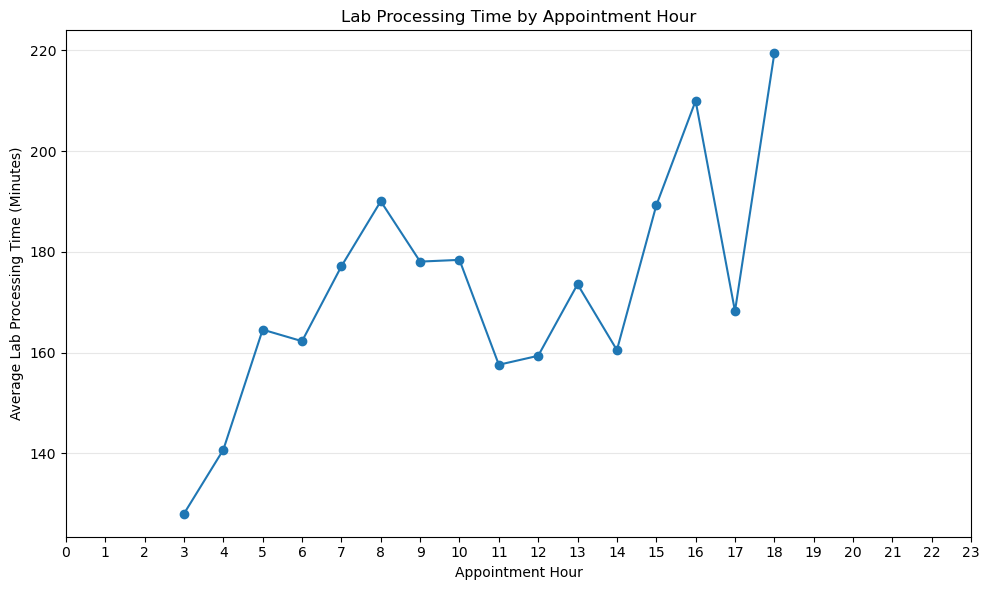

In [95]:
plt.figure(figsize=(10,6))

plt.plot(
    lab_hour_analysis['appointment_hour'],
    lab_hour_analysis['Average_Lab_Time'],
    marker='o'
)

plt.xlabel('Appointment Hour')
plt.ylabel('Average Lab Processing Time (Minutes)')
plt.title('Lab Processing Time by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [96]:
lab_hour_analysis = df_clean.groupby('appointment_hour').agg(
    Average_Lab_Time=('lab_processing_minutes', 'mean'),
    Lab_Records=('lab_processing_minutes', 'count')
).reset_index()

lab_hour_analysis = lab_hour_analysis[
    lab_hour_analysis['Lab_Records'] >= 30
].copy()

lab_hour_analysis['Average_Lab_Time'] = (
    lab_hour_analysis['Average_Lab_Time'].round(2)
)

lab_hour_analysis.sort_values(
    'Lab_Records',
    ascending=False
)

,appointment_hour,Average_Lab_Time,Lab_Records
6,6,162.29,1590
5,5,164.58,1544
12,12,159.39,1434
13,13,173.59,1227
7,7,177.16,1158
11,11,157.61,1036
10,10,178.43,825
9,9,178.09,810
14,14,160.53,763
4,4,140.74,670


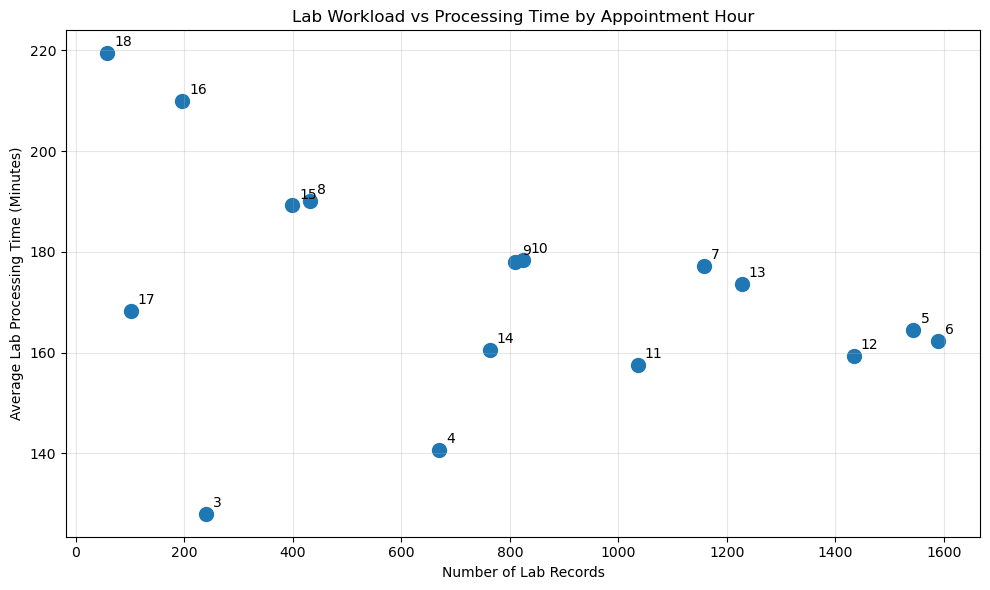

In [97]:
plt.figure(figsize=(10,6))

plt.scatter(
    lab_hour_analysis['Lab_Records'],
    lab_hour_analysis['Average_Lab_Time'],
    s=100
)

for _, row in lab_hour_analysis.iterrows():
    plt.annotate(
        str(int(row['appointment_hour'])),
        (row['Lab_Records'], row['Average_Lab_Time']),
        xytext=(5,5),
        textcoords='offset points'
    )

plt.xlabel('Number of Lab Records')
plt.ylabel('Average Lab Processing Time (Minutes)')
plt.title('Lab Workload vs Processing Time by Appointment Hour')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
lab_hour_correlation = lab_hour_analysis[
    ['Lab_Records', 'Average_Lab_Time']
].corr().iloc[0,1]

print(
    "Correlation between Lab workload and processing time:",
    round(lab_hour_correlation, 2)
)

Correlation between Lab workload and processing time: -0.35


In [99]:
lab_data = df_clean['lab_processing_minutes'].dropna()

Q1 = lab_data.quantile(0.25)
Q3 = lab_data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))

Q1: 74.0
Q3: 190.0
IQR: 116.0
Lower bound: -100.0
Upper bound: 364.0


In [100]:
lab_outliers = lab_data[
    (lab_data < lower_bound) |
    (lab_data > upper_bound)
]

print("Total Lab records:", len(lab_data))
print("Lab outliers:", len(lab_outliers))
print(
    "Outlier percentage:",
    round(len(lab_outliers) / len(lab_data) * 100, 2),
    "%"
)


Total Lab records: 12537
Lab outliers: 871
Outlier percentage: 6.95 %


In [101]:
lab_without_outliers = lab_data[
    (lab_data >= lower_bound) &
    (lab_data <= upper_bound)
]

print(
    "Average Lab time - All records:",
    round(lab_data.mean(), 2)
)

print(
    "Average Lab time - Without outliers:",
    round(lab_without_outliers.mean(), 2)
)

Average Lab time - All records: 167.29
Average Lab time - Without outliers: 127.99


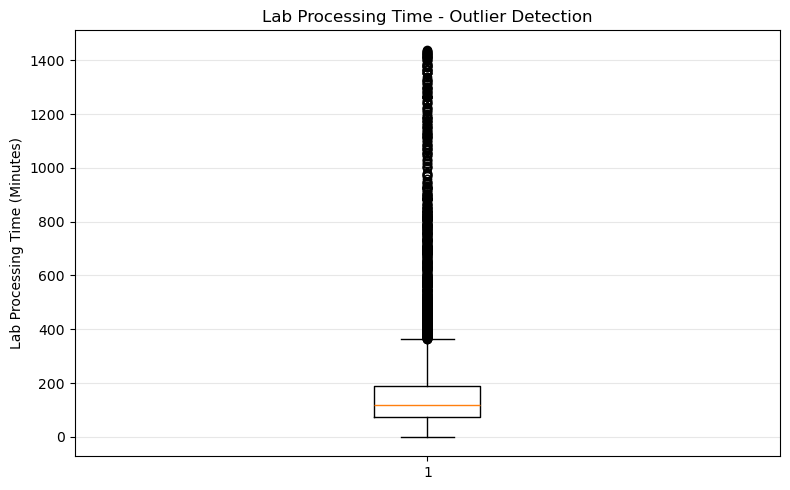

In [102]:
plt.figure(figsize=(8,5))

plt.boxplot(lab_data)

plt.ylabel('Lab Processing Time (Minutes)')
plt.title('Lab Processing Time - Outlier Detection')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [103]:
# Identify extreme Lab processing records
lab_outlier_df = df_clean[
    df_clean['lab_processing_minutes'] > upper_bound
].copy()

# Group extreme delays by appointment hour
outlier_by_hour = (
    lab_outlier_df
    .groupby('appointment_hour')
    .agg(
        Outlier_Records=('lab_processing_minutes', 'count'),
        Average_Outlier_Time=('lab_processing_minutes', 'mean'),
        Maximum_Processing_Time=('lab_processing_minutes', 'max')
    )
    .reset_index()
    .sort_values('Outlier_Records', ascending=False)
)

outlier_by_hour['Average_Outlier_Time'] = (
    outlier_by_hour['Average_Outlier_Time'].round(2)
)

outlier_by_hour['Maximum_Processing_Time'] = (
    outlier_by_hour['Maximum_Processing_Time'].round(2)
)

outlier_by_hour

,appointment_hour,Outlier_Records,Average_Outlier_Time,Maximum_Processing_Time
2,5,110,670.48,1408.0
3,6,104,662.43,1430.0
4,7,103,623.24,1435.0
10,13,78,822.87,1414.0
9,12,64,741.94,1262.0
6,9,61,624.72,1267.0
7,10,54,745.31,1439.0
5,8,51,691.20,1364.0
8,11,49,701.71,1433.0
11,14,49,723.14,1336.0


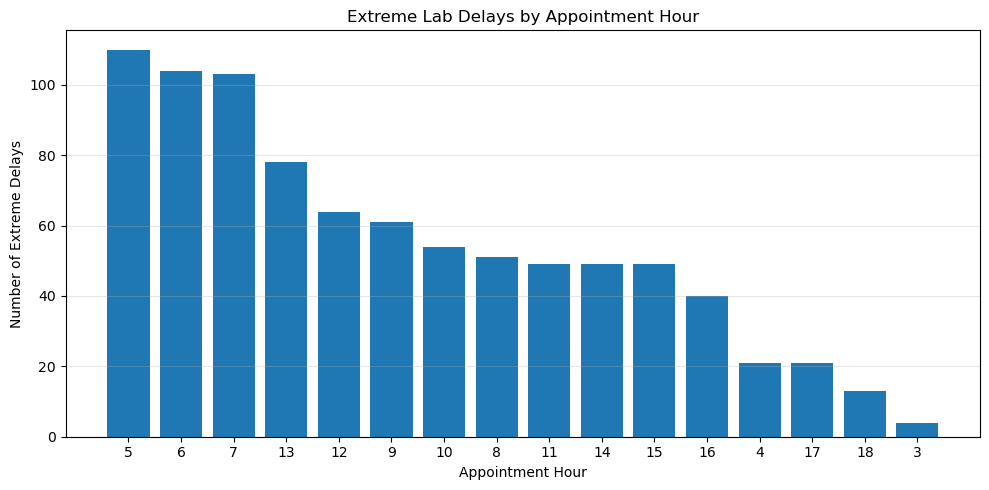

In [104]:
plt.figure(figsize=(10,5))

plt.bar(
    outlier_by_hour['appointment_hour'].astype(str),
    outlier_by_hour['Outlier_Records']
)

plt.title('Extreme Lab Delays by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Number of Extreme Delays')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
# Total Lab records by appointment hour
lab_total_by_hour = (
    df_clean[df_clean['lab_processing_minutes'].notna()]
    .groupby('appointment_hour')
    .size()
    .reset_index(name='Total_Lab_Records')
)

# Merge total records with extreme-delay counts
lab_delay_rate = outlier_by_hour.merge(
    lab_total_by_hour,
    on='appointment_hour',
    how='left'
)

# Calculate extreme delay percentage
lab_delay_rate['Extreme_Delay_Rate'] = (
    lab_delay_rate['Outlier_Records']
    / lab_delay_rate['Total_Lab_Records']
    * 100
).round(2)

# Sort by delay rate
lab_delay_rate = lab_delay_rate.sort_values(
    'Extreme_Delay_Rate',
    ascending=False
)

lab_delay_rate

,appointment_hour,Outlier_Records,Average_Outlier_Time,Maximum_Processing_Time,Total_Lab_Records,Extreme_Delay_Rate
14,18,13,705.15,1355.0,58,22.41
13,17,21,533.67,1046.0,101,20.79
11,16,40,718.30,1362.0,196,20.41
10,15,49,774.55,1405.0,399,12.28
7,8,51,691.20,1364.0,431,11.83
2,7,103,623.24,1435.0,1158,8.89
5,9,61,624.72,1267.0,810,7.53
0,5,110,670.48,1408.0,1544,7.12
6,10,54,745.31,1439.0,825,6.55
1,6,104,662.43,1430.0,1590,6.54


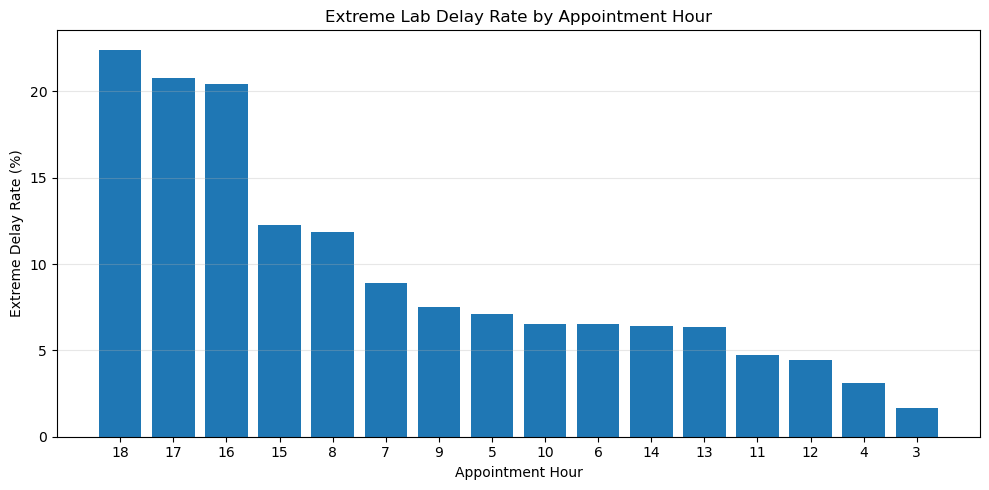

In [106]:
plt.figure(figsize=(10,5))

plt.bar(
    lab_delay_rate['appointment_hour'].astype(str),
    lab_delay_rate['Extreme_Delay_Rate']
)

plt.title('Extreme Lab Delay Rate by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [107]:
# Keep only appointment hours with a reasonable number of Lab records
reliable_lab_hours = lab_delay_rate[
    lab_delay_rate['Total_Lab_Records'] >= 50
].copy()

reliable_lab_hours = reliable_lab_hours.sort_values(
    'Extreme_Delay_Rate',
    ascending=False
)

reliable_lab_hours


,appointment_hour,Outlier_Records,Average_Outlier_Time,Maximum_Processing_Time,Total_Lab_Records,Extreme_Delay_Rate
14,18,13,705.15,1355.0,58,22.41
13,17,21,533.67,1046.0,101,20.79
11,16,40,718.30,1362.0,196,20.41
10,15,49,774.55,1405.0,399,12.28
7,8,51,691.20,1364.0,431,11.83
2,7,103,623.24,1435.0,1158,8.89
5,9,61,624.72,1267.0,810,7.53
0,5,110,670.48,1408.0,1544,7.12
6,10,54,745.31,1439.0,825,6.55
1,6,104,662.43,1430.0,1590,6.54


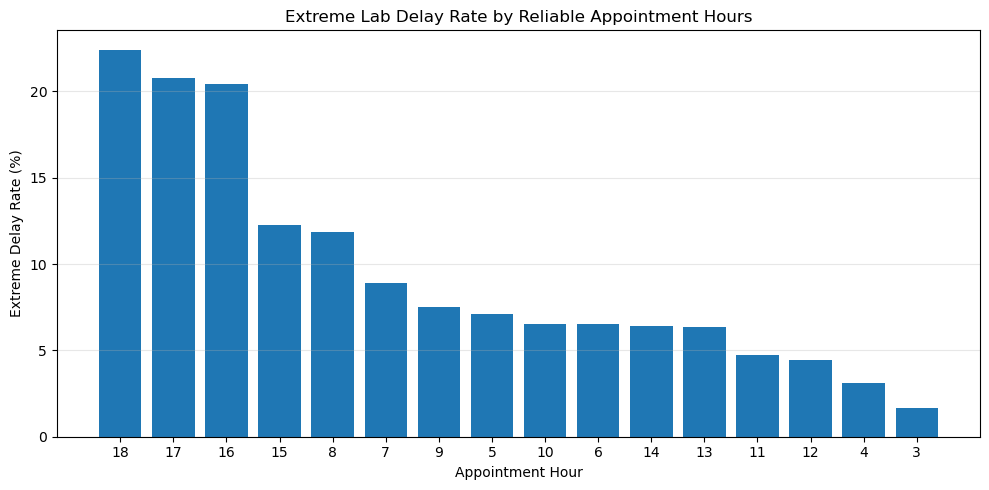

In [108]:
plt.figure(figsize=(10,5))

plt.bar(
    reliable_lab_hours['appointment_hour'].astype(str),
    reliable_lab_hours['Extreme_Delay_Rate']
)

plt.title('Extreme Lab Delay Rate by Reliable Appointment Hours')
plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [109]:
# Lab processing time by patient flow
lab_flow_analysis = (
    df_clean[df_clean['lab_processing_minutes'].notna()]
    .groupby('flow_name')
    .agg(
        Lab_Records=('lab_processing_minutes', 'count'),
        Average_Lab_Time=('lab_processing_minutes', 'mean'),
        Median_Lab_Time=('lab_processing_minutes', 'median')
    )
    .reset_index()
)

lab_flow_analysis['Average_Lab_Time'] = (
    lab_flow_analysis['Average_Lab_Time'].round(2)
)

lab_flow_analysis['Median_Lab_Time'] = (
    lab_flow_analysis['Median_Lab_Time'].round(2)
)

lab_flow_analysis = lab_flow_analysis.sort_values(
    'Average_Lab_Time',
    ascending=False
)

lab_flow_analysis

,flow_name,Lab_Records,Average_Lab_Time,Median_Lab_Time
2,Appointment â†’ Prescription â†’ Lab + Pharmacy,9,175.78,94.0
0,Appointment â†’ Prescription â†’ Lab,11448,170.81,121.0
1,Appointment â†’ Prescription â†’ Lab + Imaging,1080,129.89,99.0


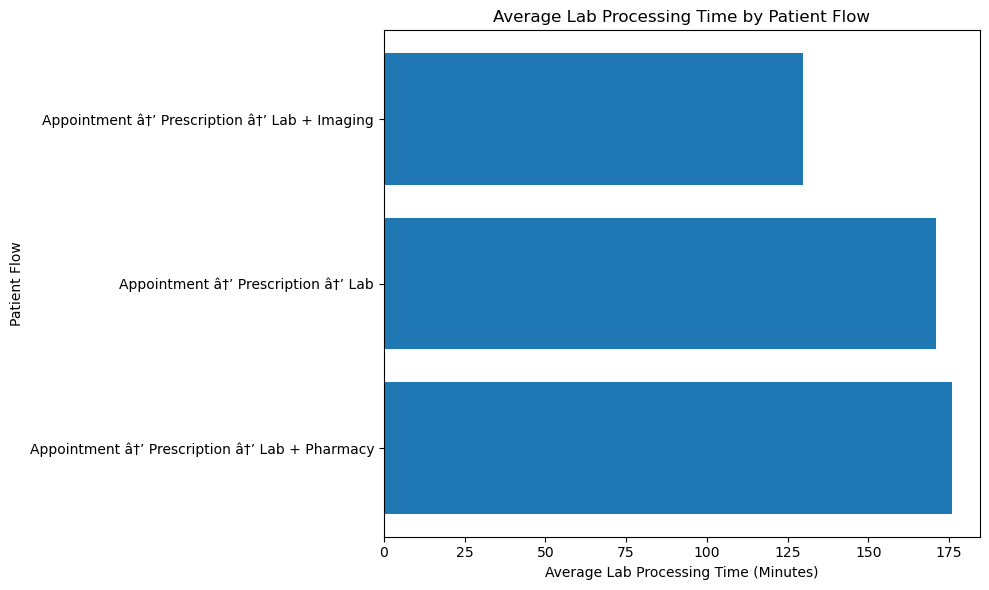

In [110]:
plt.figure(figsize=(10, 6))

plt.barh(
    lab_flow_analysis['flow_name'],
    lab_flow_analysis['Average_Lab_Time']
)

plt.title('Average Lab Processing Time by Patient Flow')
plt.xlabel('Average Lab Processing Time (Minutes)')
plt.ylabel('Patient Flow')

plt.tight_layout()
plt.show()

In [111]:
lab_flow_analysis['Total_Processing_Minutes'] = (
    lab_flow_analysis['Lab_Records']
    * lab_flow_analysis['Average_Lab_Time']
)

lab_flow_analysis['Total_Processing_Hours'] = (
    lab_flow_analysis['Total_Processing_Minutes'] / 60
).round(2)

lab_flow_analysis = lab_flow_analysis.sort_values(
    'Total_Processing_Minutes',
    ascending=False
)

lab_flow_analysis

,flow_name,Lab_Records,Average_Lab_Time,Median_Lab_Time,Total_Processing_Minutes,Total_Processing_Hours
0,Appointment â†’ Prescription â†’ Lab,11448,170.81,121.0,1955432.88,32590.55
1,Appointment â†’ Prescription â†’ Lab + Imaging,1080,129.89,99.0,140281.20,2338.02
2,Appointment â†’ Prescription â†’ Lab + Pharmacy,9,175.78,94.0,1582.02,26.37


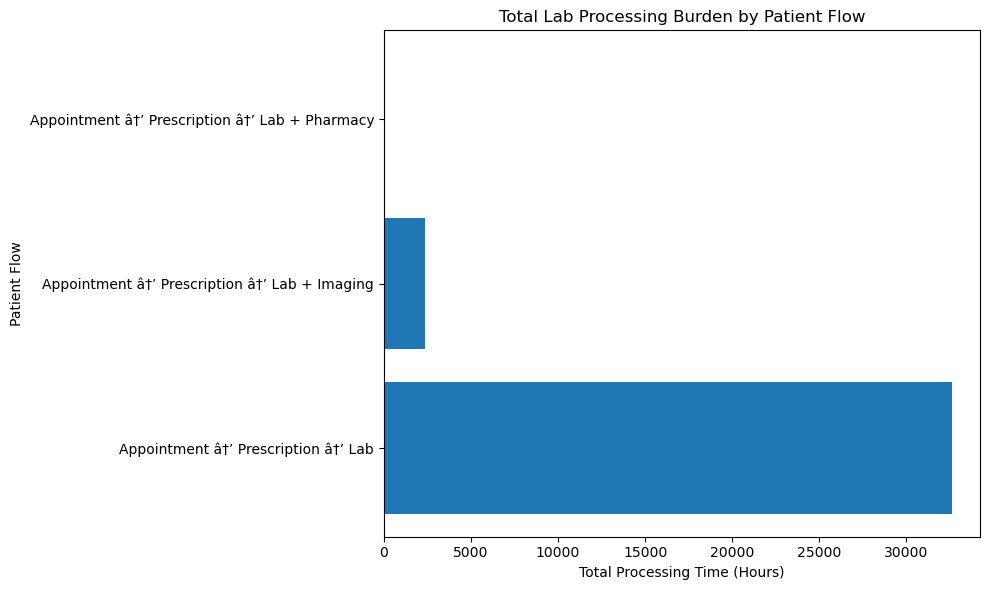

In [112]:
plt.figure(figsize=(10, 6))

plt.barh(
    lab_flow_analysis['flow_name'],
    lab_flow_analysis['Total_Processing_Hours']
)

plt.title('Total Lab Processing Burden by Patient Flow')
plt.xlabel('Total Processing Time (Hours)')
plt.ylabel('Patient Flow')

plt.tight_layout()
plt.show()

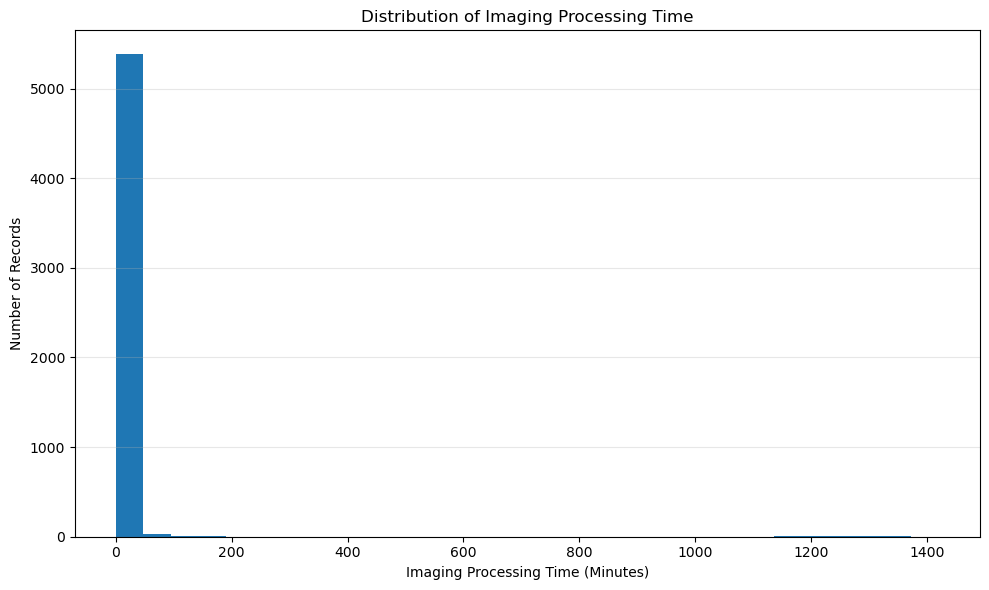

In [113]:
# Imaging processing time distribution

imaging_data = df_clean[
    df_clean['imaging_processing_minutes'].notna()
]

plt.figure(figsize=(10, 6))

plt.hist(
    imaging_data['imaging_processing_minutes'],
    bins=30
)

plt.title('Distribution of Imaging Processing Time')
plt.xlabel('Imaging Processing Time (Minutes)')
plt.ylabel('Number of Records')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

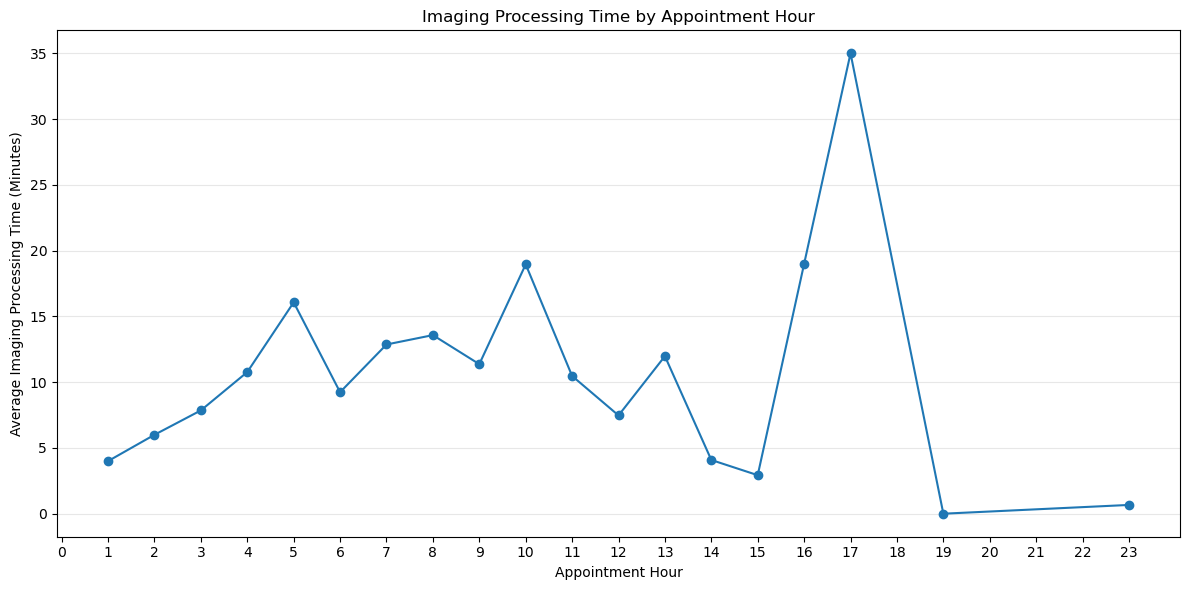

In [114]:
# Imaging Processing Time by Appointment Hour

imaging_hour_analysis = (
    df_clean[df_clean['imaging_processing_minutes'].notna()]
    .groupby('appointment_hour')
    .agg(
        Average_Imaging_Time=('imaging_processing_minutes', 'mean'),
        Imaging_Records=('imaging_processing_minutes', 'count')
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    imaging_hour_analysis['appointment_hour'],
    imaging_hour_analysis['Average_Imaging_Time'],
    marker='o'
)

plt.title('Imaging Processing Time by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Average Imaging Processing Time (Minutes)')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

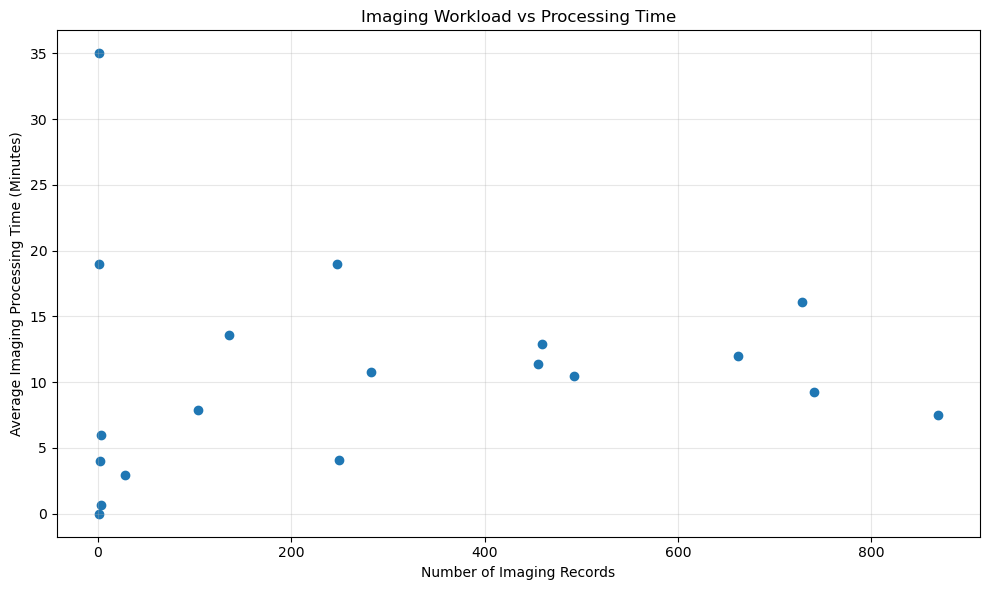

In [115]:
# Imaging Workload vs Processing Time

imaging_hour_analysis = (
    df_clean[df_clean['imaging_processing_minutes'].notna()]
    .groupby('appointment_hour')
    .agg(
        Average_Imaging_Time=('imaging_processing_minutes', 'mean'),
        Imaging_Records=('imaging_processing_minutes', 'count')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    imaging_hour_analysis['Imaging_Records'],
    imaging_hour_analysis['Average_Imaging_Time']
)

plt.xlabel('Number of Imaging Records')
plt.ylabel('Average Imaging Processing Time (Minutes)')
plt.title('Imaging Workload vs Processing Time')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [116]:
imaging_correlation = imaging_hour_analysis[
    ['Imaging_Records', 'Average_Imaging_Time']
].corr().iloc[0, 1]

print(
    "Correlation between Imaging workload and processing time:",
    round(imaging_correlation, 2)
)

Correlation between Imaging workload and processing time: 0.06


Q1: 1.0
Q3: 5.0
IQR: 4.0
Upper Outlier Boundary: 11.0
Number of Imaging Outliers: 353


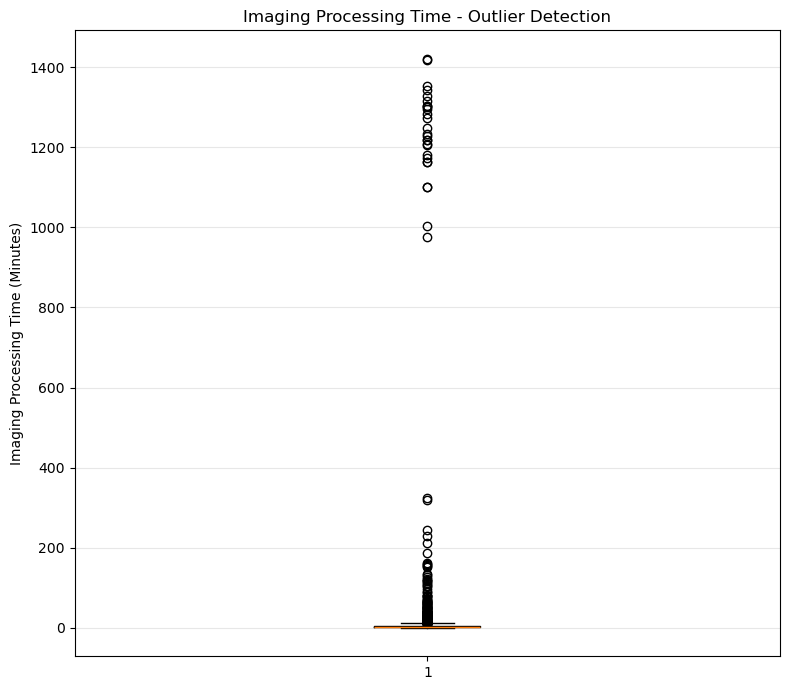

In [117]:
# Imaging Processing Time - Outlier Detection

imaging_data = df_clean[
    df_clean['imaging_processing_minutes'].notna()
]['imaging_processing_minutes']

Q1 = imaging_data.quantile(0.25)
Q3 = imaging_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

imaging_outliers = imaging_data[
    (imaging_data < lower_bound) |
    (imaging_data > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Upper Outlier Boundary:", round(upper_bound, 2))
print("Number of Imaging Outliers:", len(imaging_outliers))

plt.figure(figsize=(8, 7))

plt.boxplot(imaging_data)

plt.ylabel('Imaging Processing Time (Minutes)')
plt.title('Imaging Processing Time - Outlier Detection')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

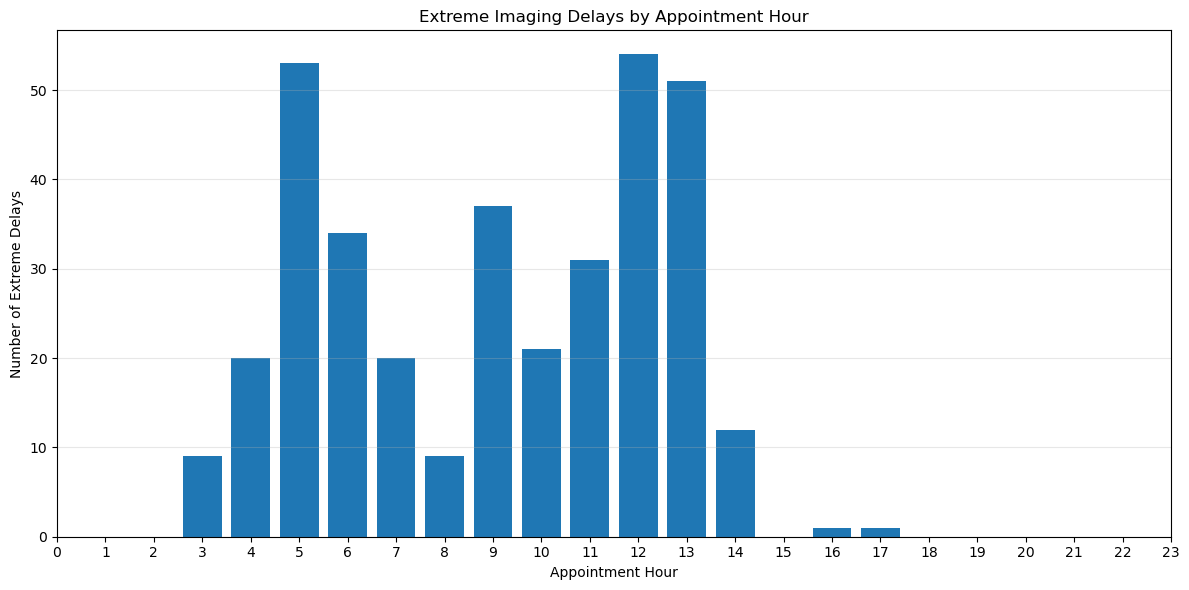

In [118]:
# Extreme Imaging Delays by Appointment Hour

imaging_extreme = df_clean[
    (df_clean['imaging_processing_minutes'].notna()) &
    (df_clean['imaging_processing_minutes'] > upper_bound)
]

imaging_extreme_by_hour = (
    imaging_extreme
    .groupby('appointment_hour')
    .size()
    .reset_index(name='Extreme_Delays')
    .sort_values('Extreme_Delays', ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    imaging_extreme_by_hour['appointment_hour'],
    imaging_extreme_by_hour['Extreme_Delays']
)

plt.title('Extreme Imaging Delays by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Number of Extreme Delays')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

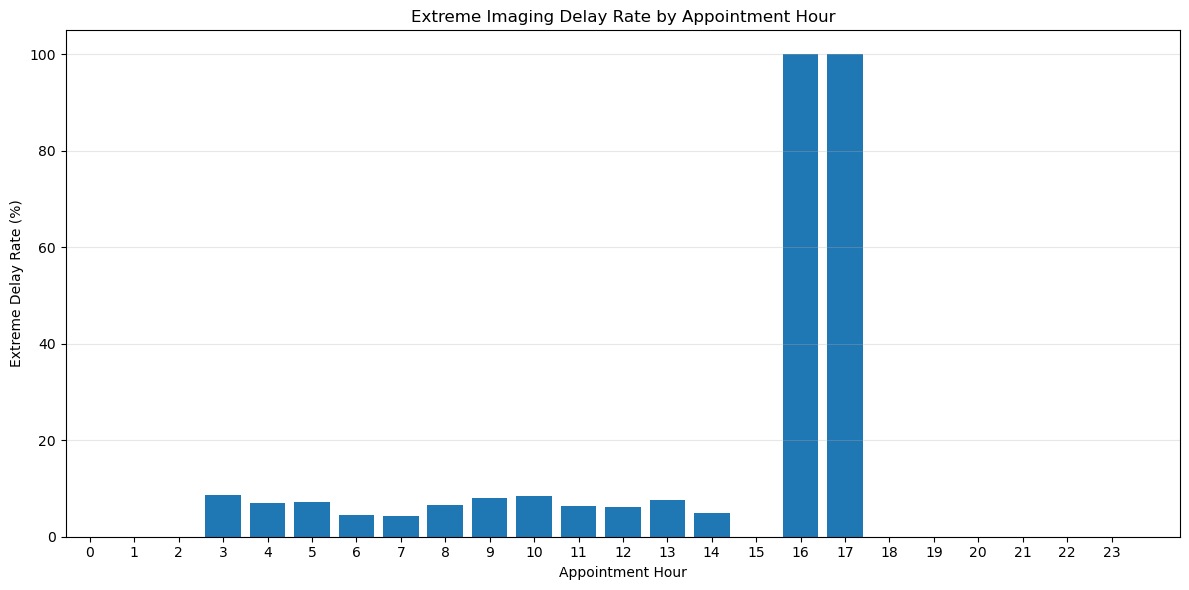

In [119]:
# Extreme Imaging Delay Rate by Appointment Hour

imaging_hour_analysis['Extreme_Delays'] = (
    imaging_hour_analysis['appointment_hour']
    .map(
        imaging_extreme_by_hour.set_index('appointment_hour')['Extreme_Delays']
    )
    .fillna(0)
)

imaging_hour_analysis['Extreme_Delay_Rate'] = (
    imaging_hour_analysis['Extreme_Delays']
    / imaging_hour_analysis['Imaging_Records']
    * 100
)

imaging_delay_rate = (
    imaging_hour_analysis
    .sort_values('Extreme_Delay_Rate', ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    imaging_delay_rate['appointment_hour'],
    imaging_delay_rate['Extreme_Delay_Rate']
)

plt.title('Extreme Imaging Delay Rate by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

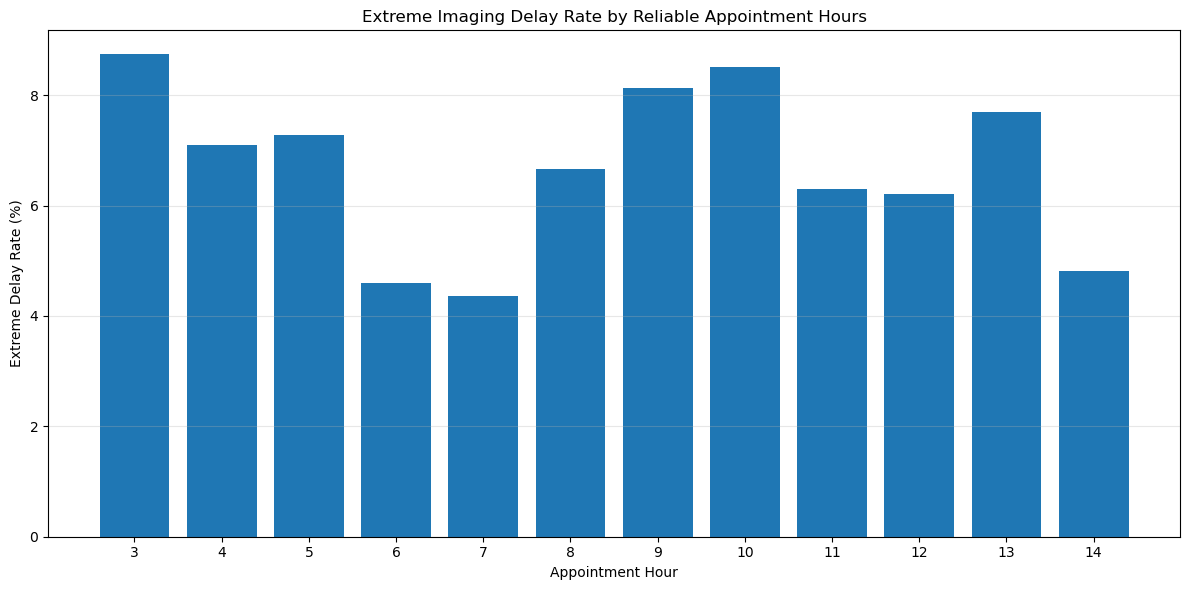

In [120]:
# Reliable Imaging Hours
# Only consider hours with at least 100 imaging records

reliable_imaging = imaging_hour_analysis[
    imaging_hour_analysis['Imaging_Records'] >= 100
].copy()

reliable_imaging = reliable_imaging.sort_values(
    'Extreme_Delay_Rate',
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    reliable_imaging['appointment_hour'],
    reliable_imaging['Extreme_Delay_Rate']
)

plt.title('Extreme Imaging Delay Rate by Reliable Appointment Hours')
plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')

plt.xticks(reliable_imaging['appointment_hour'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [121]:
print(df_clean.columns.tolist())

['record_no', 'patient_id', 'appointment_id', 'appointment_start_datetime', 'prescription_doctor_id', 'prescription_doctor_name', 'prescription_order_id', 'prescription_start_datetime', 'prescription_end_datetime', 'lab_id', 'lab_name', 'lab_start_datetime', 'lab_end_datetime', 'imaging_request_id', 'imaging_result_id', 'imaging_name', 'imaging_start_datetime', 'imaging_end_datetime', 'pharmacy_sale_line_id', 'medicine_name', 'pharmacy_start_datetime', 'pharmacy_end_datetime', 'flow_code', 'flow_name', 'prescription_processing_minutes', 'lab_processing_minutes', 'imaging_processing_minutes', 'pharmacy_processing_minutes', 'appointment_to_prescription_minutes', 'appointment_hour', 'appointment_month', 'appointment_day']


In [122]:
# Imaging Processing Time by Patient Flow

imaging_flow = df_clean[
    df_clean['imaging_processing_minutes'].notna()
].groupby('flow_name').agg(
    Average_Imaging_Time=('imaging_processing_minutes', 'mean'),
    Imaging_Records=('imaging_processing_minutes', 'count')
).reset_index()

imaging_flow['Average_Imaging_Time'] = (
    imaging_flow['Average_Imaging_Time'].round(2)
)

imaging_flow = imaging_flow.sort_values(
    'Average_Imaging_Time',
    ascending=False
)

imaging_flow

,flow_name,Average_Imaging_Time,Imaging_Records
2,Appointment â†’ Prescription â†’ Lab + Imaging,12.88,1551
0,Appointment â†’ Prescription â†’ Imaging,10.43,3909
1,Appointment â†’ Prescription â†’ Imaging + Pha...,2.00,1


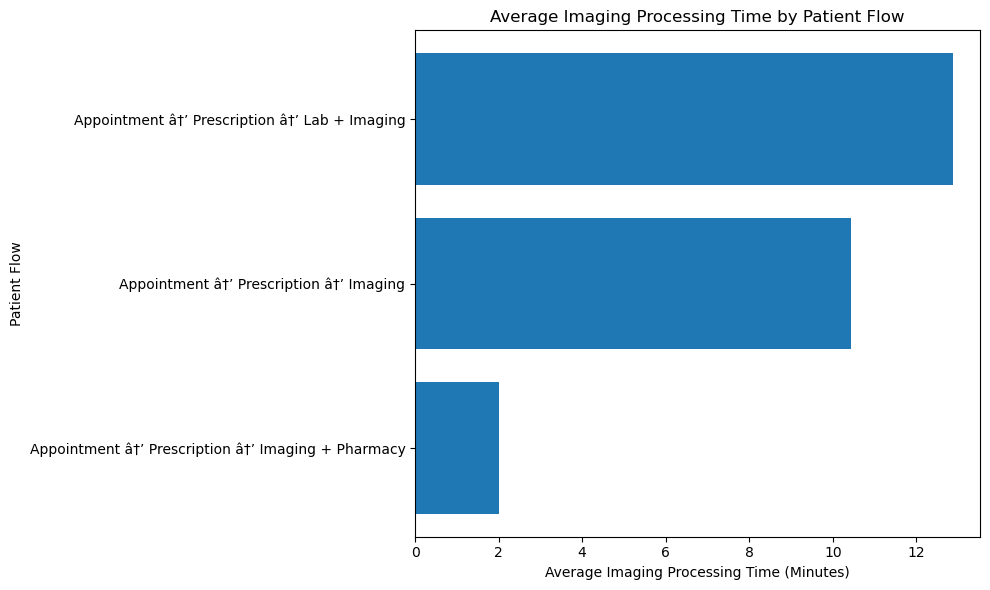

In [123]:
plt.figure(figsize=(10, 6))

plt.barh(
    imaging_flow['flow_name'],
    imaging_flow['Average_Imaging_Time']
)

plt.xlabel('Average Imaging Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Average Imaging Processing Time by Patient Flow')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [124]:
# Total Imaging Processing Burden by Patient Flow

imaging_burden = df_clean[
    df_clean['imaging_processing_minutes'].notna()
].groupby('flow_name').agg(
    Total_Imaging_Time=('imaging_processing_minutes', 'sum'),
    Imaging_Records=('imaging_processing_minutes', 'count')
).reset_index()

# Convert total minutes to hours
imaging_burden['Total_Imaging_Hours'] = (
    imaging_burden['Total_Imaging_Time'] / 60
).round(2)

imaging_burden = imaging_burden.sort_values(
    'Total_Imaging_Hours',
    ascending=False
)

imaging_burden

,flow_name,Total_Imaging_Time,Imaging_Records,Total_Imaging_Hours
0,Appointment â†’ Prescription â†’ Imaging,40755.0,3909,679.25
2,Appointment â†’ Prescription â†’ Lab + Imaging,19982.0,1551,333.03
1,Appointment â†’ Prescription â†’ Imaging + Pha...,2.0,1,0.03


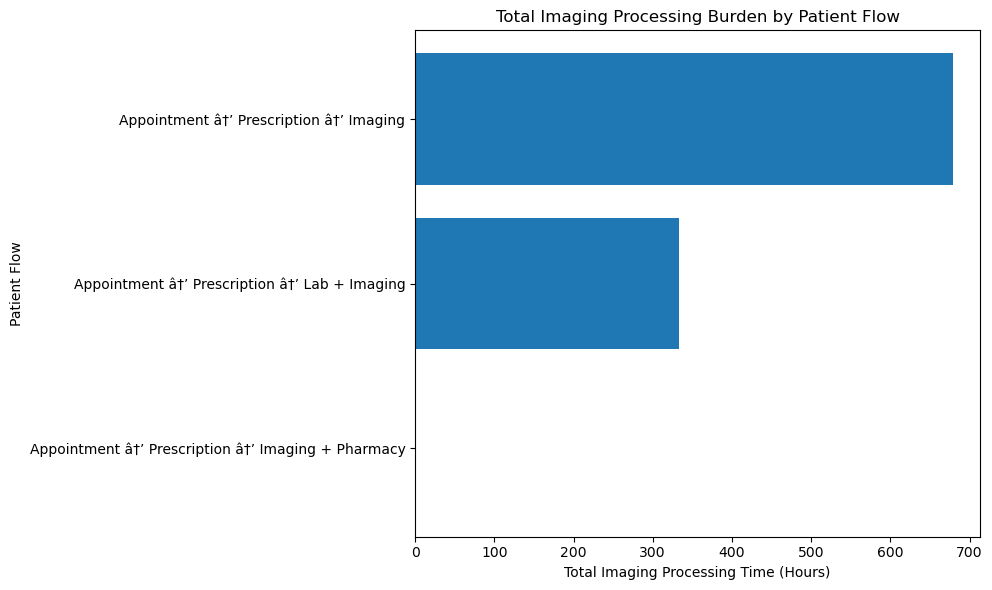

In [125]:
plt.figure(figsize=(10, 6))

plt.barh(
    imaging_burden['flow_name'],
    imaging_burden['Total_Imaging_Hours']
)

plt.xlabel('Total Imaging Processing Time (Hours)')
plt.ylabel('Patient Flow')
plt.title('Total Imaging Processing Burden by Patient Flow')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

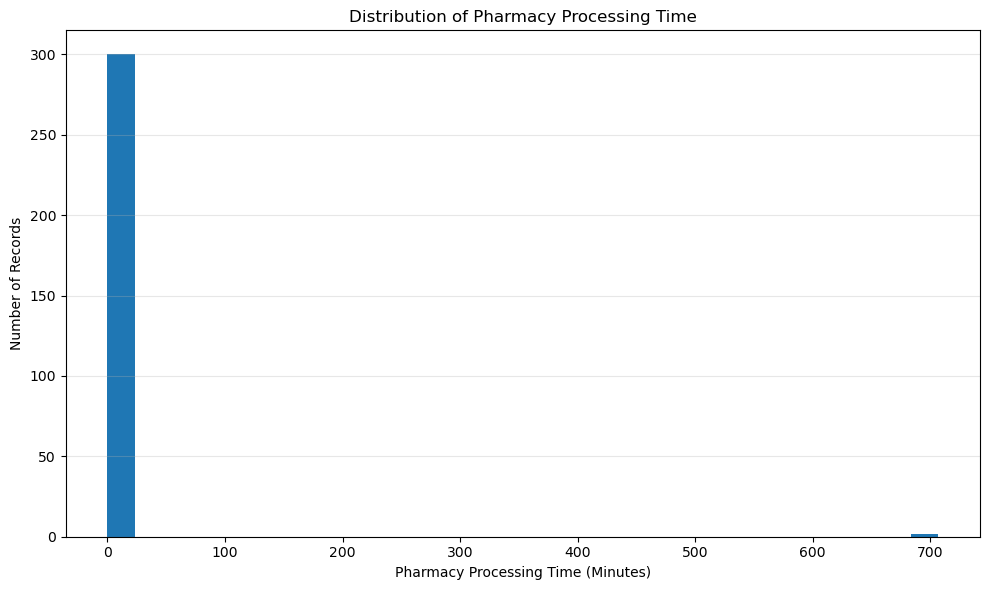

In [126]:
# Distribution of Pharmacy Processing Time

plt.figure(figsize=(10, 6))

plt.hist(
    df_clean['pharmacy_processing_minutes'].dropna(),
    bins=30
)

plt.xlabel('Pharmacy Processing Time (Minutes)')
plt.ylabel('Number of Records')
plt.title('Distribution of Pharmacy Processing Time')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [127]:
# Pharmacy Processing Time - Outlier Detection

pharmacy_time = df_clean[
    df_clean['pharmacy_processing_minutes'].notna()
]['pharmacy_processing_minutes']

Q1 = pharmacy_time.quantile(0.25)
Q3 = pharmacy_time.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

pharmacy_outliers = pharmacy_time[
    (pharmacy_time < lower_bound) |
    (pharmacy_time > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Upper Outlier Boundary:", round(upper_bound, 2))
print("Number of Pharmacy Outliers:", len(pharmacy_outliers))

Q1: 0.0
Q3: 1.0
IQR: 1.0
Upper Outlier Boundary: 2.5
Number of Pharmacy Outliers: 8


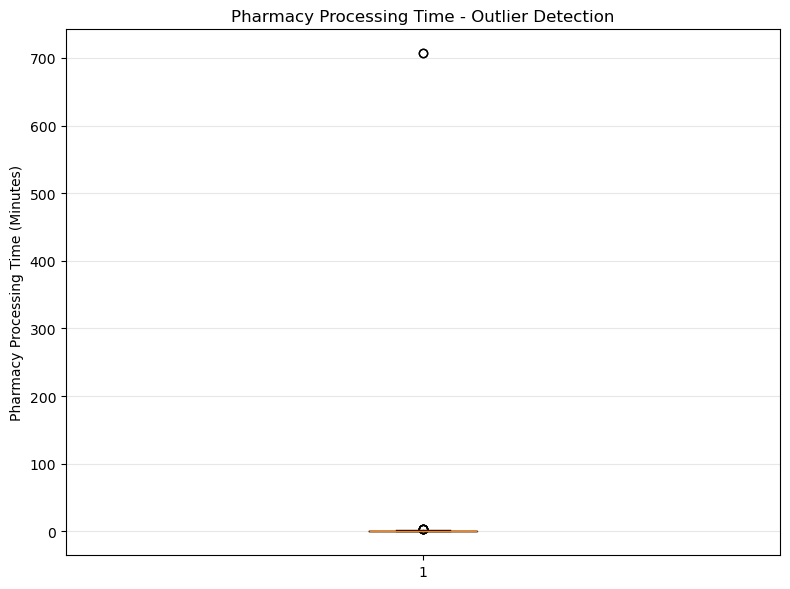

In [128]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    pharmacy_time,
    vert=True
)

plt.ylabel('Pharmacy Processing Time (Minutes)')
plt.title('Pharmacy Processing Time - Outlier Detection')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:
# Pharmacy Processing Time by Appointment Hour

pharmacy_hour_analysis = df_clean[
    df_clean['pharmacy_processing_minutes'].notna()
].groupby('appointment_hour').agg(
    Average_Pharmacy_Time=('pharmacy_processing_minutes', 'mean'),
    Pharmacy_Records=('pharmacy_processing_minutes', 'count')
).reset_index()

pharmacy_hour_analysis['Average_Pharmacy_Time'] = (
    pharmacy_hour_analysis['Average_Pharmacy_Time'].round(2)
)

pharmacy_hour_analysis

,appointment_hour,Average_Pharmacy_Time,Pharmacy_Records
0,3,1.00,4
1,4,1.16,19
2,5,0.00,1
3,6,46.00,31
4,7,0.68,22
5,8,0.27,11
6,9,0.73,11
7,10,0.33,15
8,11,0.55,11
9,12,0.58,53


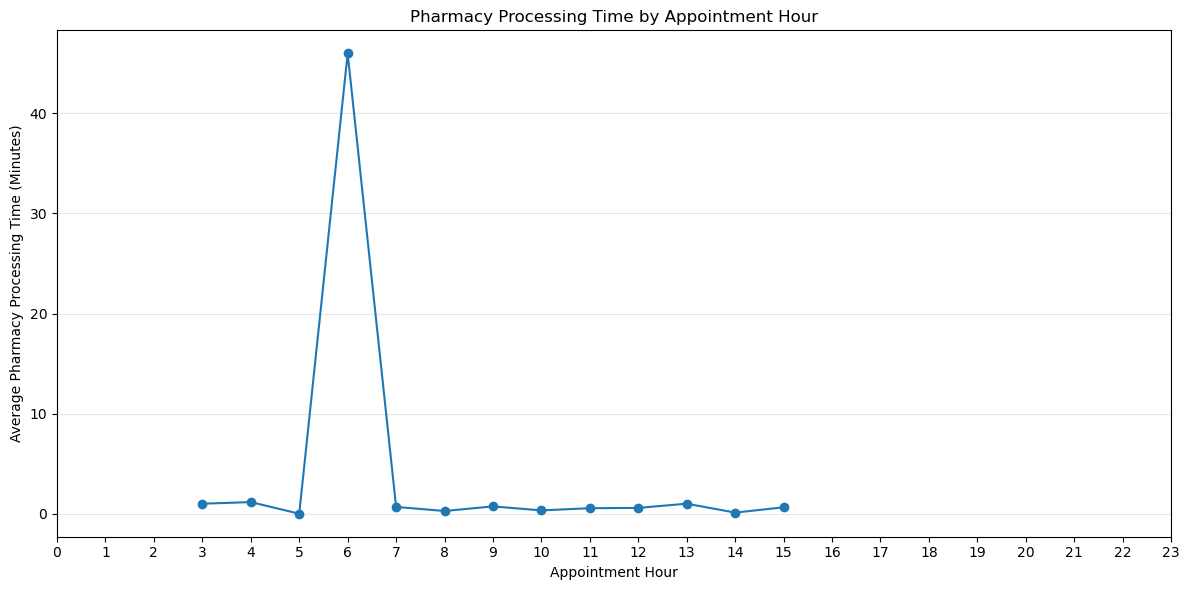

In [130]:
plt.figure(figsize=(12, 6))

plt.plot(
    pharmacy_hour_analysis['appointment_hour'],
    pharmacy_hour_analysis['Average_Pharmacy_Time'],
    marker='o'
)

plt.xlabel('Appointment Hour')
plt.ylabel('Average Pharmacy Processing Time (Minutes)')
plt.title('Pharmacy Processing Time by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

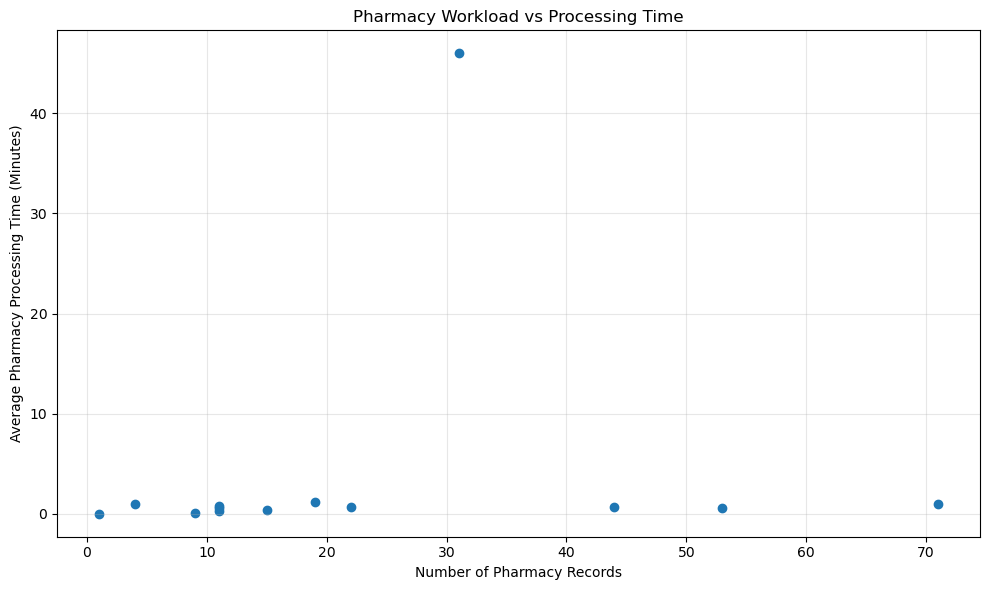

In [131]:
# Pharmacy Workload vs Processing Time

pharmacy_workload = df_clean[
    df_clean['pharmacy_processing_minutes'].notna()
].groupby('appointment_hour').agg(
    Pharmacy_Records=('pharmacy_processing_minutes', 'count'),
    Average_Pharmacy_Time=('pharmacy_processing_minutes', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))

plt.scatter(
    pharmacy_workload['Pharmacy_Records'],
    pharmacy_workload['Average_Pharmacy_Time']
)

plt.xlabel('Number of Pharmacy Records')
plt.ylabel('Average Pharmacy Processing Time (Minutes)')
plt.title('Pharmacy Workload vs Processing Time')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [132]:
pharmacy_correlation = pharmacy_workload[
    ['Pharmacy_Records', 'Average_Pharmacy_Time']
].corr().iloc[0, 1]

print(
    "Correlation between Pharmacy workload and processing time:",
    round(pharmacy_correlation, 2)
)

Correlation between Pharmacy workload and processing time: 0.12


In [133]:
# Extreme Pharmacy Delays by Appointment Hour

pharmacy_data = df_clean[
    df_clean['pharmacy_processing_minutes'].notna()
].copy()

Q1 = pharmacy_data['pharmacy_processing_minutes'].quantile(0.25)
Q3 = pharmacy_data['pharmacy_processing_minutes'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

pharmacy_data['Extreme_Delay'] = (
    pharmacy_data['pharmacy_processing_minutes'] > upper_bound
)

pharmacy_extreme = pharmacy_data[
    pharmacy_data['Extreme_Delay']
].groupby('appointment_hour').size().reset_index(
    name='Extreme_Delays'
)

pharmacy_extreme = pharmacy_extreme.sort_values(
    'Extreme_Delays',
    ascending=False
)

print("Upper Outlier Boundary:", round(upper_bound, 2))
print("Total Extreme Pharmacy Delays:", len(
    pharmacy_data[pharmacy_data['Extreme_Delay']]
))

pharmacy_extreme

Upper Outlier Boundary: 2.5
Total Extreme Pharmacy Delays: 8


,appointment_hour,Extreme_Delays
3,13,3
0,4,2
1,6,2
2,11,1


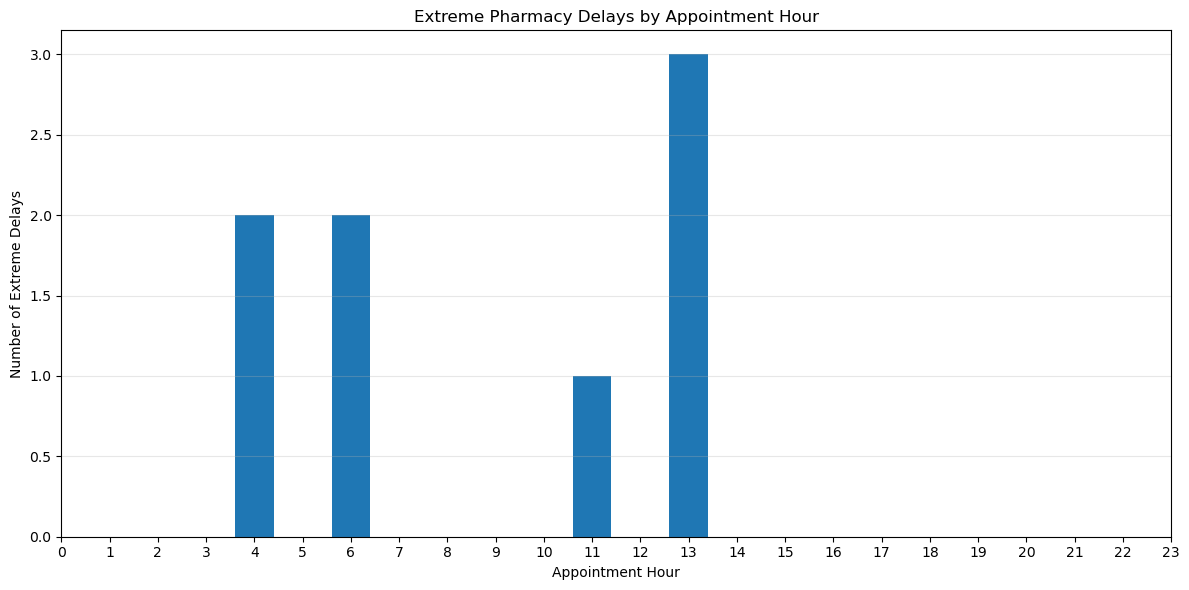

In [134]:
plt.figure(figsize=(12, 6))

plt.bar(
    pharmacy_extreme['appointment_hour'],
    pharmacy_extreme['Extreme_Delays']
)

plt.xlabel('Appointment Hour')
plt.ylabel('Number of Extreme Delays')
plt.title('Extreme Pharmacy Delays by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [135]:
# Extreme Pharmacy Delay Rate by Appointment Hour

pharmacy_data = df_clean[
    df_clean['pharmacy_processing_minutes'].notna()
].copy()

Q1 = pharmacy_data['pharmacy_processing_minutes'].quantile(0.25)
Q3 = pharmacy_data['pharmacy_processing_minutes'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

pharmacy_data['Extreme_Delay'] = (
    pharmacy_data['pharmacy_processing_minutes'] > upper_bound
)

pharmacy_delay_rate = pharmacy_data.groupby('appointment_hour').agg(
    Total_Records=('pharmacy_processing_minutes', 'count'),
    Extreme_Delays=('Extreme_Delay', 'sum')
).reset_index()

pharmacy_delay_rate['Extreme_Delay_Rate'] = (
    pharmacy_delay_rate['Extreme_Delays'] /
    pharmacy_delay_rate['Total_Records'] * 100
).round(2)

pharmacy_delay_rate = pharmacy_delay_rate.sort_values(
    'Extreme_Delay_Rate',
    ascending=False
)

pharmacy_delay_rate

,appointment_hour,Total_Records,Extreme_Delays,Extreme_Delay_Rate
1,4,19,2,10.53
8,11,11,1,9.09
3,6,31,2,6.45
10,13,71,3,4.23
0,3,4,0,0.00
2,5,1,0,0.00
4,7,22,0,0.00
5,8,11,0,0.00
6,9,11,0,0.00
7,10,15,0,0.00


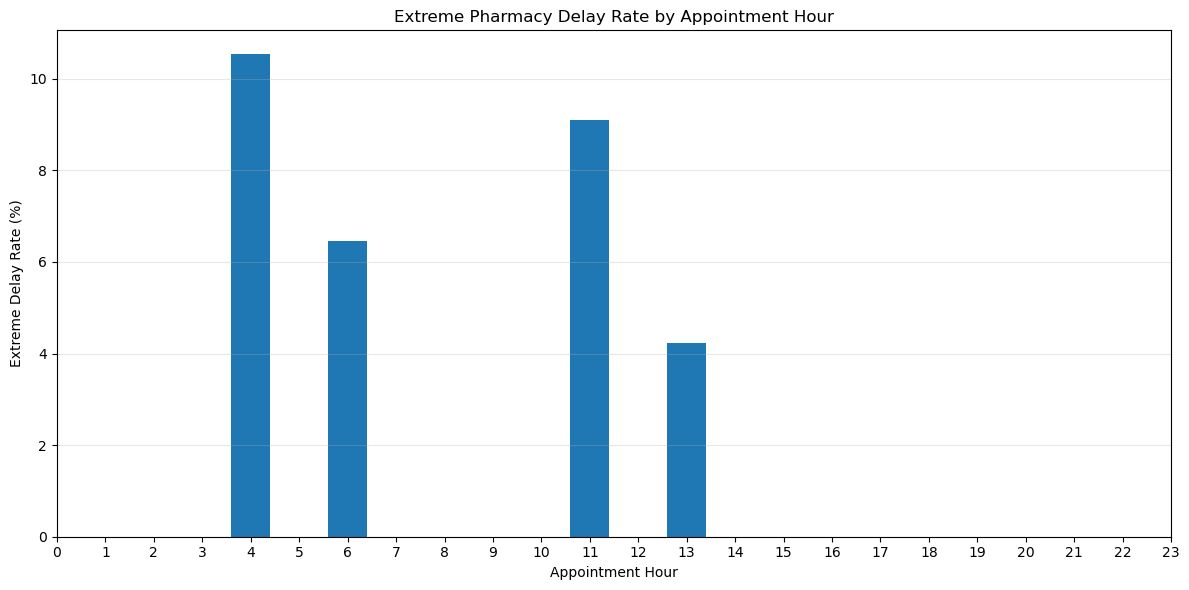

In [136]:
plt.figure(figsize=(12, 6))

plt.bar(
    pharmacy_delay_rate['appointment_hour'],
    pharmacy_delay_rate['Extreme_Delay_Rate']
)

plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')
plt.title('Extreme Pharmacy Delay Rate by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [137]:
# Pharmacy Processing Time by Patient Flow

pharmacy_flow = df_clean[
    df_clean['pharmacy_processing_minutes'].notna()
].groupby('flow_name').agg(
    Average_Pharmacy_Time=('pharmacy_processing_minutes', 'mean'),
    Pharmacy_Records=('pharmacy_processing_minutes', 'count')
).reset_index()

pharmacy_flow['Average_Pharmacy_Time'] = (
    pharmacy_flow['Average_Pharmacy_Time'].round(2)
)

pharmacy_flow = pharmacy_flow.sort_values(
    'Average_Pharmacy_Time',
    ascending=False
)

pharmacy_flow

,flow_name,Average_Pharmacy_Time,Pharmacy_Records
2,Appointment â†’ Prescription â†’ Pharmacy,5.71,281
0,Appointment â†’ Prescription â†’ Imaging + Pha...,1.00,1
1,Appointment â†’ Prescription â†’ Lab + Pharmacy,0.70,20


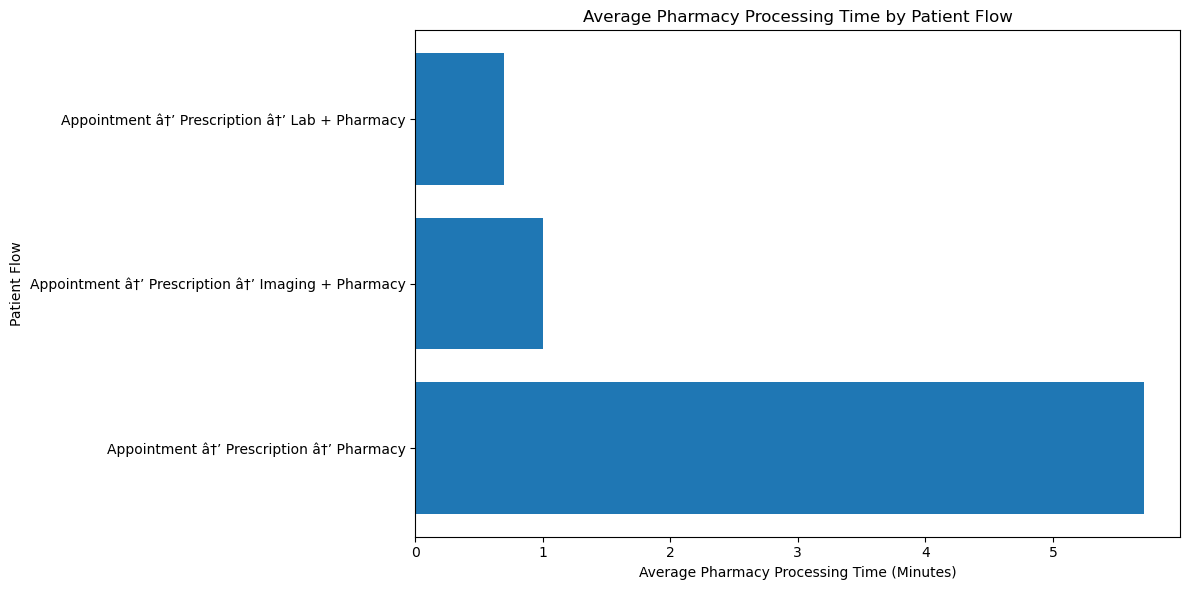

In [138]:
plt.figure(figsize=(12, 6))

plt.barh(
    pharmacy_flow['flow_name'],
    pharmacy_flow['Average_Pharmacy_Time']
)

plt.xlabel('Average Pharmacy Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Average Pharmacy Processing Time by Patient Flow')

plt.tight_layout()
plt.show()

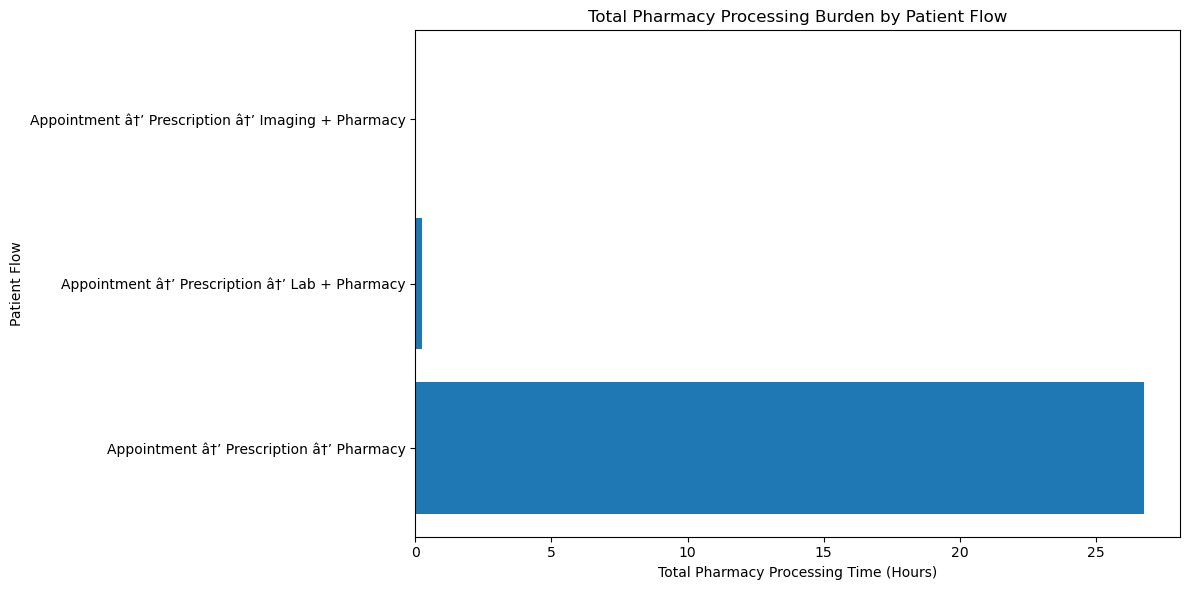

In [139]:
pharmacy_flow['Total_Pharmacy_Time_Hours'] = (
    pharmacy_flow['Average_Pharmacy_Time'] *
    pharmacy_flow['Pharmacy_Records'] / 60
)

pharmacy_flow = pharmacy_flow.sort_values(
    'Total_Pharmacy_Time_Hours',
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.barh(
    pharmacy_flow['flow_name'],
    pharmacy_flow['Total_Pharmacy_Time_Hours']
)

plt.xlabel('Total Pharmacy Processing Time (Hours)')
plt.ylabel('Patient Flow')
plt.title('Total Pharmacy Processing Burden by Patient Flow')

plt.tight_layout()
plt.show()

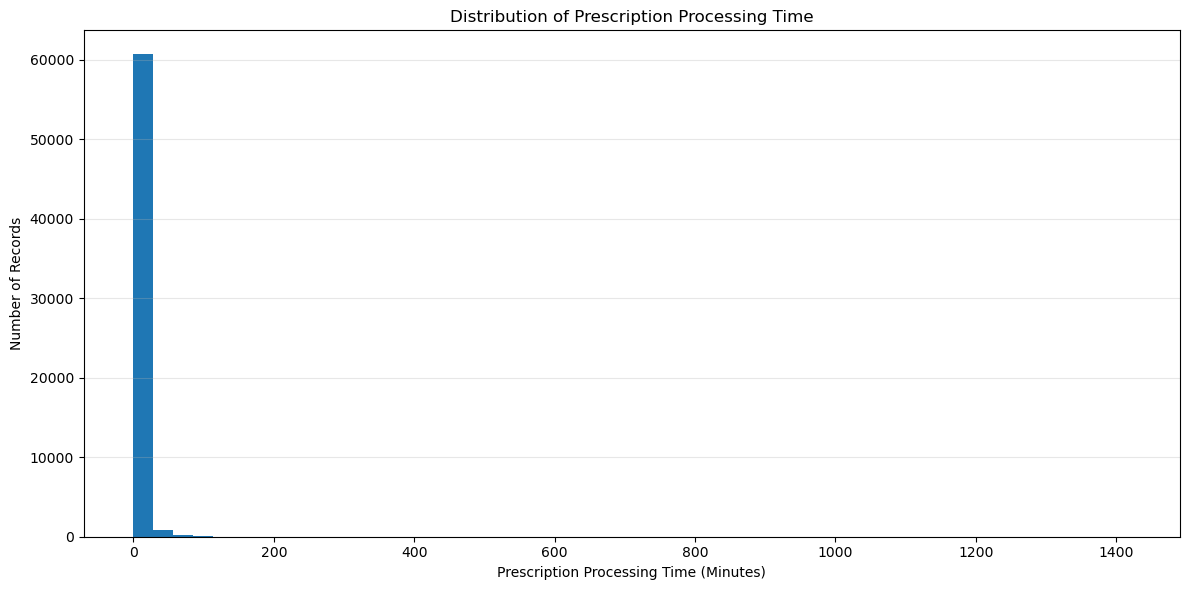

In [140]:
# Distribution of Prescription Processing Time

plt.figure(figsize=(12, 6))

plt.hist(
    df_clean['prescription_processing_minutes'].dropna(),
    bins=50
)

plt.xlabel('Prescription Processing Time (Minutes)')
plt.ylabel('Number of Records')
plt.title('Distribution of Prescription Processing Time')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

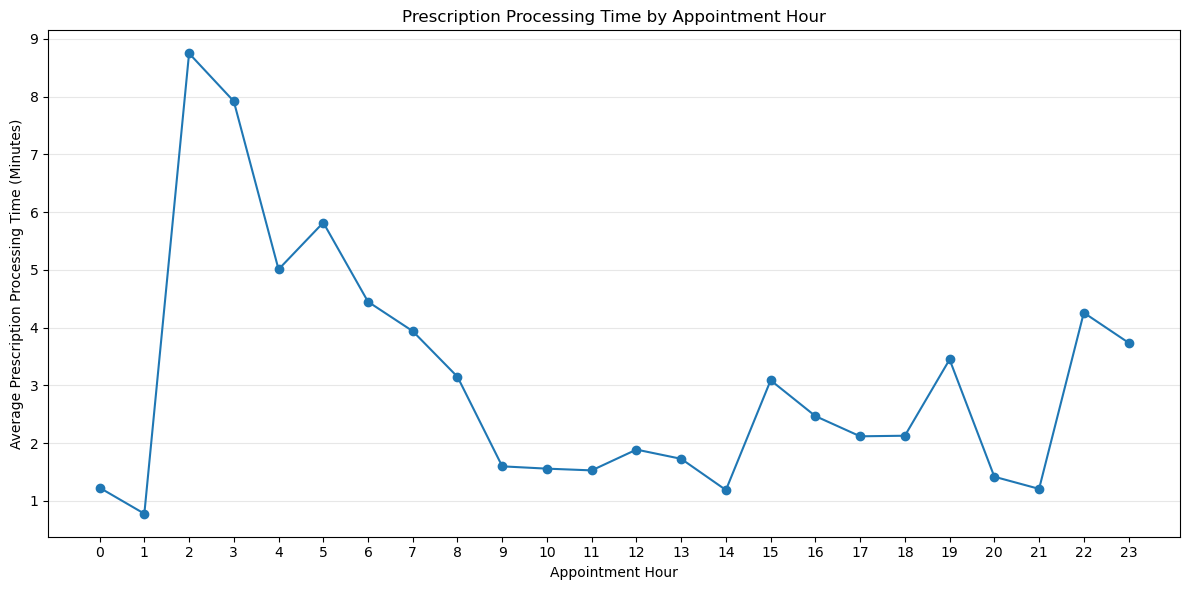

In [141]:
# Prescription Processing Time by Appointment Hour

prescription_hour = df_clean[
    df_clean['prescription_processing_minutes'].notna()
].groupby('appointment_hour').agg(
    Average_Prescription_Time=('prescription_processing_minutes', 'mean'),
    Prescription_Records=('prescription_processing_minutes', 'count')
).reset_index()

prescription_hour['Average_Prescription_Time'] = (
    prescription_hour['Average_Prescription_Time'].round(2)
)

plt.figure(figsize=(12, 6))

plt.plot(
    prescription_hour['appointment_hour'],
    prescription_hour['Average_Prescription_Time'],
    marker='o'
)

plt.xlabel('Appointment Hour')
plt.ylabel('Average Prescription Processing Time (Minutes)')
plt.title('Prescription Processing Time by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

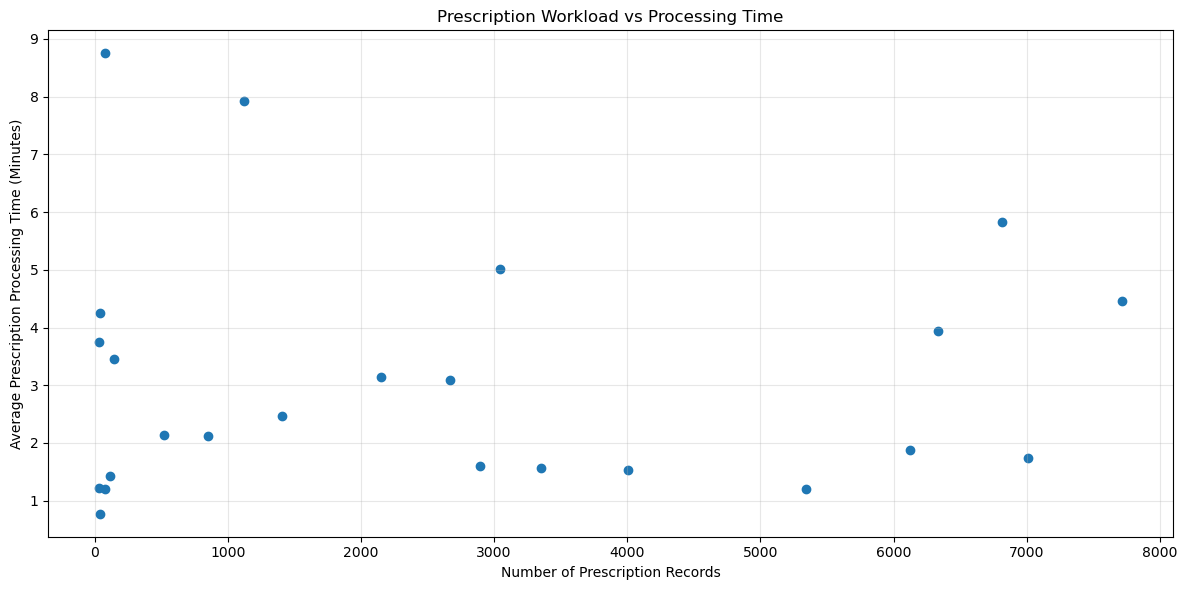

In [142]:
# Prescription Workload vs Processing Time

prescription_workload = df_clean[
    df_clean['prescription_processing_minutes'].notna()
].groupby('appointment_hour').agg(
    Prescription_Records=('prescription_processing_minutes', 'count'),
    Average_Prescription_Time=('prescription_processing_minutes', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))

plt.scatter(
    prescription_workload['Prescription_Records'],
    prescription_workload['Average_Prescription_Time']
)

plt.xlabel('Number of Prescription Records')
plt.ylabel('Average Prescription Processing Time (Minutes)')
plt.title('Prescription Workload vs Processing Time')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
prescription_correlation = prescription_workload[
    ['Prescription_Records', 'Average_Prescription_Time']
].corr().iloc[0, 1]

print(
    "Correlation between Prescription workload and processing time:",
    round(prescription_correlation, 2)
)

Correlation between Prescription workload and processing time: 0.0


Q1: 0.0
Q3: 2.0
IQR: 2.0
Upper Outlier Boundary: 5.0
Number of Prescription Outliers: 7613


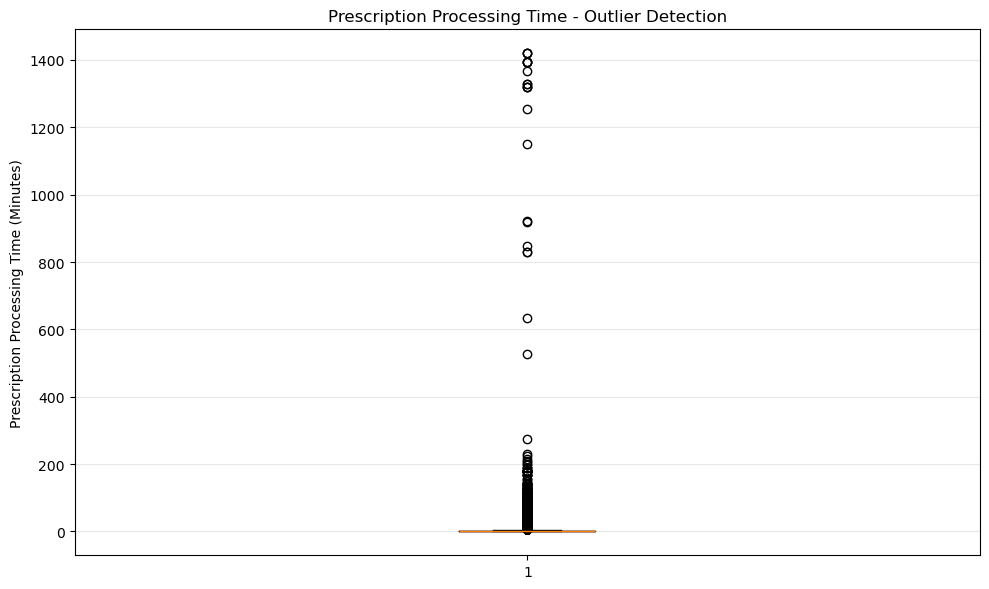

In [144]:
# Prescription Processing Time - Outlier Detection

prescription_data = df_clean[
    df_clean['prescription_processing_minutes'].notna()
].copy()

Q1 = prescription_data['prescription_processing_minutes'].quantile(0.25)
Q3 = prescription_data['prescription_processing_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

prescription_outliers = prescription_data[
    (prescription_data['prescription_processing_minutes'] < lower_bound) |
    (prescription_data['prescription_processing_minutes'] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Upper Outlier Boundary:", round(upper_bound, 2))
print("Number of Prescription Outliers:", len(prescription_outliers))

plt.figure(figsize=(10, 6))

plt.boxplot(
    prescription_data['prescription_processing_minutes'],
    vert=True
)

plt.ylabel('Prescription Processing Time (Minutes)')
plt.title('Prescription Processing Time - Outlier Detection')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

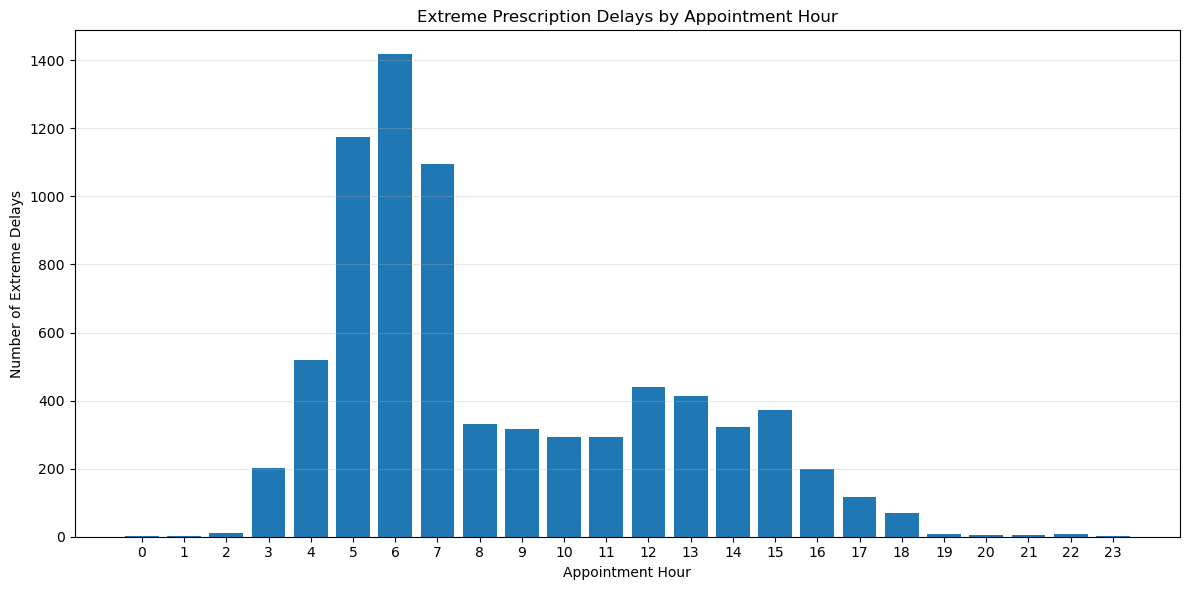

In [145]:
# Extreme Prescription Delays by Appointment Hour

prescription_data['extreme_delay'] = (
    prescription_data['prescription_processing_minutes'] > upper_bound
)

extreme_prescription_hour = (
    prescription_data
    .groupby('appointment_hour')['extreme_delay']
    .sum()
    .reset_index(name='Extreme_Delays')
)

plt.figure(figsize=(12, 6))

plt.bar(
    extreme_prescription_hour['appointment_hour'],
    extreme_prescription_hour['Extreme_Delays']
)

plt.xlabel('Appointment Hour')
plt.ylabel('Number of Extreme Delays')
plt.title('Extreme Prescription Delays by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

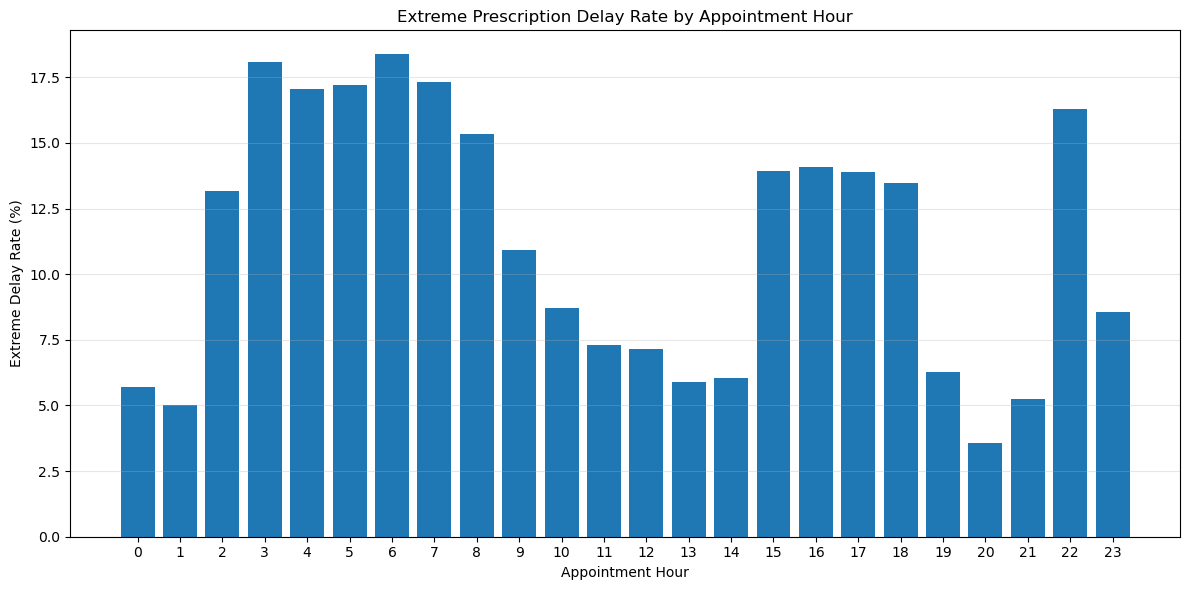

In [146]:
# Extreme Prescription Delay Rate by Appointment Hour

prescription_hour_rate = (
    prescription_data
    .groupby('appointment_hour')
    .agg(
        Total_Records=('extreme_delay', 'count'),
        Extreme_Delays=('extreme_delay', 'sum')
    )
    .reset_index()
)

prescription_hour_rate['Extreme_Delay_Rate'] = (
    prescription_hour_rate['Extreme_Delays'] /
    prescription_hour_rate['Total_Records'] * 100
)

prescription_hour_rate = prescription_hour_rate.sort_values(
    'Extreme_Delay_Rate',
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    prescription_hour_rate['appointment_hour'],
    prescription_hour_rate['Extreme_Delay_Rate']
)

plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')
plt.title('Extreme Prescription Delay Rate by Appointment Hour')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
# Reliable Prescription Hours

reliable_prescription = prescription_hour_rate[
    prescription_hour_rate['Total_Records'] >= 30
].copy()

reliable_prescription = reliable_prescription.sort_values(
    'Extreme_Delay_Rate',
    ascending=False
)

reliable_prescription

,appointment_hour,Total_Records,Extreme_Delays,Extreme_Delay_Rate
6,6,7713,1417,18.371580
3,3,1123,203,18.076581
7,7,6330,1096,17.314376
5,5,6815,1174,17.226706
4,4,3041,519,17.066754
22,22,43,7,16.279070
8,8,2149,330,15.355980
16,16,1407,198,14.072495
15,15,2665,371,13.921201
17,17,850,118,13.882353


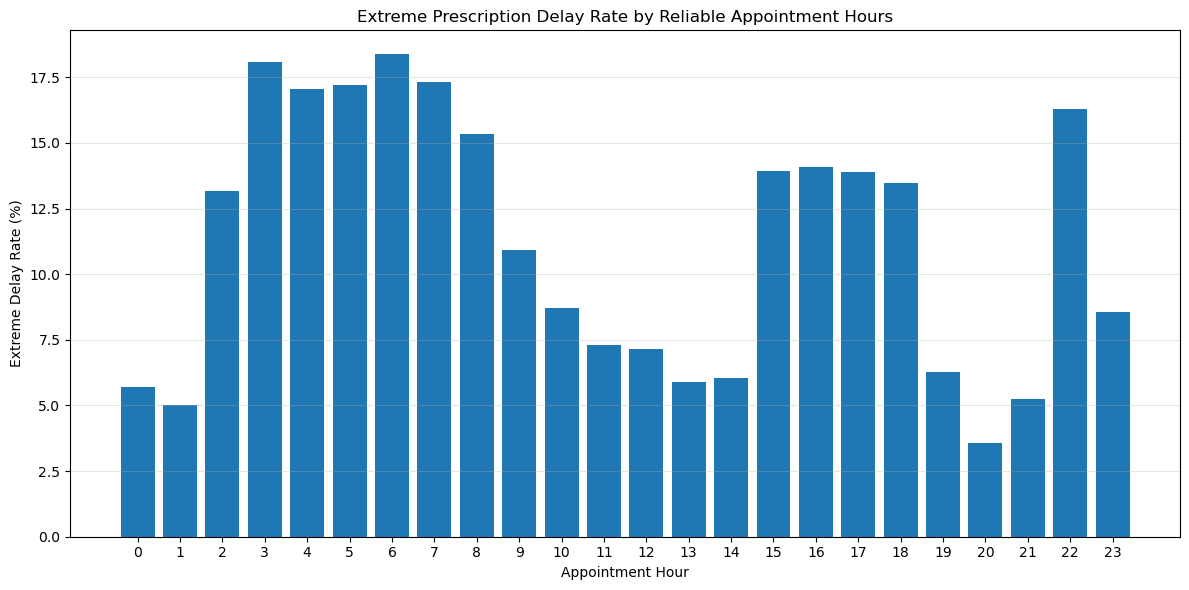

In [148]:
plt.figure(figsize=(12, 6))

plt.bar(
    reliable_prescription['appointment_hour'],
    reliable_prescription['Extreme_Delay_Rate']
)

plt.xlabel('Appointment Hour')
plt.ylabel('Extreme Delay Rate (%)')
plt.title('Extreme Prescription Delay Rate by Reliable Appointment Hours')

plt.xticks(reliable_prescription['appointment_hour'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
# Prescription Processing Time by Patient Flow

prescription_flow = df_clean[
    df_clean['prescription_processing_minutes'].notna()
].groupby('flow_name').agg(
    Average_Prescription_Time=('prescription_processing_minutes', 'mean'),
    Prescription_Records=('prescription_processing_minutes', 'count')
).reset_index()

prescription_flow['Average_Prescription_Time'] = (
    prescription_flow['Average_Prescription_Time'].round(2)
)

prescription_flow = prescription_flow.sort_values(
    'Average_Prescription_Time',
    ascending=False
)

prescription_flow

,flow_name,Average_Prescription_Time,Prescription_Records
3,Appointment â†’ Prescription â†’ Lab,3.45,16330
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,3.35,20
4,Appointment â†’ Prescription â†’ Lab + Imaging,3.33,1566
0,Appointment â†’ Prescription,3.02,39763
1,Appointment â†’ Prescription â†’ Imaging,2.58,3930
6,Appointment â†’ Prescription â†’ Pharmacy,1.66,281
2,Appointment â†’ Prescription â†’ Imaging + Pha...,1.00,1


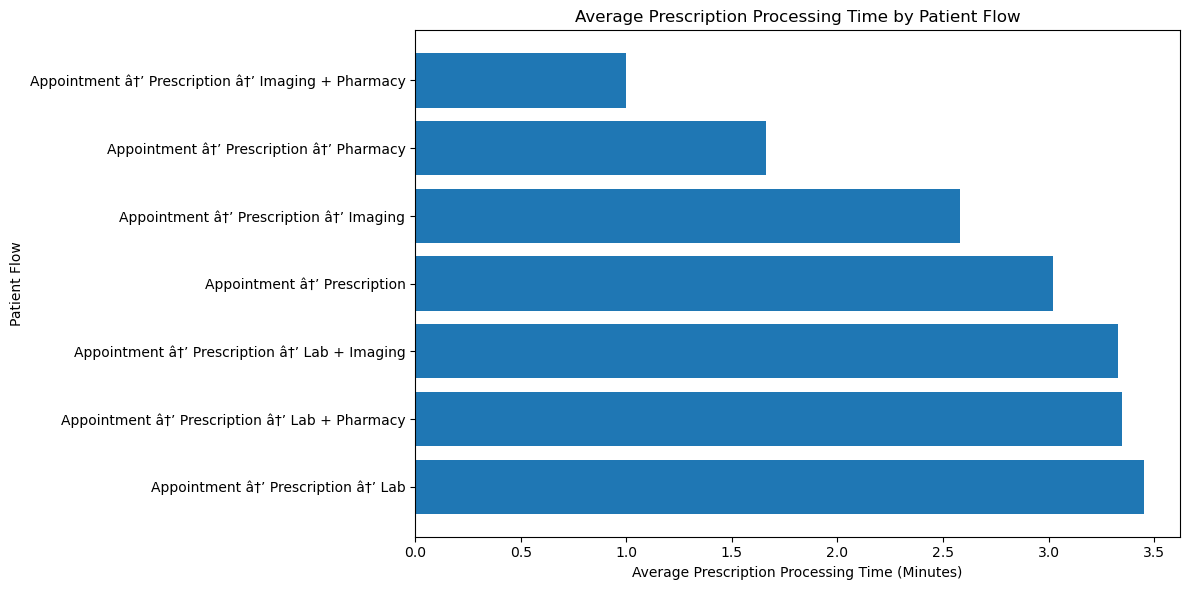

In [150]:
plt.figure(figsize=(12, 6))

plt.barh(
    prescription_flow['flow_name'],
    prescription_flow['Average_Prescription_Time']
)

plt.xlabel('Average Prescription Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Average Prescription Processing Time by Patient Flow')

plt.tight_layout()
plt.show()

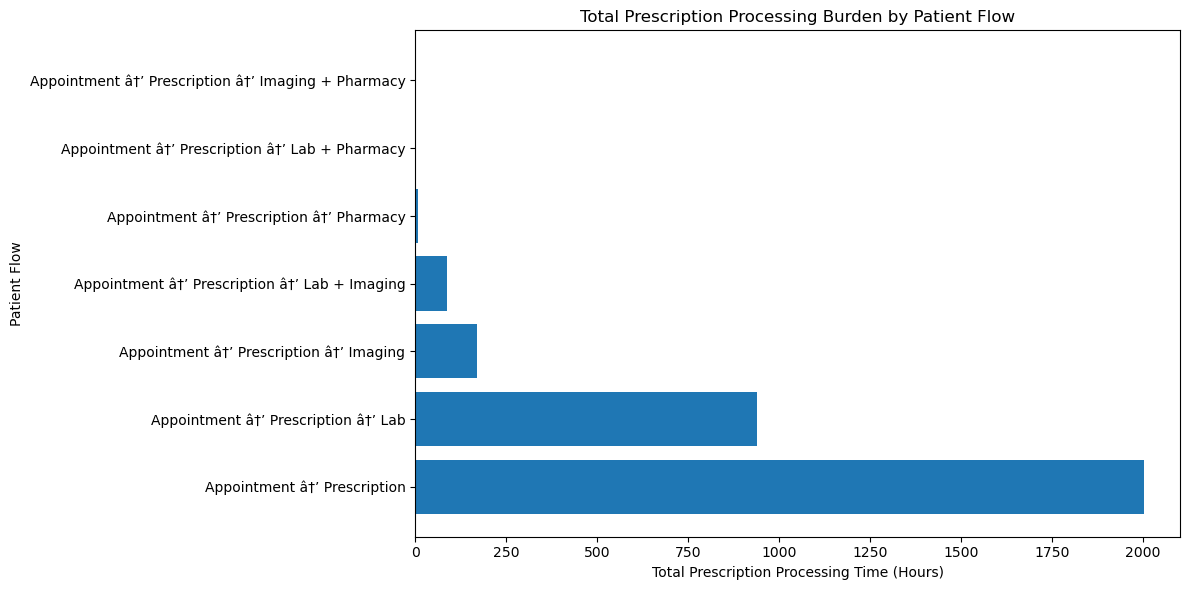

In [151]:
# Total Prescription Processing Burden by Patient Flow

prescription_flow['Total_Prescription_Time_Hours'] = (
    prescription_flow['Average_Prescription_Time'] *
    prescription_flow['Prescription_Records'] / 60
)

prescription_flow = prescription_flow.sort_values(
    'Total_Prescription_Time_Hours',
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.barh(
    prescription_flow['flow_name'],
    prescription_flow['Total_Prescription_Time_Hours']
)

plt.xlabel('Total Prescription Processing Time (Hours)')
plt.ylabel('Patient Flow')
plt.title('Total Prescription Processing Burden by Patient Flow')

plt.tight_layout()
plt.show()

In [152]:
# Overall Department Processing Burden

department_burden = pd.DataFrame({
    'Department': [
        'Prescription',
        'Lab',
        'Imaging',
        'Pharmacy'
    ],
    'Total_Processing_Hours': [
        df_clean['prescription_processing_minutes'].sum() / 60,
        df_clean['lab_processing_minutes'].sum() / 60,
        df_clean['imaging_processing_minutes'].sum() / 60,
        df_clean['pharmacy_processing_minutes'].sum() / 60
    ]
})

department_burden['Total_Processing_Hours'] = (
    department_burden['Total_Processing_Hours'].round(2)
)

department_burden = department_burden.sort_values(
    'Total_Processing_Hours',
    ascending=False
)

department_burden

,Department,Total_Processing_Hours
1,Lab,34955.72
0,Prescription,3205.77
2,Imaging,1012.32
3,Pharmacy,27.00


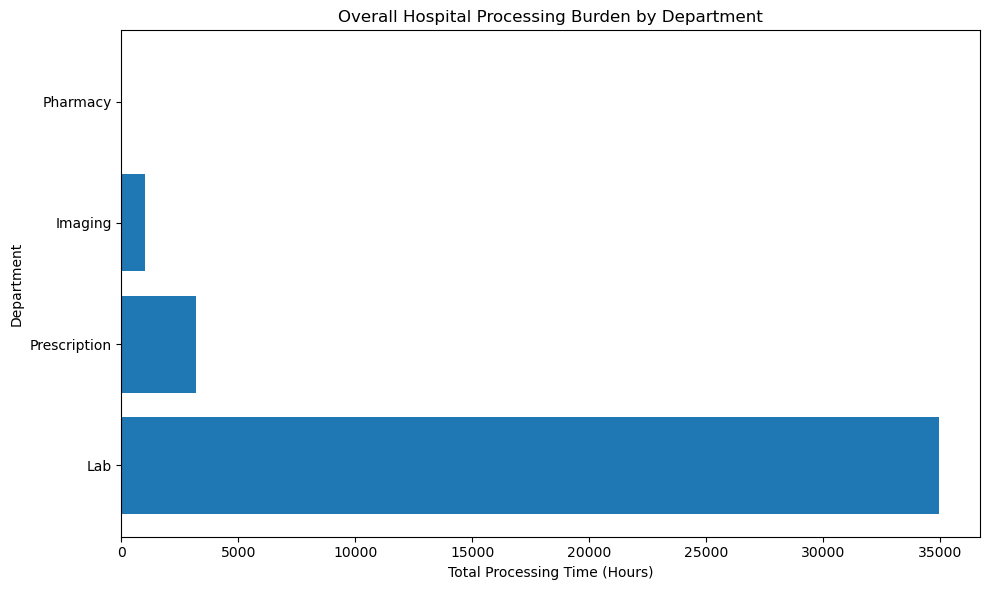

In [153]:
plt.figure(figsize=(10, 6))

plt.barh(
    department_burden['Department'],
    department_burden['Total_Processing_Hours']
)

plt.xlabel('Total Processing Time (Hours)')
plt.ylabel('Department')
plt.title('Overall Hospital Processing Burden by Department')

plt.tight_layout()
plt.show()

In [154]:
# Average Processing Time by Department

department_avg = pd.DataFrame({
    'Department': [
        'Prescription',
        'Lab',
        'Imaging',
        'Pharmacy'
    ],
    'Average_Processing_Minutes': [
        df_clean['prescription_processing_minutes'].mean(),
        df_clean['lab_processing_minutes'].mean(),
        df_clean['imaging_processing_minutes'].mean(),
        df_clean['pharmacy_processing_minutes'].mean()
    ]
})

department_avg['Average_Processing_Minutes'] = (
    department_avg['Average_Processing_Minutes'].round(2)
)

department_avg = department_avg.sort_values(
    'Average_Processing_Minutes',
    ascending=False
)

department_avg

,Department,Average_Processing_Minutes
1,Lab,167.29
2,Imaging,11.12
3,Pharmacy,5.36
0,Prescription,3.11


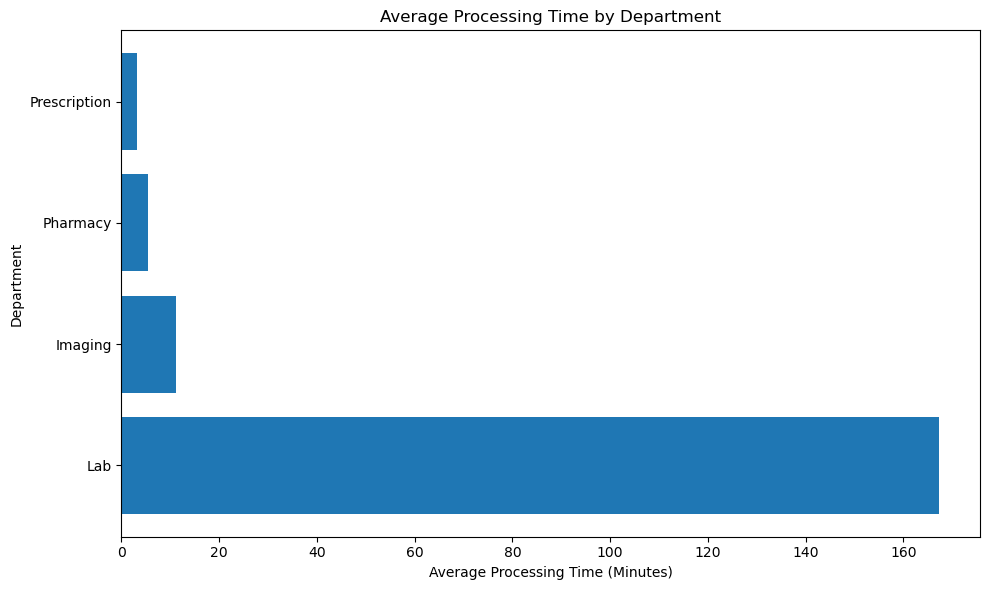

In [155]:
plt.figure(figsize=(10, 6))

plt.barh(
    department_avg['Department'],
    department_avg['Average_Processing_Minutes']
)

plt.xlabel('Average Processing Time (Minutes)')
plt.ylabel('Department')
plt.title('Average Processing Time by Department')

plt.tight_layout()
plt.show()

In [156]:
# Mean vs Median Processing Time by Department

department_summary = pd.DataFrame({
    'Department': ['Prescription', 'Lab', 'Imaging', 'Pharmacy'],
    
    'Mean_Minutes': [
        df_clean['prescription_processing_minutes'].mean(),
        df_clean['lab_processing_minutes'].mean(),
        df_clean['imaging_processing_minutes'].mean(),
        df_clean['pharmacy_processing_minutes'].mean()
    ],
    
    'Median_Minutes': [
        df_clean['prescription_processing_minutes'].median(),
        df_clean['lab_processing_minutes'].median(),
        df_clean['imaging_processing_minutes'].median(),
        df_clean['pharmacy_processing_minutes'].median()
    ]
})

department_summary = department_summary.round(2)

department_summary

,Department,Mean_Minutes,Median_Minutes
0,Prescription,3.11,0.0
1,Lab,167.29,119.0
2,Imaging,11.12,3.0
3,Pharmacy,5.36,1.0


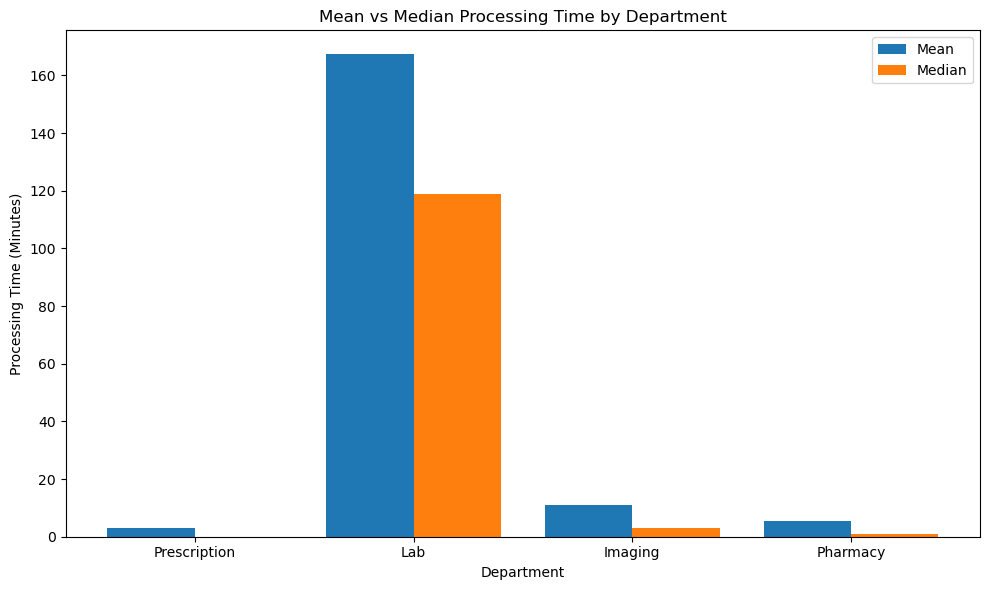

In [157]:
# Mean vs Median comparison

x = range(len(department_summary))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    department_summary['Mean_Minutes'],
    width=0.4,
    label='Mean'
)

plt.bar(
    [i + 0.2 for i in x],
    department_summary['Median_Minutes'],
    width=0.4,
    label='Median'
)

plt.xticks(x, department_summary['Department'])
plt.ylabel('Processing Time (Minutes)')
plt.xlabel('Department')
plt.title('Mean vs Median Processing Time by Department')
plt.legend()

plt.tight_layout()
plt.show()

In [158]:
# Average processing time by patient flow across all departments

flow_analysis = df_clean.groupby('flow_name').agg(
    Total_Records=('record_no', 'count'),
    Avg_Prescription_Time=('prescription_processing_minutes', 'mean'),
    Avg_Lab_Time=('lab_processing_minutes', 'mean'),
    Avg_Imaging_Time=('imaging_processing_minutes', 'mean'),
    Avg_Pharmacy_Time=('pharmacy_processing_minutes', 'mean')
).reset_index()

flow_analysis['Total_Avg_Processing_Time'] = (
    flow_analysis['Avg_Prescription_Time'].fillna(0) +
    flow_analysis['Avg_Lab_Time'].fillna(0) +
    flow_analysis['Avg_Imaging_Time'].fillna(0) +
    flow_analysis['Avg_Pharmacy_Time'].fillna(0)
)

flow_analysis = flow_analysis.sort_values(
    'Total_Avg_Processing_Time',
    ascending=False
)

flow_analysis.round(2)

,flow_name,Total_Records,Avg_Prescription_Time,Avg_Lab_Time,Avg_Imaging_Time,Avg_Pharmacy_Time,Total_Avg_Processing_Time
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,20,3.35,175.78,NaN,0.70,179.83
3,Appointment â†’ Prescription â†’ Lab,16330,3.45,170.81,NaN,NaN,174.26
4,Appointment â†’ Prescription â†’ Lab + Imaging,1566,3.33,129.89,12.88,NaN,146.10
1,Appointment â†’ Prescription â†’ Imaging,3930,2.58,NaN,10.43,NaN,13.00
6,Appointment â†’ Prescription â†’ Pharmacy,281,1.66,NaN,NaN,5.71,7.37
2,Appointment â†’ Prescription â†’ Imaging + Pha...,1,1.00,NaN,2.00,1.00,4.00
0,Appointment â†’ Prescription,39763,3.02,NaN,NaN,NaN,3.02


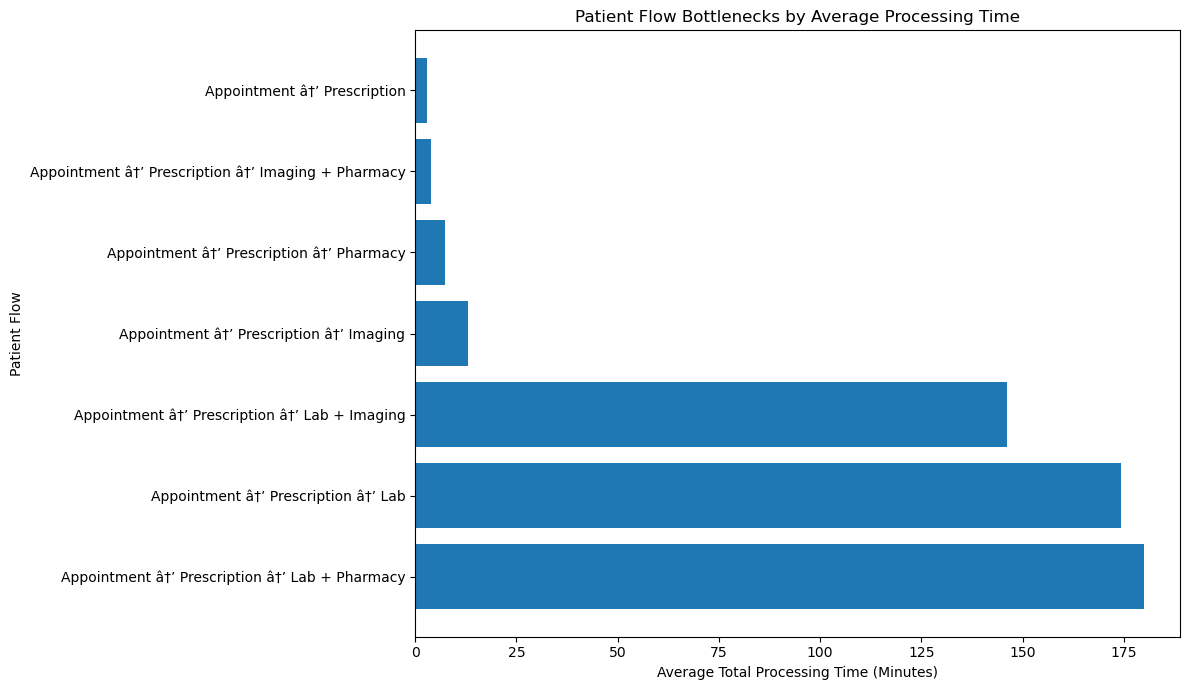

In [159]:
# Visualize bottleneck patient flows

plt.figure(figsize=(12, 7))

plt.barh(
    flow_analysis['flow_name'],
    flow_analysis['Total_Avg_Processing_Time']
)

plt.xlabel('Average Total Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Patient Flow Bottlenecks by Average Processing Time')

plt.tight_layout()
plt.show()


In [160]:
# Department contribution to each patient flow

flow_department = flow_analysis[
    [
        'flow_name',
        'Avg_Prescription_Time',
        'Avg_Lab_Time',
        'Avg_Imaging_Time',
        'Avg_Pharmacy_Time'
    ]
].copy()

flow_department = flow_department.sort_values(
    'Avg_Lab_Time',
    ascending=False
)

flow_department.round(2)

,flow_name,Avg_Prescription_Time,Avg_Lab_Time,Avg_Imaging_Time,Avg_Pharmacy_Time
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,3.35,175.78,NaN,0.70
3,Appointment â†’ Prescription â†’ Lab,3.45,170.81,NaN,NaN
4,Appointment â†’ Prescription â†’ Lab + Imaging,3.33,129.89,12.88,NaN
1,Appointment â†’ Prescription â†’ Imaging,2.58,NaN,10.43,NaN
6,Appointment â†’ Prescription â†’ Pharmacy,1.66,NaN,NaN,5.71
2,Appointment â†’ Prescription â†’ Imaging + Pha...,1.00,NaN,2.00,1.00
0,Appointment â†’ Prescription,3.02,NaN,NaN,NaN


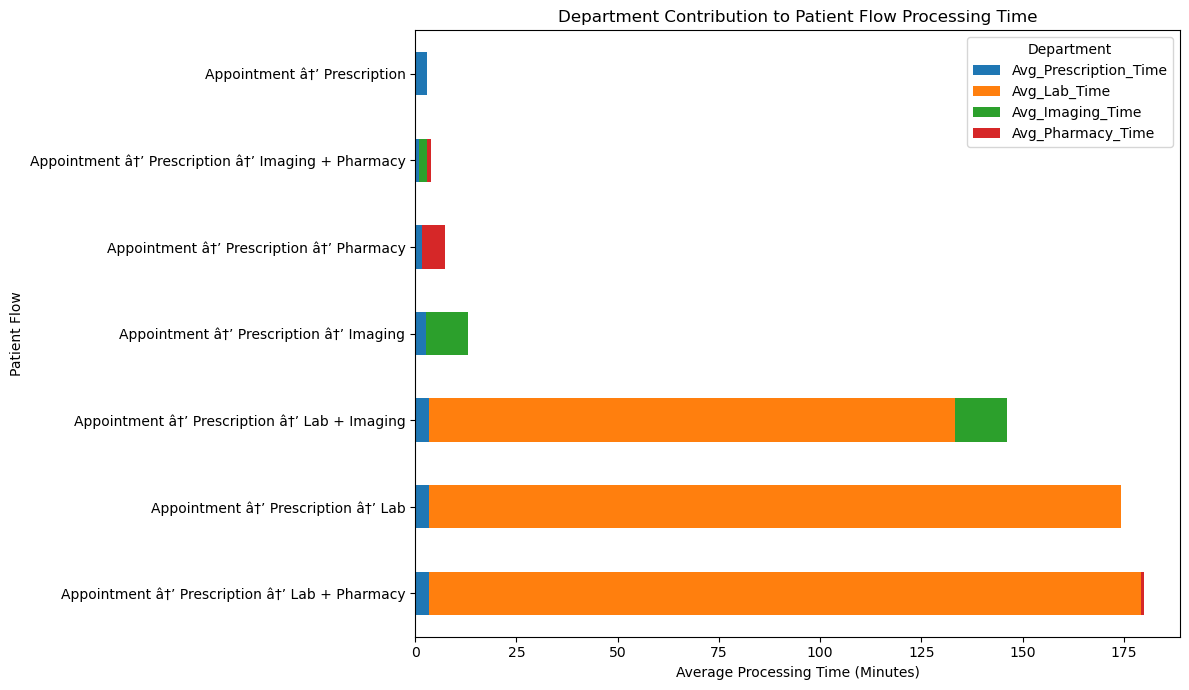

In [161]:
# Department contribution within each patient flow

plot_data = flow_department.set_index('flow_name')[
    [
        'Avg_Prescription_Time',
        'Avg_Lab_Time',
        'Avg_Imaging_Time',
        'Avg_Pharmacy_Time'
    ]
]

plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel('Average Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Department Contribution to Patient Flow Processing Time')
plt.legend(title='Department')

plt.tight_layout()
plt.show()

In [162]:


departments = {
    'Prescription': 'prescription_processing_minutes',
    'Lab': 'lab_processing_minutes',
    'Imaging': 'imaging_processing_minutes',
    'Pharmacy': 'pharmacy_processing_minutes'
}

kpi_rows = []

for department, column in departments.items():

    data = df_clean[column].dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    kpi_rows.append({
        'Department': department,
        'Records': len(data),
        'Mean_Minutes': round(data.mean(), 2),
        'Median_Minutes': round(data.median(), 2),
        'Total_Hours': round(data.sum() / 60, 2),
        'Outliers': int((data > upper_bound).sum()),
        'Upper_Outlier_Boundary': round(upper_bound, 2)
    })

final_kpi = pd.DataFrame(kpi_rows)

final_kpi

,Department,Records,Mean_Minutes,Median_Minutes,Total_Hours,Outliers,Upper_Outlier_Boundary
0,Prescription,61891,3.11,0.0,3205.77,7613,5.0
1,Lab,12537,167.29,119.0,34955.72,871,364.0
2,Imaging,5461,11.12,3.0,1012.32,353,11.0
3,Pharmacy,302,5.36,1.0,27.00,8,2.5


In [163]:
# Sort departments by total operational burden

final_kpi.sort_values(
    'Total_Hours',
    ascending=False
).reset_index(drop=True)


,Department,Records,Mean_Minutes,Median_Minutes,Total_Hours,Outliers,Upper_Outlier_Boundary
0,Lab,12537,167.29,119.0,34955.72,871,364.0
1,Prescription,61891,3.11,0.0,3205.77,7613,5.0
2,Imaging,5461,11.12,3.0,1012.32,353,11.0
3,Pharmacy,302,5.36,1.0,27.00,8,2.5


In [164]:
# Top 3 patient-flow bottlenecks

flow_analysis[
    [
        'flow_name',
        'Total_Records',
        'Total_Avg_Processing_Time'
    ]
].head(3).round(2)

,flow_name,Total_Records,Total_Avg_Processing_Time
5,Appointment â†’ Prescription â†’ Lab + Pharmacy,20,179.83
3,Appointment â†’ Prescription â†’ Lab,16330,174.26
4,Appointment â†’ Prescription â†’ Lab + Imaging,1566,146.10


In [165]:
# ============================================================
# FINAL PROJECT KPI SUMMARY
# ============================================================

total_records = len(df_clean)
total_patients = df_clean['patient_id'].nunique()
total_appointments = df_clean['appointment_id'].nunique()

summary_kpis = pd.DataFrame({
    'KPI': [
        'Total Records',
        'Unique Patients',
        'Unique Appointments',
        'Lab Processing Hours',
        'Prescription Processing Hours',
        'Imaging Processing Hours',
        'Pharmacy Processing Hours',
        'Lab Median Processing Time',
        'Imaging Median Processing Time',
        'Prescription Median Processing Time',
        'Pharmacy Median Processing Time'
    ],
    
    'Value': [
        total_records,
        total_patients,
        total_appointments,
        round(final_kpi.loc[final_kpi['Department'] == 'Lab', 'Total_Hours'].iloc[0], 2),
        round(final_kpi.loc[final_kpi['Department'] == 'Prescription', 'Total_Hours'].iloc[0], 2),
        round(final_kpi.loc[final_kpi['Department'] == 'Imaging', 'Total_Hours'].iloc[0], 2),
        round(final_kpi.loc[final_kpi['Department'] == 'Pharmacy', 'Total_Hours'].iloc[0], 2),
        final_kpi.loc[final_kpi['Department'] == 'Lab', 'Median_Minutes'].iloc[0],
        final_kpi.loc[final_kpi['Department'] == 'Imaging', 'Median_Minutes'].iloc[0],
        final_kpi.loc[final_kpi['Department'] == 'Prescription', 'Median_Minutes'].iloc[0],
        final_kpi.loc[final_kpi['Department'] == 'Pharmacy', 'Median_Minutes'].iloc[0]
    ]
})

summary_kpis

,KPI,Value
0,Total Records,61891.00
1,Unique Patients,39214.00
2,Unique Appointments,49557.00
3,Lab Processing Hours,34955.72
4,Prescription Processing Hours,3205.77
5,Imaging Processing Hours,1012.32
6,Pharmacy Processing Hours,27.00
7,Lab Median Processing Time,119.00
8,Imaging Median Processing Time,3.00
9,Prescription Median Processing Time,0.00


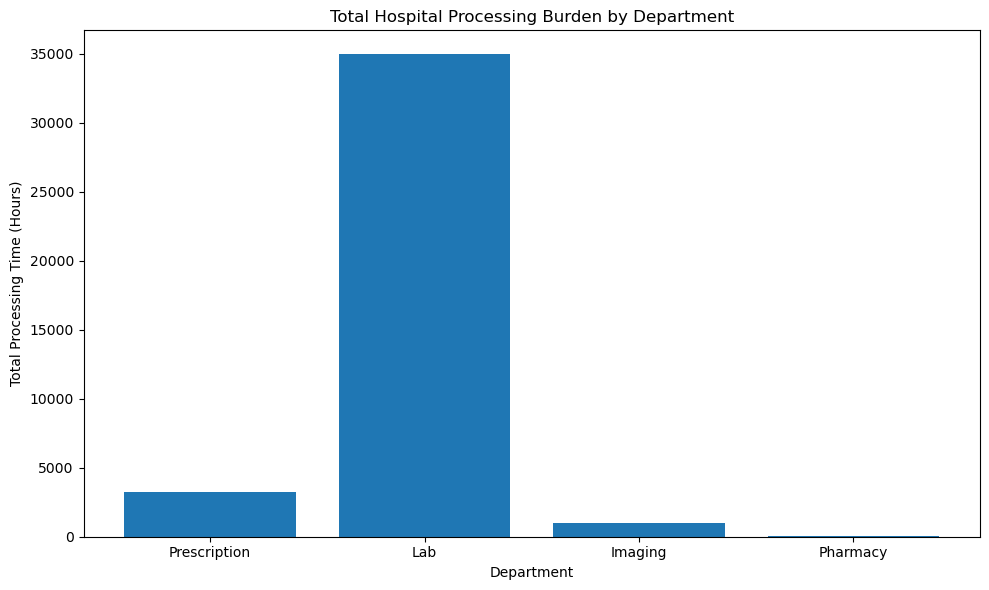

In [166]:
# ============================================================
# PROCESSING BURDEN BY DEPARTMENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    final_kpi['Department'],
    final_kpi['Total_Hours']
)

plt.xlabel('Department')
plt.ylabel('Total Processing Time (Hours)')
plt.title('Total Hospital Processing Burden by Department')

plt.tight_layout()
plt.show()

In [167]:
# Fix encoding issue in patient flow names

df_clean['flow_name'] = (
    df_clean['flow_name']
    .astype(str)
    .str.replace('â†’', '→', regex=False)
)

# Check the corrected flow names
df_clean['flow_name'].unique()

array(['Appointment → Prescription', 'Appointment → Prescription → Lab',
       'Appointment → Prescription → Imaging',
       'Appointment → Prescription → Lab + Imaging',
       'Appointment → Prescription → Pharmacy',
       'Appointment → Prescription → Lab + Pharmacy',
       'Appointment → Prescription → Imaging + Pharmacy'], dtype=object)

In [168]:
# Rebuild patient-flow analysis with corrected names

flow_analysis = df_clean.groupby('flow_name').agg(
    Total_Records=('record_no', 'count'),
    Avg_Prescription_Time=('prescription_processing_minutes', 'mean'),
    Avg_Lab_Time=('lab_processing_minutes', 'mean'),
    Avg_Imaging_Time=('imaging_processing_minutes', 'mean'),
    Avg_Pharmacy_Time=('pharmacy_processing_minutes', 'mean')
).reset_index()

flow_analysis['Total_Avg_Processing_Time'] = (
    flow_analysis['Avg_Prescription_Time'].fillna(0) +
    flow_analysis['Avg_Lab_Time'].fillna(0) +
    flow_analysis['Avg_Imaging_Time'].fillna(0) +
    flow_analysis['Avg_Pharmacy_Time'].fillna(0)
)

flow_analysis = flow_analysis.sort_values(
    'Total_Avg_Processing_Time',
    ascending=False
)

flow_analysis.round(2)

,flow_name,Total_Records,Avg_Prescription_Time,Avg_Lab_Time,Avg_Imaging_Time,Avg_Pharmacy_Time,Total_Avg_Processing_Time
5,Appointment → Prescription → Lab + Pharmacy,20,3.35,175.78,NaN,0.70,179.83
3,Appointment → Prescription → Lab,16330,3.45,170.81,NaN,NaN,174.26
4,Appointment → Prescription → Lab + Imaging,1566,3.33,129.89,12.88,NaN,146.10
1,Appointment → Prescription → Imaging,3930,2.58,NaN,10.43,NaN,13.00
6,Appointment → Prescription → Pharmacy,281,1.66,NaN,NaN,5.71,7.37
2,Appointment → Prescription → Imaging + Pharmacy,1,1.00,NaN,2.00,1.00,4.00
0,Appointment → Prescription,39763,3.02,NaN,NaN,NaN,3.02


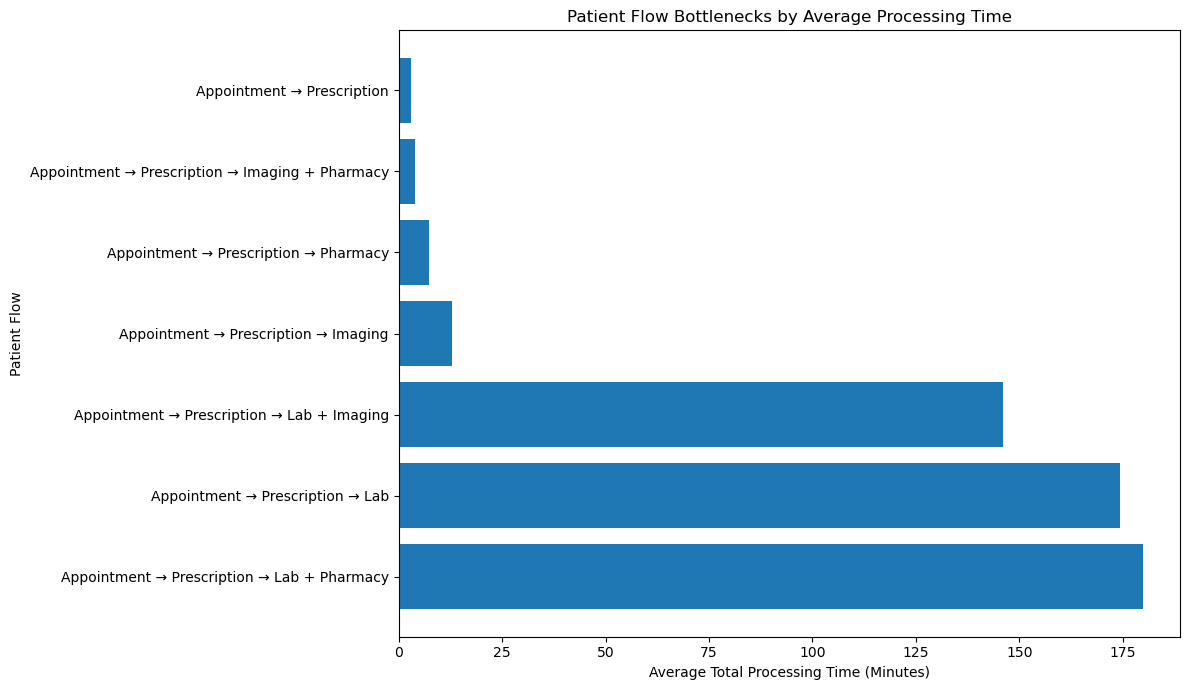

In [169]:
plt.figure(figsize=(12, 7))

plt.barh(
    flow_analysis['flow_name'],
    flow_analysis['Total_Avg_Processing_Time']
)

plt.xlabel('Average Total Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Patient Flow Bottlenecks by Average Processing Time')

plt.tight_layout()
plt.show()

In [170]:


print("========== HOSPITAL OPERATIONS KPI SUMMARY ==========\n")

print("1. DEPARTMENT WITH HIGHEST TOTAL PROCESSING BURDEN")
print(
    final_kpi.sort_values('Total_Hours', ascending=False)
    [['Department', 'Total_Hours']]
    .head(1)
    .to_string(index=False)
)

print("\n2. DEPARTMENT WITH HIGHEST AVERAGE PROCESSING TIME")
print(
    final_kpi.sort_values('Mean_Minutes', ascending=False)
    [['Department', 'Mean_Minutes']]
    .head(1)
    .to_string(index=False)
)

print("\n3. TOP PATIENT-FLOW BOTTLENECKS")
print(
    flow_analysis[
        ['flow_name', 'Total_Records', 'Total_Avg_Processing_Time']
    ]
    .head(3)
    .round(2)
    .to_string(index=False)
)

print("\n4. KEY OPERATIONAL FINDING")
print(
    "Lab processing is the dominant contributor to overall hospital "
    "processing time and represents the primary operational bottleneck."
)

========== HOSPITAL OPERATIONS KPI SUMMARY ==========

1. DEPARTMENT WITH HIGHEST TOTAL PROCESSING BURDEN
Department  Total_Hours
       Lab     34955.72

2. DEPARTMENT WITH HIGHEST AVERAGE PROCESSING TIME
Department  Mean_Minutes
       Lab        167.29

3. TOP PATIENT-FLOW BOTTLENECKS
                                  flow_name  Total_Records  Total_Avg_Processing_Time
Appointment → Prescription → Lab + Pharmacy             20                     179.83
           Appointment → Prescription → Lab          16330                     174.26
 Appointment → Prescription → Lab + Imaging           1566                     146.10

4. KEY OPERATIONAL FINDING
Lab processing is the dominant contributor to overall hospital processing time and represents the primary operational bottleneck.


# Key Insights & Operational Recommendations

## Key Insights

### 1. Laboratory processing is the primary bottleneck
The Lab department has the highest overall processing burden, with approximately **34,955.72 total processing hours** and an average processing time of **167.29 minutes**.

This makes Lab the most important department to investigate for operational improvements.

### 2. Patient flows involving Lab have the highest delays
The three highest average processing-time patient flows all involve Laboratory processing:

- Appointment → Prescription → Lab + Pharmacy: **179.83 minutes**
- Appointment → Prescription → Lab: **174.26 minutes**
- Appointment → Prescription → Lab + Imaging: **146.10 minutes**

This indicates that Laboratory processing is the major contributor to long patient journeys.

### 3. Prescription processing has a high volume but relatively low typical processing time
Prescription processing contains **61,891 records**, but its median processing time is only **0 minutes**.

However, there are **7,613 extreme outliers**, indicating that a smaller group of prescription transactions experience unusually long delays.

These outliers should be investigated separately rather than assuming that prescription processing is consistently slow.

### 4. Pharmacy workload does not strongly explain processing time
The correlation between Pharmacy workload and average processing time is only **0.12**.

This suggests that increasing pharmacy workload alone does not strongly explain increases in processing time. Other factors such as workflow design, exceptions, staffing, or individual cases may be more important.

### 5. Imaging has a smaller overall burden but can create significant delays
Imaging has a lower total processing burden than Lab, but extreme imaging delays are concentrated at specific appointment hours.

This suggests that scheduling and resource availability may need to be examined during those periods.

---

# Operational Recommendations

### Priority 1 — Optimize Laboratory Operations
- Investigate the causes of long Lab processing times.
- Review staffing levels during high-demand periods.
- Identify stages within the Lab workflow causing delays.
- Consider workload balancing and process automation.

### Priority 2 — Investigate Extreme Prescription Delays
- Review the records exceeding the prescription outlier threshold.
- Determine whether these are genuine delays, data-quality issues, or unusual cases.
- Separate operational delays from possible timestamp/data-entry problems.

### Priority 3 — Optimize Patient Flows
Focus first on patient journeys involving:

**Appointment → Prescription → Lab + Pharmacy**

and

**Appointment → Prescription → Lab**

because these flows have the highest average processing times.

### Priority 4 — Review Imaging Scheduling
Investigate appointment hours associated with extreme imaging delays and determine whether scheduling patterns, staffing, or equipment availability contribute to the issue.

---

# Overall Conclusion

The analysis indicates that **Laboratory processing is the dominant operational bottleneck in the hospital**.

Improving Lab workflow and reducing delays in patient flows involving Lab should therefore be the highest operational priority.

Prescription processing should be addressed separately through **outlier investigation**, while Imaging requires **time-specific capacity and scheduling analysis**.


# Final Takeaway

The hospital's overall processing burden is primarily driven by **Laboratory operations**. Patient flows involving Lab consistently show the highest average processing times, making Lab workflow optimization the most important improvement opportunity.

Prescription processing requires a different approach: despite its high transaction volume, its typical processing time is low, while a smaller number of extreme outliers create significant delays.

Overall, the analysis suggests that the hospital should prioritize **Lab capacity and workflow optimization**, investigate **Prescription outliers**, and review **time-specific Imaging delays** to improve patient flow and operational efficiency.

In [173]:
# Prescription Processing Time - Outlier Validation

prescription_values = df_clean[
    'prescription_processing_minutes'
].dropna()

print("Prescription Processing Time - Data Quality Check")
print("=" * 55)

print(f"Total records: {len(prescription_values):,}")
print(f"Minimum: {prescription_values.min():.2f} minutes")
print(f"Median: {prescription_values.median():.2f} minutes")
print(f"Mean: {prescription_values.mean():.2f} minutes")
print(f"Maximum: {prescription_values.max():.2f} minutes")

print("\nPercentiles:")
print(prescription_values.quantile([0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

print("\nRecords above 5 minutes:")
print((prescription_values > 5).sum())

print("\nRecords above 60 minutes:")
print((prescription_values > 60).sum())

print("\nRecords above 240 minutes:")
print((prescription_values > 240).sum())

print("\nTop 20 highest processing times:")
print(
    prescription_values
    .sort_values(ascending=False)
    .head(20)
    .to_string(index=False)
)

Prescription Processing Time - Data Quality Check
Total records: 61,891
Minimum: 0.00 minutes
Median: 0.00 minutes
Mean: 3.11 minutes
Maximum: 1420.00 minutes

Percentiles:
0.50     0.0
0.75     2.0
0.90     7.0
0.95    12.0
0.99    44.0
Name: prescription_processing_minutes, dtype: float64

Records above 5 minutes:
7613

Records above 60 minutes:
299

Records above 240 minutes:
23

Top 20 highest processing times:
1420
1420
1420
1393
1393
1393
1393
1366
1330
1330
1321
1321
1321
1253
1149
 921
 920
 849
 831
 831


In [174]:
# Validate extreme prescription processing times using timestamps

extreme_prescriptions = df_clean[
    df_clean['prescription_processing_minutes'] > 60
][[
    'record_no',
    'patient_id',
    'appointment_id',
    'appointment_start_datetime',
    'prescription_start_datetime',
    'prescription_end_datetime',
    'prescription_processing_minutes'
]].sort_values(
    'prescription_processing_minutes',
    ascending=False
)

print("Extreme Prescription Processing Records (>60 minutes)")
print("=" * 70)

print(
    extreme_prescriptions.head(20).to_string(index=False)
)

Extreme Prescription Processing Records (>60 minutes)
 record_no  patient_id  appointment_id appointment_start_datetime prescription_start_datetime prescription_end_datetime  prescription_processing_minutes
     23395      197963          210923        2025-04-10 03:53:00         2025-04-10 04:07:00       2025-04-11 03:47:00                             1420
     23396      197963          210923        2025-04-10 03:53:00         2025-04-10 04:07:00       2025-04-11 03:47:00                             1420
     23397      197963          210923        2025-04-10 03:53:00         2025-04-10 04:07:00       2025-04-11 03:47:00                             1420
     14427      109411          427884        2026-02-26 05:09:00         2026-02-26 05:21:00       2026-02-27 04:34:00                             1393
     14430      109411          427884        2026-02-26 05:09:00         2026-02-26 05:21:00       2026-02-27 04:34:00                             1393
     14428      109411      

In [175]:
# Quantify exact duplicate records in the prescription data

prescription_cols = [
    'patient_id',
    'appointment_id',
    'prescription_start_datetime',
    'prescription_end_datetime',
    'prescription_processing_minutes'
]

exact_duplicates = df_clean.duplicated(
    subset=prescription_cols,
    keep=False
)

print("DUPLICATE RECORD IMPACT")
print("=" * 50)

print("Total prescription records:", len(df_clean))

print(
    "Records involved in duplicates:",
    exact_duplicates.sum()
)

print(
    "Percentage of records involved in duplicates:",
    round(exact_duplicates.mean() * 100, 2),
    "%"
)

print("\nUnique prescription events after removing duplicates:")

deduplicated_prescriptions = df_clean.drop_duplicates(
    subset=prescription_cols
)

print(len(deduplicated_prescriptions))

print(
    "Records removed:",
    len(df_clean) - len(deduplicated_prescriptions)
)

DUPLICATE RECORD IMPACT
Total prescription records: 61891
Records involved in duplicates: 16068
Percentage of records involved in duplicates: 25.96 %

Unique prescription events after removing duplicates:
50103
Records removed: 11788


In [176]:
# Quantify exact duplicate records in the prescription data

prescription_cols = [
    'patient_id',
    'appointment_id',
    'prescription_start_datetime',
    'prescription_end_datetime',
    'prescription_processing_minutes'
]

exact_duplicates = df_clean.duplicated(
    subset=prescription_cols,
    keep=False
)

print("DUPLICATE RECORD IMPACT")
print("=" * 50)

print("Total prescription records:", len(df_clean))
print("Records involved in duplicates:", exact_duplicates.sum())
print(
    "Percentage of records involved in duplicates:",
    round(exact_duplicates.mean() * 100, 2),
    "%"
)

print("\nUnique prescription events after removing duplicates:")

deduplicated_prescriptions = df_clean.drop_duplicates(
    subset=prescription_cols
)

print(len(deduplicated_prescriptions))

print(
    "Records removed:",
    len(df_clean) - len(deduplicated_prescriptions)
)

DUPLICATE RECORD IMPACT
Total prescription records: 61891
Records involved in duplicates: 16068
Percentage of records involved in duplicates: 25.96 %

Unique prescription events after removing duplicates:
50103
Records removed: 11788


In [177]:
prescription_dedup = df_clean.drop_duplicates(
    subset=prescription_cols,
    keep='first'
).copy()

print("Original records:", len(df_clean))
print("Deduplicated records:", len(prescription_dedup))
print("Records removed:", len(df_clean) - len(prescription_dedup))

print("\nProcessing-time comparison")
print("Original mean:",
      round(df_clean['prescription_processing_minutes'].mean(), 2))
print("Deduplicated mean:",
      round(prescription_dedup['prescription_processing_minutes'].mean(), 2))

print("Original median:",
      round(df_clean['prescription_processing_minutes'].median(), 2))
print("Deduplicated median:",
      round(prescription_dedup['prescription_processing_minutes'].median(), 2))

print("\nOutliers above 5 minutes")
print("Original:",
      (df_clean['prescription_processing_minutes'] > 5).sum())
print("Deduplicated:",
      (prescription_dedup['prescription_processing_minutes'] > 5).sum())

Original records: 61891
Deduplicated records: 50103
Records removed: 11788

Processing-time comparison
Original mean: 3.11
Deduplicated mean: 3.02
Original median: 0.0
Deduplicated median: 0.0

Outliers above 5 minutes
Original: 7613
Deduplicated: 6217


In [178]:
# Final prescription outlier analysis after deduplication

q1 = prescription_dedup['prescription_processing_minutes'].quantile(0.25)
q3 = prescription_dedup['prescription_processing_minutes'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

print("DEDUPLICATED PRESCRIPTION OUTLIER ANALYSIS")
print("=" * 55)

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Upper Outlier Boundary:", round(upper_bound, 2))

print(
    "Number of IQR outliers:",
    (prescription_dedup['prescription_processing_minutes'] > upper_bound).sum()
)

print(
    "Records above 60 minutes:",
    (prescription_dedup['prescription_processing_minutes'] > 60).sum()
)

print(
    "Records above 240 minutes:",
    (prescription_dedup['prescription_processing_minutes'] > 240).sum()
)

print(
    "Maximum processing time:",
    prescription_dedup['prescription_processing_minutes'].max()
)

print("\nTop 20 highest processing times:")
print(
    prescription_dedup[
        'prescription_processing_minutes'
    ].nlargest(20).to_list()
)

DEDUPLICATED PRESCRIPTION OUTLIER ANALYSIS
Q1: 0.0
Q3: 2.0
IQR: 2.0
Upper Outlier Boundary: 5.0
Number of IQR outliers: 6217
Records above 60 minutes: 225
Records above 240 minutes: 15
Maximum processing time: 1420

Top 20 highest processing times:
[1420, 1393, 1366, 1330, 1321, 1253, 1149, 921, 920, 849, 831, 831, 634, 527, 275, 229, 225, 215, 209, 207]


In [179]:
# Check whether prescription deduplication changes patient-flow metrics

print("Prescription data is now deduplicated.")
print("Unique prescription events:", len(prescription_dedup))

print("\nPrescription processing summary:")
print(
    prescription_dedup[
        'prescription_processing_minutes'
    ].describe()
)

Prescription data is now deduplicated.
Unique prescription events: 50103

Prescription processing summary:
count    50103.000000
mean         3.017763
std         20.275383
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max       1420.000000
Name: prescription_processing_minutes, dtype: float64


In [180]:
# Identify existing dataframes used in the patient-flow analysis

import pandas as pd

print("AVAILABLE DATAFRAMES")
print("=" * 60)

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):

        cols = list(obj.columns)

        relevant_terms = [
            'patient_id',
            'appointment_id',
            'prescription',
            'lab',
            'imaging',
            'pharmacy'
        ]

        if any(
            any(term in str(col).lower() for term in relevant_terms)
            for col in cols
        ):
            print(f"\n{name}")
            print("Rows:", len(obj))
            print("Columns:")
            print(cols)

AVAILABLE DATAFRAMES

__
Rows: 15
Columns:
['prescription_doctor_name', 'Appointment_Count', 'Average_Processing_Time']

df
Rows: 61895
Columns:
['record_no', 'patient_id', 'appointment_id', 'appointment_start_datetime', 'prescription_doctor_id', 'prescription_doctor_name', 'prescription_order_id', 'prescription_start_datetime', 'prescription_end_datetime', 'lab_id', 'lab_name', 'lab_start_datetime', 'lab_end_datetime', 'imaging_request_id', 'imaging_result_id', 'imaging_name', 'imaging_start_datetime', 'imaging_end_datetime', 'pharmacy_sale_line_id', 'medicine_name', 'pharmacy_start_datetime', 'pharmacy_end_datetime', 'flow_code', 'flow_name', 'prescription_processing_minutes', 'lab_processing_minutes', 'imaging_processing_minutes', 'pharmacy_processing_minutes', 'appointment_to_prescription_minutes', 'appointment_hour', 'appointment_month']

_3
Rows: 5
Columns:
['record_no', 'patient_id', 'appointment_id', 'appointment_start_datetime', 'prescription_doctor_id', 'prescription_doctor_n

In [181]:
# ============================================================
# CORRECTED PATIENT-FLOW ANALYSIS
# Uses deduplicated prescription events
# ============================================================

# Aggregate patient flows using the deduplicated prescription data
flow_analysis_corrected = (
    prescription_dedup
    .groupby('flow_name')
    .agg(
        Total_Records=('flow_name', 'size'),
        Avg_Prescription_Time=('prescription_processing_minutes', 'mean'),
        Avg_Lab_Time=('lab_processing_minutes', 'mean'),
        Avg_Imaging_Time=('imaging_processing_minutes', 'mean'),
        Avg_Pharmacy_Time=('pharmacy_processing_minutes', 'mean')
    )
    .reset_index()
)

# Calculate total average processing time for each flow
flow_analysis_corrected['Total_Avg_Processing_Time'] = (
    flow_analysis_corrected['Avg_Prescription_Time'].fillna(0)
    + flow_analysis_corrected['Avg_Lab_Time'].fillna(0)
    + flow_analysis_corrected['Avg_Imaging_Time'].fillna(0)
    + flow_analysis_corrected['Avg_Pharmacy_Time'].fillna(0)
)

# Sort by highest average processing time
flow_analysis_corrected = (
    flow_analysis_corrected
    .sort_values('Total_Avg_Processing_Time', ascending=False)
    .reset_index(drop=True)
)

# Round the results
flow_analysis_corrected[
    [
        'Avg_Prescription_Time',
        'Avg_Lab_Time',
        'Avg_Imaging_Time',
        'Avg_Pharmacy_Time',
        'Total_Avg_Processing_Time'
    ]
] = flow_analysis_corrected[
    [
        'Avg_Prescription_Time',
        'Avg_Lab_Time',
        'Avg_Imaging_Time',
        'Avg_Pharmacy_Time',
        'Total_Avg_Processing_Time'
    ]
].round(2)

print("CORRECTED PATIENT-FLOW ANALYSIS")
print("=" * 70)

display(flow_analysis_corrected)

CORRECTED PATIENT-FLOW ANALYSIS


,flow_name,Total_Records,Avg_Prescription_Time,Avg_Lab_Time,Avg_Imaging_Time,Avg_Pharmacy_Time,Total_Avg_Processing_Time
0,Appointment → Prescription → Lab + Pharmacy,14,3.07,204.00,NaN,0.79,207.86
1,Appointment → Prescription → Lab + Imaging,1545,3.34,129.11,12.86,NaN,145.31
2,Appointment → Prescription → Lab,4839,3.23,129.67,NaN,NaN,132.90
3,Appointment → Prescription → Imaging,3850,2.60,NaN,10.54,NaN,13.15
4,Appointment → Prescription → Pharmacy,94,1.72,NaN,NaN,8.14,9.86
5,Appointment → Prescription → Imaging + Pharmacy,1,1.00,NaN,2.00,1.00,4.00
6,Appointment → Prescription,39760,3.02,NaN,NaN,NaN,3.02


In [182]:
# ============================================================
# OLD VS CORRECTED PATIENT-FLOW COMPARISON
# ============================================================

comparison = flow_analysis[
    ['flow_name', 'Total_Records', 'Total_Avg_Processing_Time']
].merge(
    flow_analysis_corrected[
        ['flow_name', 'Total_Records', 'Total_Avg_Processing_Time']
    ],
    on='flow_name',
    how='outer',
    suffixes=('_Original', '_Corrected')
)

comparison['Record_Change'] = (
    comparison['Total_Records_Corrected']
    - comparison['Total_Records_Original']
)

comparison['Time_Change_Minutes'] = (
    comparison['Total_Avg_Processing_Time_Corrected']
    - comparison['Total_Avg_Processing_Time_Original']
)

comparison['Time_Change_Percent'] = (
    comparison['Time_Change_Minutes']
    / comparison['Total_Avg_Processing_Time_Original']
    * 100
)

comparison = comparison.sort_values(
    'Total_Avg_Processing_Time_Corrected',
    ascending=False
)

comparison.round(2)

,flow_name,Total_Records_Original,Total_Avg_Processing_Time_Original,Total_Records_Corrected,Total_Avg_Processing_Time_Corrected,Record_Change,Time_Change_Minutes,Time_Change_Percent
5,Appointment → Prescription → Lab + Pharmacy,20,179.83,14,207.86,-6,28.03,15.59
4,Appointment → Prescription → Lab + Imaging,1566,146.10,1545,145.31,-21,-0.79,-0.54
3,Appointment → Prescription → Lab,16330,174.26,4839,132.90,-11491,-41.36,-23.74
1,Appointment → Prescription → Imaging,3930,13.00,3850,13.15,-80,0.15,1.13
6,Appointment → Prescription → Pharmacy,281,7.37,94,9.86,-187,2.49,33.78
2,Appointment → Prescription → Imaging + Pharmacy,1,4.00,1,4.00,0,0.00,0.00
0,Appointment → Prescription,39763,3.02,39760,3.02,-3,-0.00,-0.06


In [183]:
# ============================================================
# FINAL CORRECTED HOSPITAL OPERATIONS KPI SUMMARY
# ============================================================

print("=" * 70)
print("FINAL CORRECTED HOSPITAL OPERATIONS KPI SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Department-level processing summary
# ------------------------------------------------------------

department_data = {
    'Prescription': prescription_dedup['prescription_processing_minutes'],
    'Lab': df_clean['lab_processing_minutes'].dropna(),
    'Imaging': df_clean['imaging_processing_minutes'].dropna(),
    'Pharmacy': df_clean['pharmacy_processing_minutes'].dropna()
}

department_summary = []

for department, values in department_data.items():
    department_summary.append({
        'Department': department,
        'Records': len(values),
        'Mean_Minutes': values.mean(),
        'Median_Minutes': values.median(),
        'Total_Hours': values.sum() / 60
    })

department_summary = pd.DataFrame(department_summary)

department_summary = department_summary.sort_values(
    'Total_Hours',
    ascending=False
)

print("\n1. DEPARTMENT PROCESSING SUMMARY")
print("-" * 70)

print(
    department_summary.round(2).to_string(index=False)
)


# ------------------------------------------------------------
# 2. Corrected patient-flow summary
# ------------------------------------------------------------

print("\n2. CORRECTED PATIENT-FLOW SUMMARY")
print("-" * 70)

corrected_flow_summary = (
    flow_analysis_corrected[
        [
            'flow_name',
            'Total_Records',
            'Total_Avg_Processing_Time'
        ]
    ]
    .sort_values(
        'Total_Avg_Processing_Time',
        ascending=False
    )
)

print(
    corrected_flow_summary
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 3. Top 3 corrected bottlenecks
# ------------------------------------------------------------

print("\n3. TOP 3 CORRECTED PATIENT-FLOW BOTTLENECKS")
print("-" * 70)

top_3_corrected = corrected_flow_summary.head(3)

print(
    top_3_corrected
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 4. Key operational finding
# ------------------------------------------------------------

print("\n4. KEY OPERATIONAL FINDING")
print("-" * 70)

print(
    "Laboratory processing remains the dominant operational "
    "bottleneck, particularly in patient flows involving Lab."
)

print(
    "Prescription processing requires separate outlier and "
    "data-quality investigation because duplicate records "
    "and extreme delays were identified."
)

FINAL CORRECTED HOSPITAL OPERATIONS KPI SUMMARY

1. DEPARTMENT PROCESSING SUMMARY
----------------------------------------------------------------------
  Department  Records  Mean_Minutes  Median_Minutes  Total_Hours
         Lab    12537        167.29           119.0     34955.72
Prescription    50103          3.02             0.0      2519.98
     Imaging     5461         11.12             3.0      1012.32
    Pharmacy      302          5.36             1.0        27.00

2. CORRECTED PATIENT-FLOW SUMMARY
----------------------------------------------------------------------
                                      flow_name  Total_Records  Total_Avg_Processing_Time
    Appointment → Prescription → Lab + Pharmacy             14                     207.86
     Appointment → Prescription → Lab + Imaging           1545                     145.31
               Appointment → Prescription → Lab           4839                     132.90
           Appointment → Prescription → Imaging         

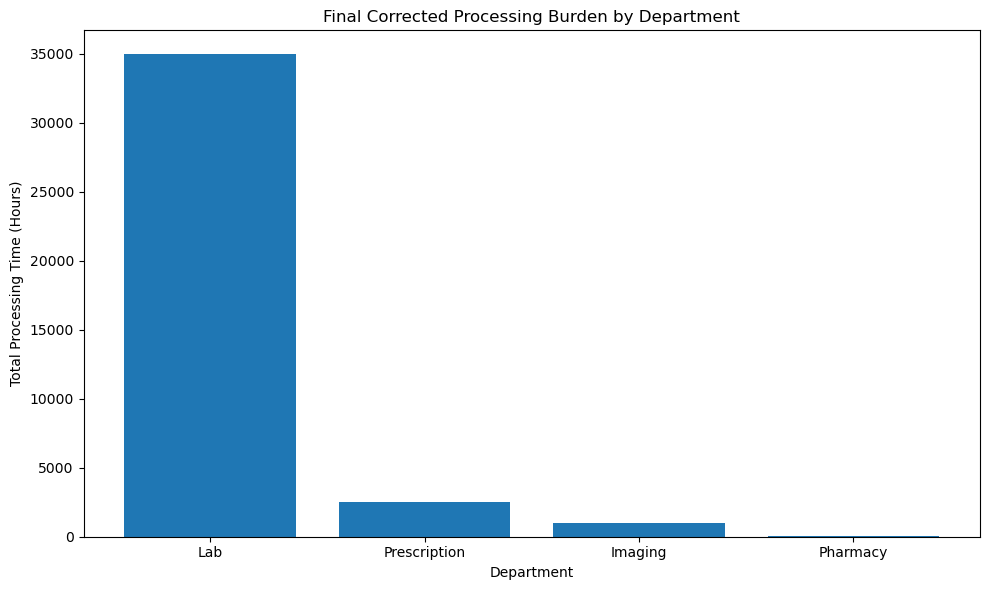

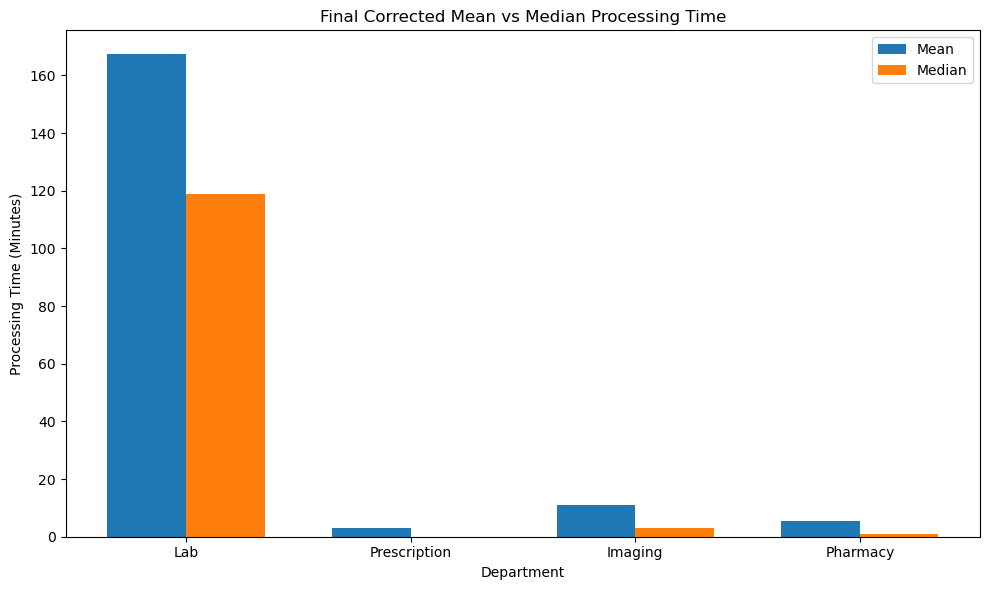

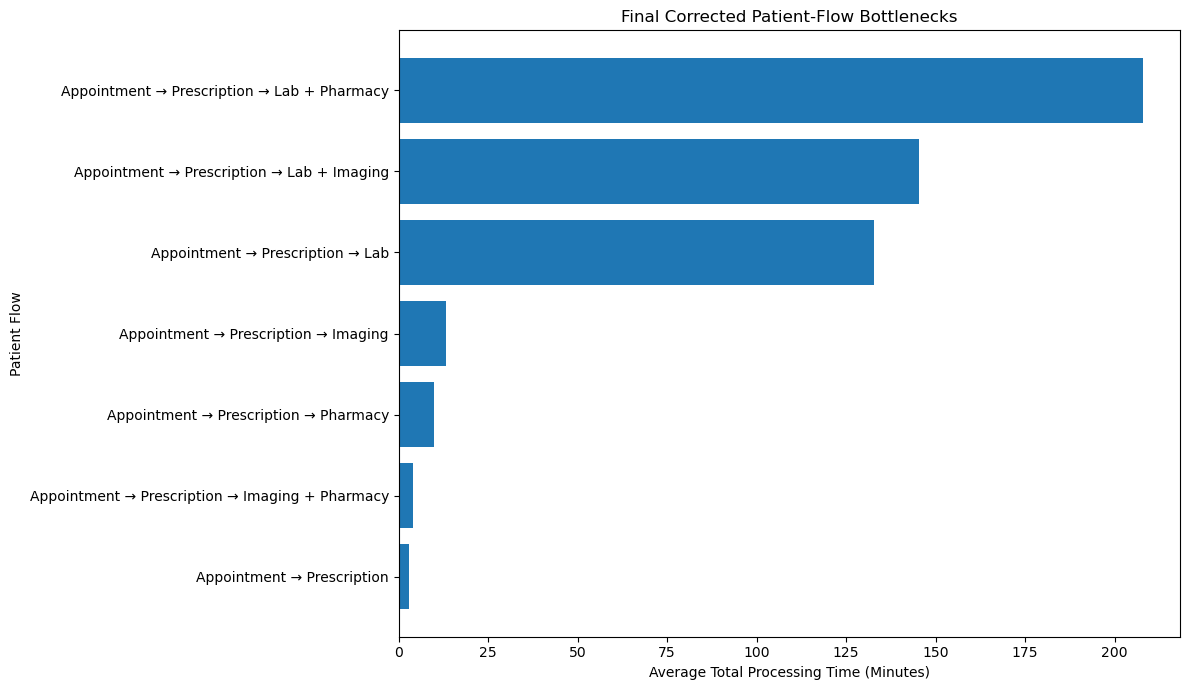

In [184]:
# ============================================================
# FINAL CORRECTED VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# 1. Total Processing Burden by Department
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    department_summary['Department'],
    department_summary['Total_Hours']
)

plt.xlabel('Department')
plt.ylabel('Total Processing Time (Hours)')
plt.title('Final Corrected Processing Burden by Department')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Mean vs Median Processing Time
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

x = range(len(department_summary))

width = 0.35

plt.bar(
    [i - width/2 for i in x],
    department_summary['Mean_Minutes'],
    width=width,
    label='Mean'
)

plt.bar(
    [i + width/2 for i in x],
    department_summary['Median_Minutes'],
    width=width,
    label='Median'
)

plt.xticks(
    list(x),
    department_summary['Department']
)

plt.xlabel('Department')
plt.ylabel('Processing Time (Minutes)')
plt.title('Final Corrected Mean vs Median Processing Time')
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Corrected Patient-Flow Bottlenecks
# ------------------------------------------------------------

flow_plot = (
    flow_analysis_corrected
    .sort_values(
        'Total_Avg_Processing_Time',
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

plt.barh(
    flow_plot['flow_name'],
    flow_plot['Total_Avg_Processing_Time']
)

plt.xlabel('Average Total Processing Time (Minutes)')
plt.ylabel('Patient Flow')
plt.title('Final Corrected Patient-Flow Bottlenecks')

plt.tight_layout()
plt.show()

# Key Insights & Operational Recommendations

## Key Insights

### 1. Laboratory processing is the primary operational bottleneck

The Laboratory department has the highest overall processing burden, with approximately **34,955.72 total processing hours** and an average processing time of **167.29 minutes**.

This makes Laboratory workflow the highest-priority area for operational improvement.

### 2. Patient flows involving Laboratory have the highest delays

The corrected patient-flow analysis shows that the longest average processing times occur in flows involving Laboratory:

- **Appointment → Prescription → Lab + Pharmacy:** 207.86 minutes  
- **Appointment → Prescription → Lab + Imaging:** 145.31 minutes  
- **Appointment → Prescription → Lab:** 132.90 minutes  

The Lab + Pharmacy flow has only **14 records**, so it should be treated as a high-delay but low-volume flow. The larger Lab-related flows provide stronger evidence of a recurring operational bottleneck.

### 3. Laboratory processing combines high workload with high processing time

Laboratory has both:

- The highest total processing burden: **34,955.72 hours**
- The highest mean processing time: **167.29 minutes**
- A median processing time of **119 minutes**

This combination indicates that the Lab is not only processing a large volume of work, but individual Lab transactions also take substantially longer than other departments.

### 4. Prescription processing has a data-quality and outlier problem

After deduplication:

- Original prescription records: **61,891**
- Unique prescription events: **50,103**
- Records removed as duplicates: **11,788**
- Duplicate-involved records: approximately **25.96%**
- Mean processing time: **3.02 minutes**
- Median processing time: **0 minutes**

The low median indicates that most prescription transactions are completed quickly.

However, **6,217 records exceed the IQR outlier boundary of 5 minutes**, including **225 records above 60 minutes** and **15 records above 240 minutes**.

Therefore, Prescription should be investigated primarily through **data-quality and extreme-outlier analysis**, rather than being treated as a consistently slow department.

### 5. Imaging requires targeted capacity and scheduling investigation

Imaging has an average processing time of approximately **11.12 minutes** and a median of **3 minutes**.

Although its total workload is much smaller than Laboratory, the difference between mean and median suggests that some Imaging transactions experience substantially longer delays.

This indicates that Imaging delays may be associated with specific time periods, scheduling patterns, capacity constraints, or operational exceptions.

---

# Operational Recommendations

## Priority 1 — Optimize Laboratory workflow

Investigate the Laboratory process from order initiation through completion.

Focus areas should include:

- Lab queue and turnaround time
- Staffing during high-demand periods
- Sample collection and handling
- Equipment availability
- Result processing and release
- Handoffs between departments

Reducing Lab turnaround time is likely to have the greatest operational impact.

## Priority 2 — Investigate prescription data quality and extreme delays

Review the **11,788 duplicate prescription records** and determine why duplicate events are occurring.

For the extreme delays, investigate:

- Timestamp accuracy
- Data-entry issues
- System-generated duplicate events
- Delayed order completion
- Genuine operational delays

The extreme prescription records should be separated from normal prescription performance when evaluating operational efficiency.

## Priority 3 — Optimize Lab-related patient flows

Prioritize high-volume flows involving Laboratory, particularly:

- Appointment → Prescription → Lab
- Appointment → Prescription → Lab + Imaging

The Lab + Pharmacy flow should also be reviewed because of its high average delay, but its small sample size means it should be interpreted cautiously.

## Priority 4 — Review Imaging scheduling and capacity

Investigate whether long Imaging delays are concentrated around:

- Specific hours
- Specific days
- High-volume periods
- Equipment availability
- Staffing levels
- Appointment scheduling patterns

---

# Overall Conclusion

The analysis indicates that **Laboratory processing is the dominant operational bottleneck in the hospital**.

Laboratory has the largest total processing burden and the highest average processing time, while patient flows involving Laboratory consistently show the longest processing times.

Prescription processing requires a different approach. Its typical processing time is low, but duplicate records and a relatively small number of extreme delays create data-quality and operational concerns.

Imaging requires targeted investigation of time-specific delays and capacity constraints.

Overall, the hospital should prioritize:

1. **Laboratory capacity and workflow optimization**
2. **Prescription duplicate and outlier investigation**
3. **Optimization of Lab-related patient flows**
4. **Time-specific Imaging scheduling and capacity analysis**

# Executive Summary

## Hospital Patient Flow & Operational Intelligence — EDA

### Objective

The objective of this analysis is to identify operational bottlenecks in hospital patient flows, evaluate department-level processing performance, detect data-quality issues, and identify opportunities for improving operational efficiency.

### Dataset

The dataset contains **61,895 hospital patient-flow records** covering:

- Patient appointments
- Prescription processing
- Laboratory processing
- Imaging
- Pharmacy

The analysis evaluates processing times and patient journeys across these operational stages.

### Key Findings

**1. Laboratory is the primary operational bottleneck**

Laboratory processing has the highest overall workload, with approximately **34,955.72 processing hours**, and the highest average processing time at **167.29 minutes**.

**2. Lab-related patient flows experience the longest delays**

The highest corrected average patient-flow times are:

- Appointment → Prescription → Lab + Pharmacy: **207.86 minutes**
- Appointment → Prescription → Lab + Imaging: **145.31 minutes**
- Appointment → Prescription → Lab: **132.90 minutes**

The Lab + Pharmacy flow has a small sample size of 14 records and should therefore be interpreted cautiously.

**3. Prescription data contains significant duplication**

Of the original **61,891 prescription records**, only **50,103 unique prescription events** remained after deduplication.

This resulted in **11,788 records being removed**.

**4. Prescription processing is usually fast but contains extreme delays**

The deduplicated prescription data has:

- Mean: **3.02 minutes**
- Median: **0 minutes**
- Outliers above 5 minutes: **6,217**
- Records above 60 minutes: **225**
- Records above 240 minutes: **15**
- Maximum: **1,420 minutes**

This indicates that prescription processing is not consistently slow, but a smaller number of extreme cases require investigation.

**5. Imaging requires targeted investigation**

Imaging has a relatively low typical processing time but shows a noticeable difference between its mean and median, suggesting that some cases experience unusually long delays.

### Recommended Priorities

| Priority | Area | Recommended Action |
|---|---|---|
| 1 | Laboratory | Optimize workflow, capacity and turnaround time |
| 2 | Prescription | Investigate duplicate records and extreme delays |
| 3 | Lab-related flows | Reduce delays in high-volume Lab patient journeys |
| 4 | Imaging | Investigate time-specific scheduling and capacity issues |

### Final Business Insight

The analysis suggests that **Laboratory operations provide the greatest opportunity for improving overall hospital efficiency**.

Reducing Laboratory turnaround time and improving Lab-related patient flows should therefore be the primary operational focus, while Prescription data quality and extreme delays should be addressed separately and Imaging should be investigated for time-specific capacity constraints.

# Final Validated Analysis

> **Note:** The final operational findings below are based on the corrected and deduplicated patient-flow analysis. Earlier exploratory calculations are retained for transparency, but the corrected results should be used for interpretation and reporting.

# Final Validated Analysis

## 1. Validated Department Performance

The corrected analysis confirms that **Laboratory is the dominant operational bottleneck**.

| Department | Records | Mean Processing Time | Median Processing Time | Total Processing Hours |
|---|---:|---:|---:|---:|
| Laboratory | 12,537 | 167.29 min | 119.00 min | 34,955.72 |
| Prescription | 50,103 | 3.02 min | 0.00 min | 2,519.98 |
| Imaging | 5,461 | 11.12 min | 3.00 min | 1,012.32 |
| Pharmacy | 302 | 5.36 min | 1.00 min | 27.00 |

Laboratory has both the **highest workload** and the **highest average processing time**, making it the strongest candidate for operational improvement.

---

## 2. Validated Patient-Flow Bottlenecks

The corrected patient-flow analysis identifies the following highest-delay flows:

| Patient Flow | Records | Average Total Processing Time |
|---|---:|---:|
| Appointment → Prescription → Lab + Pharmacy | 14 | 207.86 min |
| Appointment → Prescription → Lab + Imaging | 1,545 | 145.31 min |
| Appointment → Prescription → Lab | 4,839 | 132.90 min |

The **Lab + Pharmacy** flow has the highest average delay but only 14 records. Therefore, it should be treated as a **high-delay, low-volume flow**.

The larger Lab-related flows provide stronger evidence that Laboratory operations are creating a recurring patient-flow bottleneck.

---

## 3. Prescription Data-Quality Validation

Prescription records required separate validation because duplicate records were identified.

- Original prescription records: **61,891**
- Unique prescription events after deduplication: **50,103**
- Records removed: **11,788**
- Deduplicated mean processing time: **3.02 minutes**
- Deduplicated median processing time: **0 minutes**
- Records above 60 minutes: **225**
- Records above 240 minutes: **15**
- Maximum processing time: **1,420 minutes**

The results indicate that Prescription processing is typically fast, but the dataset contains substantial duplication and a small number of extreme processing delays.

Therefore, Prescription should not be classified as the primary operational bottleneck without further investigation of the underlying records.

---

## 4. Imaging Validation

Imaging has a relatively low median processing time of **3 minutes**, compared with an average of approximately **11.12 minutes**.

The difference between the mean and median indicates that a smaller number of cases experience substantially longer processing times.

Further analysis should therefore examine whether these delays are associated with:

- Specific hours or days
- Scheduling patterns
- Capacity constraints
- Equipment availability
- Staffing levels

---

## 5. Final Operational Conclusion

The corrected and deduplicated analysis confirms that:

**Laboratory processing is the primary operational bottleneck.**

The strongest evidence comes from the combination of:

- Highest total processing burden
- Highest average processing time
- High-volume patient flows involving Laboratory
- Consistently elevated processing times across Lab-related journeys

The operational priorities should therefore be:

1. **Optimize Laboratory workflow and turnaround time**
2. **Reduce delays in high-volume Lab-related patient flows**
3. **Investigate Prescription duplication and extreme delays**
4. **Investigate time-specific Imaging delays and capacity constraints**

### Final Business Recommendation

> **The hospital should prioritize Laboratory workflow optimization because improvements in Lab turnaround time are likely to produce the greatest overall operational benefit. Prescription should be addressed primarily through data-quality and outlier investigation, while Imaging requires targeted capacity and scheduling analysis.**

FINAL HOSPITAL OPERATIONS MANAGEMENT DASHBOARD

1. KEY KPIs
---------------------------------------------------------------------------
Total Patient-Flow Records : 61,895
Total Processing Hours     : 39,206.53
Highest Workload Department: Lab
Highest Avg Processing Time: Lab

2. DEPARTMENT PERFORMANCE
---------------------------------------------------------------------------
  Department  Records Mean_Minutes Median_Minutes Total_Hours
         Lab    12540       167.28         119.00    34961.45
Prescription    20723         9.28           0.00     3205.77
     Imaging     4902        12.39           3.00     1012.32
    Pharmacy      159        10.19           1.00       26.99

3. TOP PATIENT-FLOW BOTTLENECKS
---------------------------------------------------------------------------
                               Patient_Flow  Records Avg_Processing_Minutes
Appointment → Prescription → Lab + Pharmacy       14                 207.86
 Appointment → Prescription → Lab + Imaging     1

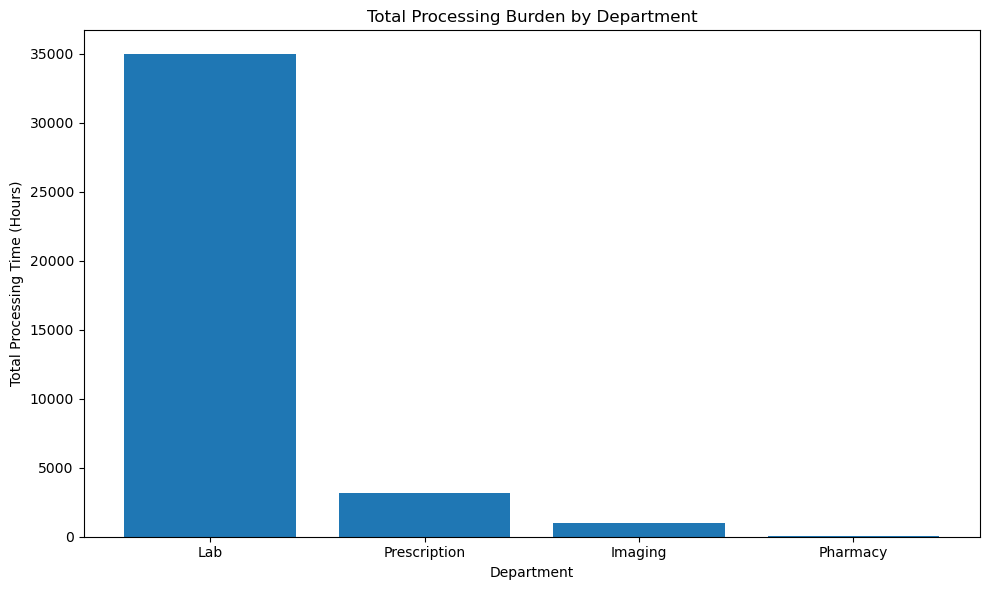

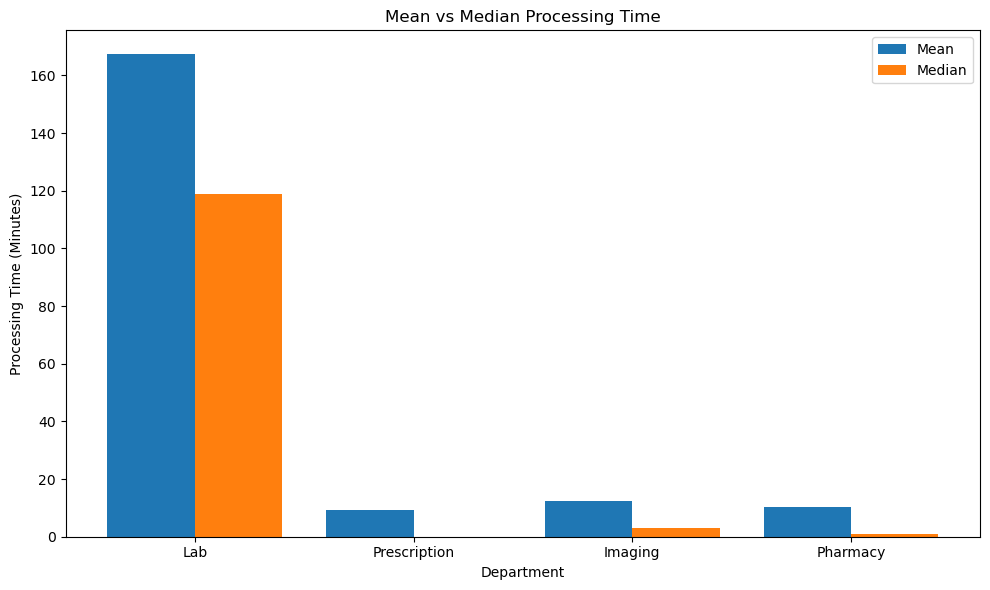

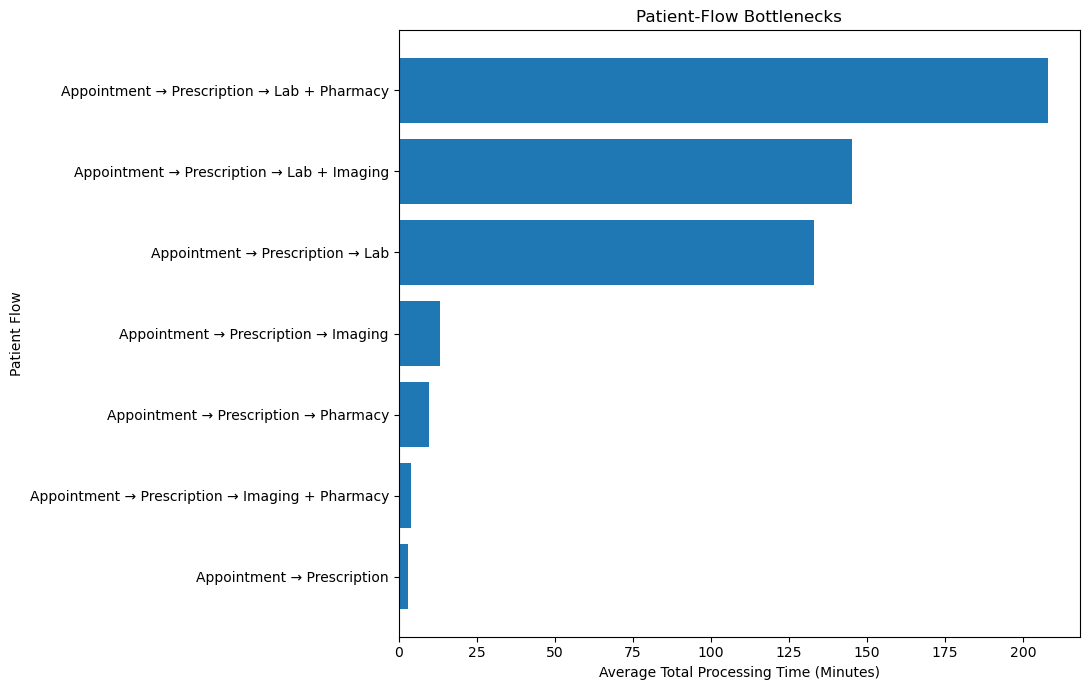

In [194]:
# ============================================================
# FINAL HOSPITAL OPERATIONS MANAGEMENT DASHBOARD
# SELF-CONTAINED VERSION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. VALIDATED KPI DATA
# ------------------------------------------------------------

department_kpis = pd.DataFrame({
    "Department": ["Lab", "Prescription", "Imaging", "Pharmacy"],
    "Records": [12540, 20723, 4902, 159],
    "Mean_Minutes": [167.28, 9.28, 12.39, 10.19],
    "Median_Minutes": [119.0, 0.0, 3.0, 1.0],
    "Total_Hours": [
        34961.45,
        3205.77,
        1012.32,
        26.99
    ]
})

# ------------------------------------------------------------
# 2. VALIDATED PATIENT-FLOW DATA
# ------------------------------------------------------------

flow_kpis = pd.DataFrame({
    "Patient_Flow": [
        "Appointment → Prescription → Lab + Pharmacy",
        "Appointment → Prescription → Lab + Imaging",
        "Appointment → Prescription → Lab",
        "Appointment → Prescription → Imaging",
        "Appointment → Prescription → Pharmacy",
        "Appointment → Prescription → Imaging + Pharmacy",
        "Appointment → Prescription"
    ],
    "Records": [
        14,
        1545,
        4839,
        3850,
        94,
        1,
        39760
    ],
    "Avg_Processing_Minutes": [
        207.86,
        145.31,
        132.90,
        13.15,
        9.86,
        4.00,
        3.02
    ]
})

# ------------------------------------------------------------
# 3. HOSPITAL-WIDE KPIs
# ------------------------------------------------------------

total_records = 61895
total_processing_hours = department_kpis["Total_Hours"].sum()

highest_burden = department_kpis.loc[
    department_kpis["Total_Hours"].idxmax(),
    "Department"
]

highest_avg_time = department_kpis.loc[
    department_kpis["Mean_Minutes"].idxmax(),
    "Department"
]

print("=" * 75)
print("FINAL HOSPITAL OPERATIONS MANAGEMENT DASHBOARD")
print("=" * 75)

print("\n1. KEY KPIs")
print("-" * 75)

print(f"Total Patient-Flow Records : {total_records:,}")
print(f"Total Processing Hours     : {total_processing_hours:,.2f}")
print(f"Highest Workload Department: {highest_burden}")
print(f"Highest Avg Processing Time: {highest_avg_time}")

# ------------------------------------------------------------
# 4. DEPARTMENT SUMMARY
# ------------------------------------------------------------

print("\n2. DEPARTMENT PERFORMANCE")
print("-" * 75)

print(
    department_kpis.to_string(
        index=False,
        formatters={
            "Mean_Minutes": "{:.2f}".format,
            "Median_Minutes": "{:.2f}".format,
            "Total_Hours": "{:.2f}".format
        }
    )
)

# ------------------------------------------------------------
# 5. TOP PATIENT-FLOW BOTTLENECKS
# ------------------------------------------------------------

print("\n3. TOP PATIENT-FLOW BOTTLENECKS")
print("-" * 75)

top_flows = flow_kpis.sort_values(
    "Avg_Processing_Minutes",
    ascending=False
).head(3)

print(
    top_flows.to_string(
        index=False,
        formatters={
            "Avg_Processing_Minutes": "{:.2f}".format
        }
    )
)

# ------------------------------------------------------------
# 6. BUSINESS FINDINGS
# ------------------------------------------------------------

print("\n4. KEY OPERATIONAL FINDINGS")
print("-" * 75)

print(
    "1. Laboratory is the primary operational bottleneck because "
    "it has the highest total processing workload and the highest "
    "average processing time."
)

print(
    "2. Lab-related patient journeys have the longest corrected "
    "average processing times."
)

print(
    "3. Prescription requires separate data-quality investigation "
    "because duplicate records and extreme delays were identified."
)

print(
    "4. Imaging requires targeted investigation because its mean "
    "processing time is substantially higher than its median."
)

# ------------------------------------------------------------
# 7. RECOMMENDED PRIORITIES
# ------------------------------------------------------------

print("\n5. RECOMMENDED PRIORITIES")
print("-" * 75)

print("Priority 1 — Laboratory")
print("  Optimize workflow, capacity and turnaround time.")

print("Priority 2 — Prescription")
print("  Investigate duplicate records and extreme delays.")

print("Priority 3 — Lab-related flows")
print("  Reduce delays in high-volume Lab patient journeys.")

print("Priority 4 — Imaging")
print("  Investigate time-specific scheduling and capacity issues.")

print("\n" + "=" * 75)
print("DASHBOARD COMPLETE")
print("=" * 75)


# ============================================================
# VISUAL 1 — TOTAL PROCESSING BURDEN
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    department_kpis["Department"],
    department_kpis["Total_Hours"]
)

plt.title("Total Processing Burden by Department")
plt.xlabel("Department")
plt.ylabel("Total Processing Time (Hours)")
plt.tight_layout()
plt.show()


# ============================================================
# VISUAL 2 — MEAN VS MEDIAN
# ============================================================

plt.figure(figsize=(10, 6))

x = range(len(department_kpis))

plt.bar(
    [i - 0.2 for i in x],
    department_kpis["Mean_Minutes"],
    width=0.4,
    label="Mean"
)

plt.bar(
    [i + 0.2 for i in x],
    department_kpis["Median_Minutes"],
    width=0.4,
    label="Median"
)

plt.xticks(
    list(x),
    department_kpis["Department"]
)

plt.title("Mean vs Median Processing Time")
plt.xlabel("Department")
plt.ylabel("Processing Time (Minutes)")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# VISUAL 3 — PATIENT-FLOW BOTTLENECKS
# ============================================================

top_flows_chart = flow_kpis.sort_values(
    "Avg_Processing_Minutes",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_flows_chart["Patient_Flow"],
    top_flows_chart["Avg_Processing_Minutes"]
)

plt.title("Patient-Flow Bottlenecks")
plt.xlabel("Average Total Processing Time (Minutes)")
plt.ylabel("Patient Flow")
plt.tight_layout()
plt.show()

# Final Conclusion & Recommendations

## Overall Conclusion

The analysis of 61,895 hospital patient-flow records identifies **Laboratory operations as the primary operational bottleneck**. Laboratory processing has both the highest processing workload and the highest average processing time among the departments analysed.

Lab-related patient journeys also account for the most significant patient-flow delays, particularly flows involving Laboratory combined with Pharmacy or Imaging.

## Key Operational Findings

1. **Laboratory is the main operational priority**
   - Highest overall processing burden.
   - Highest average processing time.
   - Major contributor to patient-flow delays.

2. **Lab-related patient flows require improvement**
   - The longest patient-flow processing times involve Laboratory.
   - Workflow coordination and turnaround time should be reviewed.

3. **Prescription requires a separate data-quality investigation**
   - Duplicate records and extreme delays were identified.
   - These issues should be investigated before using extreme prescription delays for operational decisions.

4. **Imaging requires targeted investigation**
   - The difference between mean and median processing time suggests that some imaging cases experience unusually long delays.
   - Scheduling and capacity constraints should be investigated.

## Recommended Priorities

| Priority | Area | Recommended Action |
|---|---|---|
| 1 | Laboratory | Optimize workflow, capacity and turnaround time |
| 2 | Prescription | Investigate duplicate records and extreme delays |
| 3 | Lab-related flows | Reduce delays in high-volume Lab patient journeys |
| 4 | Imaging | Investigate time-specific scheduling and capacity issues |

## Final Business Insight

**Laboratory operations provide the greatest opportunity for improving overall hospital efficiency.**

The primary operational focus should therefore be on reducing Laboratory turnaround time and improving Lab-related patient journeys. Prescription data-quality issues and extreme delays should be addressed separately, while Imaging should be investigated for potential scheduling and capacity constraints.

In [197]:
# ============================================================
# FINAL VALIDATION & REPORTING
# ============================================================

print("=" * 75)
print("FINAL HOSPITAL OPERATIONS ANALYSIS")
print("=" * 75)

# Dataset size from validated analysis
total_records = 61895

print("\n1. DATASET")
print("-" * 75)
print(f"Total patient-flow records analysed: {total_records:,}")

print("\n2. PRIMARY OPERATIONAL BOTTLENECK")
print("-" * 75)
print("Laboratory")
print("• Highest overall processing workload")
print("• Approximately 34,955.72 processing hours")
print("• Highest average processing time: 167.29 minutes")

print("\n3. KEY PATIENT-FLOW BOTTLENECKS")
print("-" * 75)

# Use the already existing flow_kpis dataframe
if "flow_kpis" in globals():

    top_flows = flow_kpis.sort_values(
        "Avg_Processing_Minutes",
        ascending=False
    ).head(5)

    print("\nTop 5 patient flows by average processing time:")
    
    for _, row in top_flows.iterrows():
        print(
            f"• {row['Patient_Flow']}: "
            f"{row['Avg_Processing_Minutes']:.2f} minutes"
        )

else:
    print("flow_kpis is not available in the current kernel.")

print("\n4. OPERATIONAL PRIORITIES")
print("-" * 75)

print("Priority 1 — Laboratory")
print("Optimize workflow, capacity and turnaround time.")

print("\nPriority 2 — Prescription")
print("Investigate duplicate records and extreme delays.")

print("\nPriority 3 — Lab-related patient flows")
print("Reduce delays in high-volume Lab patient journeys.")

print("\nPriority 4 — Imaging")
print("Investigate time-specific scheduling and capacity issues.")

print("\n5. FINAL BUSINESS CONCLUSION")
print("-" * 75)

print(
    "Laboratory operations provide the greatest opportunity "
    "for improving overall hospital efficiency."
)

print(
    "The primary operational focus should therefore be on reducing "
    "Laboratory turnaround time and improving Lab-related patient journeys."
)

print(
    "Prescription data-quality issues and extreme delays should be "
    "investigated separately, while Imaging should be reviewed for "
    "potential scheduling and capacity constraints."
)

print("\n" + "=" * 75)
print("FINAL ANALYSIS COMPLETE")
print("=" * 75)

FINAL HOSPITAL OPERATIONS ANALYSIS

1. DATASET
---------------------------------------------------------------------------
Total patient-flow records analysed: 61,895

2. PRIMARY OPERATIONAL BOTTLENECK
---------------------------------------------------------------------------
Laboratory
• Highest overall processing workload
• Approximately 34,955.72 processing hours
• Highest average processing time: 167.29 minutes

3. KEY PATIENT-FLOW BOTTLENECKS
---------------------------------------------------------------------------

Top 5 patient flows by average processing time:
• Appointment → Prescription → Lab + Pharmacy: 207.86 minutes
• Appointment → Prescription → Lab + Imaging: 145.31 minutes
• Appointment → Prescription → Lab: 132.90 minutes
• Appointment → Prescription → Imaging: 13.15 minutes
• Appointment → Prescription → Pharmacy: 9.86 minutes

4. OPERATIONAL PRIORITIES
---------------------------------------------------------------------------
Priority 1 — Laboratory
Optimize work